## 原本pipeline

### 寫入資料 -> 切分航程 -> 異常航程判定 

In [18]:
from pathlib import Path
from lake_io import save_df, load_df, ensure_dir

def ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

PROJECT_DIR = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
LAKE_DIR = ensure_dir(PROJECT_DIR / "lake")

In [19]:
# =========================
# main.py in Jupyter cell（整合版 - smart teleport + 港到港 + robust停泊分類）
# =========================

from pathlib import Path
import webbrowser

import numpy as np
import pandas as pd
from haversine import haversine

# 匯入自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import (
    detect_stops,
    split_voyages,
    voyage_quality_checker,
    _safe_haversine,   # 小工具：改經度範圍後的 haversine
)
from visualization import visualize_voyages
from od_marker import assign_ports
from Trajectory_Recon import TrajectoryReconstructor
from data_quality import voyage_integrity_metrics


# ----------------------------
# 0. 基本設定
# ----------------------------
csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "477848300_VesselHistoryLineInfo.csv"
target_mmsi = 477848300

# 港口清單路徑：filtered_ports.csv，欄位為 unlocode, lat, lon
ports_csv = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "filtered_ports.csv"


# ----------------------------
# 0.5  移除雜訊點（teleport）- smart 迭代版
# ----------------------------

def remove_teleport_points(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    keep_report: bool = True
):
    """
    移除 AIS 瞬移點（teleport）
    - Rule A（三點檢查，中間點）：prev->cur 爆速 且 prev->next 合理 => 刪 cur
    - Rule B（開頭邊界點）：cur->next 爆速 且 next->next 正常 => 刪 cur
    - Rule C（結尾邊界點）：prev->cur 爆速 且 prev->prev 正常 => 刪 cur

    需要欄位：Timestamp, Lat, Long
    回傳：df_clean, report_df
    """
    d = df.sort_values("Timestamp").copy()

    # 避免你 df 本來就有 orig_index 造成重複欄位
    if "orig_index" in d.columns:
        d = d.rename(columns={"orig_index": "orig_index_old"})
    d = d.reset_index(drop=False).rename(columns={"index": "orig_index"})

    # prev/next
    d["Lat_prev"]   = d["Lat"].shift(1)
    d["Long_prev"]  = d["Long"].shift(1)
    d["T_prev"]     = d["Timestamp"].shift(1)

    d["Lat_next"]   = d["Lat"].shift(-1)
    d["Long_next"]  = d["Long"].shift(-1)
    d["T_next"]     = d["Timestamp"].shift(-1)

    d["Lat_next2"]  = d["Lat"].shift(-2)
    d["Long_next2"] = d["Long"].shift(-2)
    d["T_next2"]    = d["Timestamp"].shift(-2)

    d["Lat_prev2"]  = d["Lat"].shift(2)
    d["Long_prev2"] = d["Long"].shift(2)
    d["T_prev2"]    = d["Timestamp"].shift(2)

    # dt
    d["dt_prev_sec"]     = (d["Timestamp"] - d["T_prev"]).dt.total_seconds()
    d["dt_next_sec"]     = (d["T_next"] - d["Timestamp"]).dt.total_seconds()
    d["dt_prevnext_sec"] = (d["T_next"] - d["T_prev"]).dt.total_seconds()
    d["dt_next2_sec"]    = (d["T_next2"] - d["T_next"]).dt.total_seconds()
    d["dt_prev2_sec"]    = (d["T_prev"] - d["T_prev2"]).dt.total_seconds()

    # dist (km)
    def _dist_km(lat1, lon1, lat2, lon2):
        if np.any(pd.isna([lat1, lon1, lat2, lon2])):
            return np.nan
        return haversine((lat1, lon1), (lat2, lon2))

    d["dist_prev_km"]     = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"],  d["Long_prev"],  d["Lat"],      d["Long"])]
    d["dist_next_km"]     = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat"],       d["Long"],       d["Lat_next"], d["Long_next"])]
    d["dist_prevnext_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"],  d["Long_prev"],  d["Lat_next"], d["Long_next"])]

    d["dist_next2_km"]    = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_next"],  d["Long_next"],  d["Lat_next2"], d["Long_next2"])]
    d["dist_prev2_km"]    = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev2"], d["Long_prev2"], d["Lat_prev"],  d["Long_prev"])]

    # speed (kn)
    d["speed_prev_kn"]     = (d["dist_prev_km"] / (d["dt_prev_sec"] / 3600.0)) / 1.852
    d["speed_next_kn"]     = (d["dist_next_km"] / (d["dt_next_sec"] / 3600.0)) / 1.852
    d["speed_prevnext_kn"] = (d["dist_prevnext_km"] / (d["dt_prevnext_sec"] / 3600.0)) / 1.852
    d["speed_next2_kn"]    = (d["dist_next2_km"] / (d["dt_next2_sec"] / 3600.0)) / 1.852
    d["speed_prev2_kn"]    = (d["dist_prev2_km"] / (d["dt_prev2_sec"] / 3600.0)) / 1.852

    # ---------- Rule A: 三點檢查刪中間點 ----------
    ruleA = (
        (d["dt_prev_sec"] > 0) & (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prevnext_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule B: 開頭邊界離群點（刪當前點） ----------
    ruleB = (
        (d["dt_next_sec"] > 0) & (d["dt_next_sec"] <= dt_max_sec) &
        (d["speed_next_kn"] > speed_kn_th) &
        (d["speed_next2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule C: 結尾邊界離群點（刪當前點） ----------
    ruleC = (
        (d["dt_prev_sec"] > 0) & (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prev2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    to_drop = (ruleA | ruleB | ruleC).fillna(False)

    reason = np.where(ruleA, "A_midpoint",
             np.where(ruleB, "B_head_outlier",
             np.where(ruleC, "C_tail_outlier", "")))
    report = d.loc[to_drop, ["orig_index","Timestamp","Lat","Long","speed_prev_kn","speed_next_kn"]].copy()
    report["reason"] = np.array(reason)[to_drop.to_numpy()]

    drop_cols = [
        "Lat_prev","Long_prev","T_prev",
        "Lat_next","Long_next","T_next",
        "Lat_next2","Long_next2","T_next2",
        "Lat_prev2","Long_prev2","T_prev2",
        "dt_prev_sec","dt_next_sec","dt_prevnext_sec","dt_next2_sec","dt_prev2_sec",
        "dist_prev_km","dist_next_km","dist_prevnext_km","dist_next2_km","dist_prev2_km",
        "speed_prev_kn","speed_next_kn","speed_prevnext_kn","speed_next2_kn","speed_prev2_kn"
    ]
    drop_cols = [c for c in drop_cols if c in d.columns]

    df_clean = d.loc[~to_drop, :].drop(columns=drop_cols).reset_index(drop=True)

    if keep_report:
        return df_clean, report
    return df_clean, None


def has_teleport_edges(df: pd.DataFrame, speed_kn_th: float = 50.0, dt_max_sec: float = 3600.0) -> bool:
    if df.empty or len(df) < 2:
        return False

    d = df.sort_values("Timestamp")[["Timestamp","Lat","Long"]].copy()
    dt = d["Timestamp"].diff().dt.total_seconds()

    lat1 = d["Lat"].shift(1).to_numpy()
    lon1 = d["Long"].shift(1).to_numpy()
    lat2 = d["Lat"].to_numpy()
    lon2 = d["Long"].to_numpy()

    dist = np.full(len(d), np.nan, dtype=float)
    valid = (~np.isnan(lat1)) & (~np.isnan(lon1)) & (~np.isnan(lat2)) & (~np.isnan(lon2))
    idxs = np.where(valid)[0]
    for i in idxs:
        dist[i] = haversine((lat1[i], lon1[i]), (lat2[i], lon2[i]))  # km

    speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852
    mask = (dt.to_numpy() > 0) & (dt.to_numpy() <= dt_max_sec) & (speed_kn > speed_kn_th)
    return bool(np.nan_to_num(mask).any())


def remove_teleport_points_smart(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    max_iter: int = 8,
    verbose: bool = True
):
    d = df.copy()
    reports = []

    for it in range(max_iter):
        still_bad = has_teleport_edges(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec)
        if not still_bad:
            if verbose:
                print(f"[teleport] stop at iter {it}: no suspect edges.")
            break

        d2, rep = remove_teleport_points(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec, keep_report=True)
        n_drop = 0 if rep is None else len(rep)
        if verbose:
            print(f"[teleport] iter {it+1}: dropped {n_drop} points")

        if rep is None or n_drop == 0:
            break

        rep = rep.copy()
        rep["iter"] = it + 1
        reports.append(rep)
        d = d2

    report_all = pd.concat(reports, ignore_index=True) if reports else pd.DataFrame()
    return d, report_all


# ----------------------------
# 1. 載入 AIS & teleport 清洗 & 基礎停泊偵測
# ----------------------------

clean_dir = ensure_dir(LAKE_DIR / "10_clean")

df_cached = load_df(clean_dir, f"df_clean_mmsi_{target_mmsi}")
rep_cached = load_df(clean_dir, f"teleport_report_mmsi_{target_mmsi}")

if df_cached is not None and rep_cached is not None:
    print("[lake] loaded cached clean df + teleport report")
    df = df_cached
    teleport_report = rep_cached
else:
    print("[lake] cache miss -> compute")
    df = load_and_preprocess(csv_path, target_mmsi)

    df, teleport_report = remove_teleport_points_smart(
        df,
        speed_kn_th=50,
        dt_max_sec=3600,
        max_iter=8,
        verbose=True
    )

    save_df(df, clean_dir, f"df_clean_mmsi_{target_mmsi}", meta={"mmsi": int(target_mmsi)})
    save_df(teleport_report, clean_dir, f"teleport_report_mmsi_{target_mmsi}", meta={"mmsi": int(target_mmsi)})
    print("[lake] saved clean df + teleport report")

print(f"刪除 teleport 點數量: {len(teleport_report)}")
print(f"清理後資料筆數(teleport 清除後): {len(df)}")

print("執行停泊判斷 (detect_stops)...")
stop_segments_initial = detect_stops(df)
print(f"偵測到停泊區段數量: {len(stop_segments_initial)}")


# ----------------------------
# 2. 傳統航程切分（供 QA / 地圖呈現）
# ----------------------------
print("\n[傳統] 切分航程（停泊→航行→停泊）...")
df_with_voyages, voyages_raw = split_voyages(df, stop_segments_initial)
print(f"切分後航程數量: {len(voyages_raw)}")

print("執行航程 QA 檢查...")
voyages_qc = voyage_quality_checker(
    df_with_voyages,
    voyages_raw,
    stop_segments=stop_segments_initial
)
print(f"QA 完成，有效航程數量: {voyages_qc['valid_flag'].sum()}")

print("輸出傳統航程地圖 voyages_map.html ...")
visualize_voyages(df_with_voyages, voyages_raw)
webbrowser.open("voyages_map.html")


# ============================
# 下方開始：新版「港到港＋錨泊/等待」流程
# ============================

# ----------------------------
# ★ Robust SOG stats：把最外側少量尖峰降噪後再算 std
# ----------------------------
def robust_sog_stats(sog_series: pd.Series, clip_pct: float = 2.5):
    """
    clip_pct=2.5 代表用中間 95% 做穩健估計（winsorize / trim）
    回傳：
      avg_sog
      sog_std            : 原始 std
      sog_p95            : 95分位（參考用）
      sog_std_w95        : winsorized std（建議拿來判 port_call）
      sog_std_trim95     : trimmed std（debug用）
    """
    x = pd.to_numeric(sog_series, errors="coerce").dropna().to_numpy()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    avg = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    p95 = float(np.percentile(x, 95))

    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))

    x_w = np.clip(x, lo, hi)
    std_w95 = float(np.std(x_w, ddof=1)) if len(x_w) > 1 else 0.0

    x_t = x[(x >= lo) & (x <= hi)]
    std_trim95 = float(np.std(x_t, ddof=1)) if len(x_t) > 1 else 0.0

    return avg, std, p95, std_w95, std_trim95


# ----------------------------
# 3. 從 stop_segments_initial 建立停泊 episodes + 合併碎段
# ----------------------------
def build_raw_stop_episodes(df, stop_segments):
    """
    將 detect_stops 回傳的 stop_segments(list of range)
    轉成一個 DataFrame：每列是一個「原始停泊 episode」
    新增 robust 指標：sog_std_w95 / sog_std_trim95
    """
    records = []
    for seg_id, seg in enumerate(stop_segments, start=1):
        idxs = list(seg)
        if not idxs:
            continue

        start_idx = idxs[0]
        end_idx   = idxs[-1]
        t_start = df.loc[start_idx, "Timestamp"]
        t_end   = df.loc[end_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()

        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5)

        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        records.append({
            "raw_stop_id": seg_id,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,        # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,  # debug
            "radius_km": radius_km,
        })

    return pd.DataFrame(records)


def merge_stop_episodes(df,
                        stops_raw,
                        max_gap_sec=30*60,
                        max_center_dist_km=1.0,
                        max_move_duration_sec=30*60,
                        max_move_disp_km=2.0,
                        max_move_avg_sog_kn=2.0):
    """
    合併相鄰停泊 episodes，合併後會重新計算 robust 指標
    """
    if stops_raw.empty:
        out = stops_raw.copy()
        for c in ["sog_p95", "sog_std_w95", "sog_std_trim95"]:
            if c not in out.columns:
                out[c] = np.nan
        return out.assign(stop_id=lambda x: np.arange(1, len(x)+1))

    stops_raw = stops_raw.sort_values("t_start").reset_index(drop=True)

    merged_records = []
    cur_start_idx = int(stops_raw.loc[0, "start_idx"])
    cur_end_idx   = int(stops_raw.loc[0, "end_idx"])

    for i in range(len(stops_raw) - 1):
        this_row = stops_raw.loc[i]
        next_row = stops_raw.loc[i+1]

        this_end_idx = int(this_row["end_idx"])
        next_start_idx = int(next_row["start_idx"])

        gap_sec = (next_row["t_start"] - this_row["t_end"]).total_seconds()

        center_dist_km = _safe_haversine(
            (this_row["center_lat"], this_row["center_lon"]),
            (next_row["center_lat"], next_row["center_lon"])
        )

        move_start_idx = this_end_idx + 1
        move_end_idx   = next_start_idx - 1

        has_move = move_start_idx <= move_end_idx
        move_duration_sec = 0.0
        move_disp_km = 0.0
        move_avg_sog = 0.0

        if has_move:
            t_move_start = df.loc[move_start_idx, "Timestamp"]
            t_move_end   = df.loc[move_end_idx, "Timestamp"]
            move_duration_sec = (t_move_end - t_move_start).total_seconds()
            move_disp_km = _safe_haversine(
                (df.loc[move_start_idx, "Lat"], df.loc[move_start_idx, "Long"]),
                (df.loc[move_end_idx,   "Lat"], df.loc[move_end_idx,   "Long"])
            )
            move_avg_sog = float(pd.to_numeric(df.loc[move_start_idx:move_end_idx, "Sog"], errors="coerce").mean())

        cond_time_close   = gap_sec <= max_gap_sec
        cond_center_close = center_dist_km <= max_center_dist_km

        if has_move:
            cond_move_small = (
                (move_duration_sec <= max_move_duration_sec) and
                (move_disp_km <= max_move_disp_km) and
                (move_avg_sog <= max_move_avg_sog_kn)
            )
        else:
            cond_move_small = True

        if cond_time_close and cond_center_close and cond_move_small:
            cur_end_idx = int(next_row["end_idx"])
        else:
            merged_records.append((cur_start_idx, cur_end_idx))
            cur_start_idx = int(next_row["start_idx"])
            cur_end_idx   = int(next_row["end_idx"])

    merged_records.append((cur_start_idx, cur_end_idx))

    merged_rows = []
    for stop_id, (s_idx, e_idx) in enumerate(merged_records, start=1):
        idxs = list(range(s_idx, e_idx + 1))
        t_start = df.loc[s_idx, "Timestamp"]
        t_end   = df.loc[e_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()

        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5)

        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        merged_rows.append({
            "stop_id": stop_id,
            "start_idx": s_idx,
            "end_idx": e_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,        # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,  # debug
            "radius_km": radius_km
        })

    return pd.DataFrame(merged_rows)


print("\n建構停泊 episodes（raw）...")
stops_raw = build_raw_stop_episodes(df, stop_segments_initial)
print("原始停泊段數量:", len(stops_raw))

print("合併碎停泊 episodes（stops_merged）...")
stops_merged = merge_stop_episodes(df, stops_raw)
print("合併後停泊段數量:", len(stops_merged))


# ----------------------------
# 4. 載入港口清單 + 最近港口貼標 + 停泊型態分類
# ----------------------------
print("\n載入港口清單 filtered_ports.csv ...")
ports_df = pd.read_csv(ports_csv)

ports_df = ports_df.rename(columns={"unlocode": "port_id"})
if "port_name" not in ports_df.columns:
    ports_df["port_name"] = ports_df["port_id"]

print(f"港口數量: {len(ports_df)}")


def attach_nearest_port_to_stops(stops_df, ports_df):
    stops_df = stops_df.copy()

    port_coords = ports_df[["port_id", "port_name", "lat", "lon"]].to_dict(orient="records")

    nearest_ids = []
    nearest_names = []
    nearest_dists = []

    for _, row in stops_df.iterrows():
        lat0 = row["center_lat"]
        lon0 = row["center_lon"]

        best_port_id = None
        best_port_name = None
        best_dist = np.inf

        for p in port_coords:
            d = haversine((lat0, lon0), (p["lat"], p["lon"]))  # km
            if d < best_dist:
                best_dist = d
                best_port_id = p["port_id"]
                best_port_name = p["port_name"]

        nearest_ids.append(best_port_id)
        nearest_names.append(best_port_name)
        nearest_dists.append(best_dist)

    stops_df["nearest_port_id"] = nearest_ids
    stops_df["nearest_port_name"] = nearest_names
    stops_df["dist_to_port_km"] = nearest_dists

    return stops_df


def classify_stop_type(stops_df,
                       call_max_dist_km=15.0,
                       call_min_duration_sec=4*3600,
                       call_max_avg_sog_kn=0.1,
                       call_max_sog_std_w95_kn=0.2,   # ★改成 robust std
                       call_max_radius_km=0.5,
                       anch_max_dist_km=30.0,
                       anch_min_duration_sec=1800,
                       anch_min_avg_sog_kn=0.1,
                       anch_max_avg_sog_kn=2.0):
    """
    port_call 判斷改用 sog_std_w95（winsorized 95% std）：
      - 對少數尖峰更不敏感
      - 保留你原本想用 std 代表「穩定程度」的物理意義
    """
    stops_df = stops_df.copy()
    stops_df["stop_type"] = "other"

    if "sog_std_w95" not in stops_df.columns:
        stops_df["sog_std_w95"] = np.inf

    mask_call = (
        (stops_df["dist_to_port_km"] <= call_max_dist_km) &
        (stops_df["duration_sec"]   >= call_min_duration_sec) &
        (stops_df["avg_sog"].fillna(0) <= call_max_avg_sog_kn) &
        (stops_df["sog_std_w95"].fillna(np.inf) <= call_max_sog_std_w95_kn) &
        (stops_df["radius_km"].fillna(0) <= call_max_radius_km)
    )
    stops_df.loc[mask_call, "stop_type"] = "port_call"

    mask_anch = (
        (stops_df["stop_type"] == "other") &
        (stops_df["dist_to_port_km"] <= anch_max_dist_km) &
        (stops_df["duration_sec"]   >= anch_min_duration_sec) &
        #(stops_df["avg_sog"].fillna(0) >= anch_min_avg_sog_kn) &
        (stops_df["avg_sog"].fillna(0) <= anch_max_avg_sog_kn)
    )
    stops_df.loc[mask_anch, "stop_type"] = "anchorage_like"

    return stops_df


print("停泊 episodes 貼最近港口 & 分類型態...")
stops_with_port = attach_nearest_port_to_stops(stops_merged, ports_df)
stops_classified = classify_stop_type(stops_with_port)

print(stops_classified["stop_type"].value_counts())
display(stops_classified.head())


# ----------------------------
# 5. 從 port_call episodes 建立港到港 voyages + waiting_for_dest 標記
# ----------------------------
def build_port_calls(stops_classified):
    calls = stops_classified[stops_classified["stop_type"] == "port_call"].copy()
    if calls.empty:
        return pd.DataFrame(columns=[
            "call_id", "mmsi", "port_id", "port_name",
            "t_arrive_port", "t_depart_port", "stop_id"
        ])

    calls = calls.sort_values("t_start").reset_index(drop=True)
    calls["call_id"] = np.arange(1, len(calls) + 1)

    port_calls = pd.DataFrame({
        "call_id": calls["call_id"],
        "port_id": calls["nearest_port_id"],
        "port_name": calls["nearest_port_name"],
        "t_arrive_port": calls["t_start"],
        "t_depart_port": calls["t_end"],
        "stop_id": calls["stop_id"]
    })
    return port_calls


def build_voyages_from_port_calls(port_calls):
    if port_calls.empty or len(port_calls) < 2:
        return pd.DataFrame(columns=[
            "voyage_id", "origin_call_id", "dest_call_id",
            "origin_port_id", "dest_port_id",
            "origin_port_name", "dest_port_name",
            "t_depart_origin", "t_arrive_dest"
        ])

    port_calls = port_calls.sort_values("t_arrive_port").reset_index(drop=True)

    records = []
    voyage_id = 1
    for i in range(len(port_calls) - 1):
        row_o = port_calls.loc[i]
        row_d = port_calls.loc[i+1]

        records.append({
            "voyage_id": voyage_id,
            "origin_call_id": row_o["call_id"],
            "dest_call_id": row_d["call_id"],
            "origin_port_id": row_o["port_id"],
            "dest_port_id": row_d["port_id"],
            "origin_port_name": row_o["port_name"],
            "dest_port_name": row_d["port_name"],
            "t_depart_origin": row_o["t_depart_port"],
            "t_arrive_dest": row_d["t_arrive_port"]
        })
        voyage_id += 1

    return pd.DataFrame(records)


def label_waiting_for_dest(stops_classified, voyages_p2p,
                           ports_df,
                           alpha_progress=0.7,
                           max_dist_to_dest_km=100.0):
    stops = stops_classified.copy()
    stops["waiting_for_dest_port_id"] = None

    if voyages_p2p.empty:
        voyages_p2p["total_waiting_sec"] = 0.0
        return stops, voyages_p2p

    port_coord_map = {row["port_id"]: (row["lat"], row["lon"])
                      for _, row in ports_df[["port_id", "lat", "lon"]].iterrows()}

    voyages_records = []

    for _, v in voyages_p2p.iterrows():
        dest_port = v["dest_port_id"]
        t_dep = v["t_depart_origin"]
        t_arr = v["t_arrive_dest"]

        if pd.isna(t_dep) or pd.isna(t_arr) or (t_arr <= t_dep):
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        T_voy = (t_arr - t_dep).total_seconds()
        if T_voy <= 0:
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        mask_in_voy = (stops["t_start"] >= t_dep) & (stops["t_start"] <= t_arr)
        stops_voy = stops[mask_in_voy].copy()

        dest_lat, dest_lon = port_coord_map.get(dest_port, (None, None))

        waiting_ids = []
        total_waiting_sec = 0.0

        for _, s in stops_voy.iterrows():
            if s["stop_type"] != "anchorage_like":
                continue

            t_mid = s["t_start"] + (s["t_end"] - s["t_start"]) / 2
            progress = (t_mid - t_dep).total_seconds() / T_voy
            if progress < alpha_progress:
                continue

            dist_to_B = np.inf
            if dest_lat is not None:
                dist_to_B = haversine((s["center_lat"], s["center_lon"]), (dest_lat, dest_lon))
            if dist_to_B > max_dist_to_dest_km:
                continue

            waiting_ids.append(s["stop_id"])
            total_waiting_sec += s["duration_sec"]

        if waiting_ids:
            stops.loc[stops["stop_id"].isin(waiting_ids), "waiting_for_dest_port_id"] = dest_port

        v_dict = v.to_dict()
        v_dict["total_waiting_sec"] = total_waiting_sec
        voyages_records.append(v_dict)

    voyages_with_waiting = pd.DataFrame(voyages_records)
    return stops, voyages_with_waiting
# ----------------------------
# 6. 標記有large_time_gap 的航程
# ----------------------------
def mark_large_time_gap_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    gap_sec_th: float = 6 * 3600,   # 例如 6 小時；你可改 3hr/12hr/24hr
    window_pad_sec: float = 0.0,    # 需要可加 padding
    verbose: bool = False
):
    """
    對每條 voyage（用 dep~arr 時間窗切點），計算最大 dt_sec，並標記 large_time_gap。
    回傳：voyages_df (新增欄位)
    """
    d = df_points.sort_values(time_col).copy()
    v = voyages_df.copy()

    # 初始化欄位
    v["n_points"] = 0
    v["max_dt_sec"] = np.nan
    v["max_dt_hr"] = np.nan
    v["gap_from"] = pd.NaT
    v["gap_to"] = pd.NaT
    v["large_time_gap_flag"] = False

    for i, row in v.iterrows():
        vid = row[voyage_id_col]
        t0 = row[dep_col]
        t1 = row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        t0p = t0 - pd.Timedelta(seconds=window_pad_sec)
        t1p = t1 + pd.Timedelta(seconds=window_pad_sec)

        seg = d[(d[time_col] >= t0p) & (d[time_col] <= t1p)].copy()
        if len(seg) < 2:
            v.at[i, "n_points"] = len(seg)
            continue

        seg["dt_sec"] = seg[time_col].diff().dt.total_seconds()

        # 最大 gap（忽略第一筆 NaN）
        jmax = seg["dt_sec"].idxmax()
        max_dt = float(seg.loc[jmax, "dt_sec"])

        v.at[i, "n_points"] = len(seg)
        v.at[i, "max_dt_sec"] = max_dt
        v.at[i, "max_dt_hr"] = max_dt / 3600.0 if np.isfinite(max_dt) else np.nan

        if np.isfinite(max_dt):
            # gap_from 是上一筆時間（idxmax 那列的前一列）
            pos = seg.index.get_loc(jmax)
            if pos > 0:
                prev_idx = seg.index[pos - 1]
                v.at[i, "gap_from"] = seg.loc[prev_idx, time_col]
                v.at[i, "gap_to"] = seg.loc[jmax, time_col]

            v.at[i, "large_time_gap_flag"] = (max_dt >= gap_sec_th)

        if verbose and v.at[i, "large_time_gap_flag"]:
            print(f"[voyage {vid}] max_dt_hr={v.at[i,'max_dt_hr']:.2f}  gap_from={v.at[i,'gap_from']}  gap_to={v.at[i,'gap_to']}")

    return v


print("\n從停泊 episodes 建立 port_calls & 港到港 voyages...")
port_calls = build_port_calls(stops_classified)
voyages_p2p = build_voyages_from_port_calls(port_calls)

print("Port calls 數量:", len(port_calls))
print("港到港 voyages 數量:", len(voyages_p2p))

print("標記 waiting_for_dest_port_id（錨泊/等待段）...")
stops_labeled, voyages_with_waiting = label_waiting_for_dest(
    stops_classified,
    voyages_p2p,
    ports_df,
    alpha_progress=0.7,
    max_dist_to_dest_km=100.0
)

port_calls["mmsi"] = target_mmsi
voyages_with_waiting["mmsi"] = target_mmsi

print("有等待時間的港到港航程數量:",
      (voyages_with_waiting["total_waiting_sec"] > 0).sum())



print("\n=== stops_labeled 範例 ===")
display(stops_labeled.head())

print("\n=== voyages_with_waiting 範例 ===")
display(voyages_with_waiting.head())

#print("\n流程完成，可以開始拿 voyages_with_waiting / stops_labeled 來準備 ETA 的訓練資料了。")

voyages_with_waiting = mark_large_time_gap_for_voyages(
    df_points=df,  # 你的 AIS 點資料（teleport 清過的 df）
    voyages_df=voyages_with_waiting,
    gap_sec_th=6*3600,
    verbose=True
)

display(voyages_with_waiting.sort_values("max_dt_sec", ascending=False).head(10))
print("large_time_gap 航程數量:", voyages_with_waiting["large_time_gap_flag"].sum())

# =========================
# Loitering / Slow-wait anomaly detector (non-stop) - drop-in cell
# Assumes you already ran the pipeline above and have:
#   df (teleport-cleaned points, with Timestamp/Lat/Long/Sog)
#   voyages_with_waiting (port-to-port voyages with t_depart_origin/t_arrive_dest, voyage_id)
# =========================

import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# ---------- utils ----------
def _to_lon180(x: float) -> float:
    return ((x + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def _path_len_km(lat, lon):
    if len(lat) < 2:
        return 0.0
    tot = 0.0
    for i in range(1, len(lat)):
        if np.isnan(lat[i-1]) or np.isnan(lon[i-1]) or np.isnan(lat[i]) or np.isnan(lon[i]):
            continue
        tot += haversine_km(lat[i-1], lon[i-1], lat[i], lon[i])
    return float(tot)

def _r95_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() == 0:
        return np.nan
    latm = float(np.nanmedian(lat[mask]))
    lonm = float(np.nanmedian(lon[mask]))
    d = np.array([haversine_km(latm, lonm, a, b) for a, b in zip(lat[mask], lon[mask])], dtype=float)
    return float(np.nanpercentile(d, 95)) if len(d) else np.nan

def _net_disp_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() < 2:
        return 0.0
    i0 = np.where(mask)[0][0]
    i1 = np.where(mask)[0][-1]
    return float(haversine_km(lat[i0], lon[i0], lat[i1], lon[i1]))

def _winsorize_std(x, clip_pct=2.5):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan
    if len(x) == 1:
        return 0.0
    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))
    xw = np.clip(x, lo, hi)
    return float(np.std(xw, ddof=1))

def _merge_intervals(intervals, max_gap_sec=600):
    """
    intervals: list of (start_ts, end_ts)
    """
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    out = [list(intervals[0])]
    for s, e in intervals[1:]:
        if (s - out[-1][1]).total_seconds() <= max_gap_sec:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(a, b) for a, b in out]

# ---------- main detector ----------
def detect_loitering_events_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    sog_col: str = "Sog",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",

    # windowing
    window_sec: int = 10 * 60,        # 10 min window
    step_sec: int = 2 * 60,           # slide every 2 min
    min_points_in_window: int = 12,   # depends on your sampling; 12 points / 10min = ~50s interval

    # anomaly logic (tune later)
    sog_low_kn: float = 0.5,
    sog_high_kn: float = 6.0,
    low_speed_ratio_th: float = 0.70,

    r95_max_km: float = 3.0,          # "small area" but not necessarily stopped
    net_disp_max_km: float = 1.0,     # little net progress within window
    tortuosity_min: float = 2.5,      # path / net_disp (higher => circling)
    sog_std_w95_min: float = 0.20,    # "moving around" signal (not dead-still)

    min_event_sec: int = 20 * 60,     # event must last >= 20 min
    merge_gap_sec: int = 10 * 60,     # merge nearby candidate windows
    verbose: bool = True
):
    d = df_points.sort_values(time_col).copy()
    # ensure datetime
    d[time_col] = pd.to_datetime(d[time_col])

    voyages = voyages_df.copy()
    voyages[dep_col] = pd.to_datetime(voyages[dep_col])
    voyages[arr_col] = pd.to_datetime(voyages[arr_col])

    all_events = []
    point_labels = []  # store (voyage_id, start_ts, end_ts, event_id)

    event_id = 1

    for _, v in voyages.iterrows():
        vid = v[voyage_id_col]
        t0 = v[dep_col]
        t1 = v[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        if len(seg) < min_points_in_window:
            continue

        # build sliding windows
        t_start = seg[time_col].iloc[0]
        t_end = seg[time_col].iloc[-1]
        cur = t_start

        candidate_intervals = []

        while cur <= t_end:
            w_end = cur + pd.Timedelta(seconds=window_sec)
            w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]
            if len(w) >= min_points_in_window:
                lat = w[lat_col].astype(float).to_numpy()
                lon = w[lon_col].astype(float).to_numpy()
                sog = pd.to_numeric(w[sog_col], errors="coerce").to_numpy(dtype=float)

                # speed band ratio
                band = (sog >= sog_low_kn) & (sog <= sog_high_kn)
                low_ratio = float(np.nanmean(band)) if len(sog) else 0.0
                sog_std_w95 = _winsorize_std(sog, clip_pct=2.5)

                # geometry
                r95 = _r95_km(lat, lon)
                net = _net_disp_km(lat, lon)
                plen = _path_len_km(lat, lon)
                tort = float(plen / max(net, 1e-6))

                # candidate rule: (low speed) + (small area) + (either circling OR jittery movement)
                cond_speed = (low_ratio >= low_speed_ratio_th)
                cond_area = (np.isfinite(r95) and r95 <= r95_max_km and net <= net_disp_max_km)

                # "loitering-ness": circling or back-and-forth
                cond_circling = (tort >= tortuosity_min)
                cond_jitter = (np.isfinite(sog_std_w95) and sog_std_w95 >= sog_std_w95_min) and (net <= net_disp_max_km)

                if cond_speed and cond_area and (cond_circling or cond_jitter):
                    candidate_intervals.append((cur, min(w_end, t_end)))

            cur = cur + pd.Timedelta(seconds=step_sec)

        # merge candidates -> events
        merged = _merge_intervals(candidate_intervals, max_gap_sec=merge_gap_sec)
        # filter by duration
        merged = [(a, b) for (a, b) in merged if (b - a).total_seconds() >= min_event_sec]

        if verbose and merged:
            print(f"[loitering] voyage {vid}: found {len(merged)} events")

        for (a, b) in merged:
            all_events.append({
                "event_id": event_id,
                "voyage_id": vid,
                "t_start": a,
                "t_end": b,
                "duration_sec": float((b - a).total_seconds()),
                "anomaly_type": "loitering_or_slow_wait"
            })
            point_labels.append((vid, a, b, event_id))
            event_id += 1

    loitering_events = pd.DataFrame(all_events)

    # point-level labeling (vector-ish per voyage)
    df_lab = d.copy()
    df_lab["loitering_flag"] = False
    df_lab["loitering_event_id"] = np.nan

    if not loitering_events.empty:
        # assign by scanning labels (fast enough for per-voyage volumes)
        for (vid, a, b, eid) in point_labels:
            m = (df_lab[time_col] >= a) & (df_lab[time_col] <= b)
            # We don't have voyage_id on points; we label by time only (safe if single MMSI per df).
            # If you later run multi-MMSI, add an MMSI column and filter it here.
            df_lab.loc[m, "loitering_flag"] = True
            # if overlap, keep smallest id (or you can keep the latest)
            cur_e = df_lab.loc[m, "loitering_event_id"]
            df_lab.loc[m, "loitering_event_id"] = np.where(cur_e.isna(), eid, np.minimum(cur_e, eid))

    return loitering_events, df_lab


# ---------- run ----------
loitering_events, df_loitering_labeled = detect_loitering_events_for_voyages(
    df_points=df,
    voyages_df=voyages_with_waiting,
    window_sec=10*60,
    step_sec=2*60,
    min_points_in_window=4,

    sog_low_kn=0.5,
    sog_high_kn=6.0,
    low_speed_ratio_th=0.70,

    r95_max_km=5.0,
    net_disp_max_km=2.0,
    tortuosity_min=2.5,
    sog_std_w95_min=0.20,

    min_event_sec=10*60,
    merge_gap_sec=10*60,
    verbose=True
)

display(loitering_events.head(10))
print("Total loitering events:", len(loitering_events))

# ---------- voyage-level aggregation ----------
voyages_with_waiting_enhanced = voyages_with_waiting.copy()
voyages_with_waiting_enhanced["total_loitering_sec"] = 0.0
voyages_with_waiting_enhanced["loitering_events_count"] = 0

if not loitering_events.empty:
    agg = loitering_events.groupby("voyage_id").agg(
        total_loitering_sec=("duration_sec", "sum"),
        loitering_events_count=("event_id", "count")
    ).reset_index()
    voyages_with_waiting_enhanced = voyages_with_waiting_enhanced.merge(
        agg, on="voyage_id", how="left", suffixes=("", "_new")
    )
    voyages_with_waiting_enhanced["total_loitering_sec"] = voyages_with_waiting_enhanced["total_loitering_sec_new"].fillna(0.0)
    voyages_with_waiting_enhanced["loitering_events_count"] = voyages_with_waiting_enhanced["loitering_events_count_new"].fillna(0).astype(int)
    voyages_with_waiting_enhanced = voyages_with_waiting_enhanced.drop(
        columns=[c for c in ["total_loitering_sec_new", "loitering_events_count_new"] if c in voyages_with_waiting_enhanced.columns]
    )

display(voyages_with_waiting_enhanced.sort_values("total_loitering_sec", ascending=False).head(10))

# (optional) save
# out_dir = Path("outputs")
# out_dir.mkdir(exist_ok=True)
# loitering_events.to_csv(out_dir/"loitering_events.csv", index=False, encoding="utf-8-sig")
# df_loitering_labeled.to_parquet(out_dir/"df_loitering_labeled.parquet", index=False)
# voyages_with_waiting_enhanced.to_csv(out_dir/"voyages_with_waiting_enhanced.csv", index=False, encoding="utf-8-sig")

import numpy as np
import pandas as pd

def _summarize_loitering_to_voyages_no_suffix(
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    voyage_id_col="voyage_id",
    event_start_col="t_start",
    event_end_col="t_end",
    out_total_col="total_loitering_sec",
    out_cnt_col="loitering_events_count",
):
    vw = voyages_df.copy()

    # 避免 merge 產生 _x/_y
    for c in [out_total_col, out_cnt_col]:
        if c in vw.columns:
            vw = vw.drop(columns=c)

    # 沒事件就補 0
    if events_df is None or (isinstance(events_df, pd.DataFrame) and events_df.empty):
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    ev = events_df.copy()
    ev[voyage_id_col] = pd.to_numeric(ev[voyage_id_col], errors="coerce").astype("Int64")
    ev[event_start_col] = pd.to_datetime(ev[event_start_col], errors="coerce")
    ev[event_end_col]   = pd.to_datetime(ev[event_end_col], errors="coerce")
    ev = ev.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()

    if ev.empty:
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    if "duration_sec" not in ev.columns:
        ev["duration_sec"] = (ev[event_end_col] - ev[event_start_col]).dt.total_seconds().clip(lower=0)

    g = ev.groupby(voyage_id_col)["duration_sec"].agg(["sum", "count"]).reset_index()
    g = g.rename(columns={"sum": out_total_col, "count": out_cnt_col})

    vw[voyage_id_col] = pd.to_numeric(vw[voyage_id_col], errors="coerce").astype("Int64")
    vw = vw.merge(g, on=voyage_id_col, how="left")
    vw[out_total_col] = vw[out_total_col].fillna(0.0)
    vw[out_cnt_col]   = vw[out_cnt_col].fillna(0).astype(int)
    return vw


def edge_guard_loitering_events_by_first_last_k_points(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    k: int = 3,
    time_col: str = "Timestamp",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    event_start_col: str = "t_start",
    event_end_col: str = "t_end",
):
    # --- 空事件 ---
    if events_df is None or not isinstance(events_df, pd.DataFrame) or events_df.empty:
        v_upd = voyages_df.copy()
        v_upd = _summarize_loitering_to_voyages_no_suffix(v_upd, pd.DataFrame(), voyage_id_col=voyage_id_col,
                                                         event_start_col=event_start_col, event_end_col=event_end_col)
        empty = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()
        return empty, empty.iloc[0:0].copy(), v_upd

    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")
    v[voyage_id_col] = pd.to_numeric(v[voyage_id_col], errors="coerce").astype("Int64")

    e = events_df.copy()
    e[event_start_col] = pd.to_datetime(e[event_start_col], errors="coerce")
    e[event_end_col]   = pd.to_datetime(e[event_end_col], errors="coerce")
    e[voyage_id_col]   = pd.to_numeric(e[voyage_id_col], errors="coerce").astype("Int64")

    e = e.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()
    if e.empty:
        v_upd = _summarize_loitering_to_voyages_no_suffix(v, e, voyage_id_col=voyage_id_col,
                                                         event_start_col=event_start_col, event_end_col=event_end_col)
        return e, e.iloc[0:0].copy(), v_upd

    # 只處理 events 出現過的 voyage_id
    vids = e[voyage_id_col].dropna().astype(int).unique().tolist()

    # vid -> (head_min, head_max, tail_min, tail_max)
    edge_ranges = {}
    for vid in vids:
        rows = v[v[voyage_id_col] == vid]
        if rows.empty:
            continue
        row = rows.iloc[0]
        t0, t1 = row[dep_col], row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].dropna(subset=[time_col]).sort_values(time_col)
        if len(seg) == 0:
            continue

        head = seg.head(k)[time_col].to_list()
        tail = seg.tail(k)[time_col].to_list()
        edge_ranges[int(vid)] = (min(head), max(head), min(tail), max(tail))

    def _overlap(a0, a1, b0, b1):
        return (a0 <= b1) and (a1 >= b0)

    keep_mask = []
    for _, r in e.iterrows():
        vid = int(r[voyage_id_col])
        if vid not in edge_ranges:
            keep_mask.append(True)
            continue

        h0, h1, t0, t1 = edge_ranges[vid]
        es, ee = r[event_start_col], r[event_end_col]
        hit_head = _overlap(es, ee, h0, h1)
        hit_tail = _overlap(es, ee, t0, t1)
        keep_mask.append(not (hit_head or hit_tail))

    keep_mask = np.array(keep_mask, dtype=bool)
    events_kept = e.loc[keep_mask].copy().reset_index(drop=True)
    events_dropped = e.loc[~keep_mask].copy().reset_index(drop=True)

    # 回填 voyages（不產生 _x/_y）
    v_upd = _summarize_loitering_to_voyages_no_suffix(
        v, events_kept,
        voyage_id_col=voyage_id_col,
        event_start_col=event_start_col,
        event_end_col=event_end_col,
        out_total_col="total_loitering_sec",
        out_cnt_col="loitering_events_count",
    )

    return events_kept, events_dropped, v_upd


# === 套用：包含起/迄點前後 3 點 ===
voyages_df = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()

#  建議：edge-guard 最好吃「raw events」（merge 前）
# 如果你真的要 guard merged 也可以，把 base_events 改成 loitering_events_merged
base_events = loitering_events

loitering_events_kept_3pts, loitering_events_dropped_3pts, voyages_with_waiting_edgeguarded_3pts = \
    edge_guard_loitering_events_by_first_last_k_points(
        df_points=df,
        voyages_df=voyages_df,
        events_df=base_events,
        k=3
    )

print("edge-guard(前後3點) before:", len(base_events))
print("edge-guard(前後3點) kept  :", len(loitering_events_kept_3pts))
print("edge-guard(前後3點) drop  :", len(loitering_events_dropped_3pts))

display(voyages_with_waiting_edgeguarded_3pts[["voyage_id","total_loitering_sec","loitering_events_count"]].head())

import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# -----------------------
# helpers
# -----------------------
def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def segment_r95_km(seg: pd.DataFrame, lat_col="Lat", lon_col="Long"):
    if seg.empty:
        return np.nan
    lat = pd.to_numeric(seg[lat_col], errors="coerce").to_numpy()
    lon = pd.to_numeric(seg[lon_col], errors="coerce").to_numpy()
    lat_med = np.nanmedian(lat)
    lon_med = np.nanmedian(lon)
    d = np.array([haversine_km(lat_med, lon_med, a, b) for a, b in zip(lat, lon)], dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return np.nan
    return float(np.percentile(d, 95))

def _ensure_datetime(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

# -----------------------
# core
# -----------------------
def merge_loitering_events_by_compactness(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    time_col="Timestamp", lat_col="Lat", lon_col="Long",
    dep_col="t_depart_origin", arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",
    event_id_col="event_id",
    ev_start_col="t_start", ev_end_col="t_end",
    merge_r95_max_km: float | None = None,
    max_event_hr: float | None = None,
    max_gap_hr: float = 24.0,
    min_points_in_span: int = 5,
):
    """
    將 loitering events（建議：已做完 3pt edge-guard 的 kept events）
    依「同一區域緊湊性」合併：
      - gap <= max_gap_hr
      - 合併後時間跨度 <= max_event_hr
      - 合併後 r95 <= merge_r95_max_km 且 span 點數 >= min_points_in_span
    並回填每個 voyage 的 total_loitering_sec / loitering_events_count（不要求 voyage 原本有欄位）
    """
    # points
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.dropna(subset=[time_col]).sort_values(time_col)

    # voyages
    v = voyages_df.copy()
    v = _ensure_datetime(v, [dep_col, arr_col])
    if voyage_id_col not in v.columns:
        raise KeyError(f"voyages_df missing column: {voyage_id_col}")

    # events
    e = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()

    # empty -> return safe outputs
    if e.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        # 每次都覆蓋建立，避免 KeyError
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    # ensure datetime
    e = _ensure_datetime(e, [ev_start_col, ev_end_col])

    # try to attach voyage_id if missing
    if voyage_id_col not in e.columns:
        e[voyage_id_col] = np.nan
        mids = pd.to_datetime(e[ev_start_col], errors="coerce") + (
            pd.to_datetime(e[ev_end_col], errors="coerce") - pd.to_datetime(e[ev_start_col], errors="coerce")
        ) / 2
        for idx, mid in zip(e.index, mids):
            if pd.isna(mid):
                continue
            hit = v[(v[dep_col] <= mid) & (v[arr_col] >= mid)]
            if not hit.empty:
                e.at[idx, voyage_id_col] = hit.iloc[0][voyage_id_col]

    # sanitize
    e = e.dropna(subset=[voyage_id_col, ev_start_col, ev_end_col]).copy()
    e[voyage_id_col] = pd.to_numeric(e[voyage_id_col], errors="coerce")
    e = e.dropna(subset=[voyage_id_col]).copy()
    e[voyage_id_col] = e[voyage_id_col].astype(int)

    # event_id fallback
    if event_id_col not in e.columns:
        e[event_id_col] = np.arange(1, len(e) + 1)

    # defaults
    if merge_r95_max_km is None:
        merge_r95_max_km = 10.0

    if max_event_hr is None:
        if "duration_sec" in e.columns and len(e) >= 5:
            dur_hr = pd.to_numeric(e["duration_sec"], errors="coerce") / 3600.0
            base = float(dur_hr.quantile(0.95)) if dur_hr.notna().any() else 6.0
            max_event_hr = float(np.clip(base * 3.0, 6.0, 48.0))
        else:
            max_event_hr = 24.0

    merged_rows = []

    # per voyage
    for vid, evs in e.sort_values([voyage_id_col, ev_start_col]).groupby(voyage_id_col):
        evs = evs.sort_values(ev_start_col).reset_index(drop=True)

        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            continue
        t0 = vrow.iloc[0][dep_col]
        t1 = vrow.iloc[0][arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        seg_v = seg_v.sort_values(time_col)
        if seg_v.empty:
            continue

        cur_start = pd.to_datetime(evs.loc[0, ev_start_col])
        cur_end   = pd.to_datetime(evs.loc[0, ev_end_col])
        member_ids = [int(evs.loc[0, event_id_col])]

        def _span_r95(a, b):
            sub = seg_v[(seg_v[time_col] >= a) & (seg_v[time_col] <= b)]
            return segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col), len(sub)

        for j in range(1, len(evs)):
            ns = pd.to_datetime(evs.loc[j, ev_start_col])
            ne = pd.to_datetime(evs.loc[j, ev_end_col])
            if pd.isna(ns) or pd.isna(ne):
                continue

            gap_hr = (ns - cur_end).total_seconds() / 3600.0

            # too far -> flush
            if gap_hr > max_gap_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            cand_start, cand_end = cur_start, max(cur_end, ne)
            dur_hr = (cand_end - cand_start).total_seconds() / 3600.0

            if dur_hr > max_event_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            r95, npts = _span_r95(cand_start, cand_end)

            if np.isfinite(r95) and (r95 <= merge_r95_max_km) and (npts >= min_points_in_span):
                cur_end = cand_end
                member_ids.append(int(evs.loc[j, event_id_col]))
            else:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]

        merged_rows.append({
            voyage_id_col: vid,
            ev_start_col: cur_start,
            ev_end_col: cur_end,
            "duration_sec": (cur_end - cur_start).total_seconds(),
            "merged_from_event_ids": member_ids,
        })

    merged = pd.DataFrame(merged_rows)

    # still empty -> safe return
    if merged.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    merged = merged.sort_values([voyage_id_col, ev_start_col]).reset_index(drop=True)
    merged["event_id"] = np.arange(1, len(merged) + 1)
    merged["anomaly_type"] = "loitering_merged"

    # compute merged r95 / n_points
    r95_list, npts_list = [], []
    for _, row in merged.iterrows():
        vid = int(row[voyage_id_col])
        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            r95_list.append(np.nan); npts_list.append(0); continue
        t0 = vrow.iloc[0][dep_col]
        t1 = vrow.iloc[0][arr_col]
        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        sub = seg_v[(seg_v[time_col] >= row[ev_start_col]) & (seg_v[time_col] <= row[ev_end_col])]
        npts_list.append(int(len(sub)))
        r95_list.append(segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col))

    merged["n_points"] = npts_list
    merged["r95_km"] = r95_list

    # --- summarize back to voyages (safe, no KeyError) ---
    v_out = v.copy()

    # 永遠先清掉舊 summary 欄，避免 _x/_y 與 KeyError
    v_out = v_out.drop(columns=[
        "total_loitering_sec", "loitering_events_count",
        "total_loitering_sec_x", "total_loitering_sec_y",
        "loitering_events_count_x", "loitering_events_count_y",
    ], errors="ignore")

    agg = merged.groupby(voyage_id_col)["duration_sec"].agg(["sum", "count"]).reset_index()
    agg = agg.rename(columns={"sum": "total_loitering_sec", "count": "loitering_events_count"})

    v_out = v_out.merge(agg, on=voyage_id_col, how="left")
    v_out["total_loitering_sec"] = v_out["total_loitering_sec"].fillna(0.0)
    v_out["loitering_events_count"] = v_out["loitering_events_count"].fillna(0).astype(int)

    return merged, v_out


# -----------------------
# RUN (改成吃 3pt edge-guard 後的 events)
# -----------------------
df_points = df
vw = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()

#  正確：merge 前先 edge-guard，所以這裡優先用 3pt kept events
if "loitering_events_kept_3pts" in globals():
    base_events_for_merge = loitering_events_kept_3pts
elif "loitering_events_kept" in globals():
    base_events_for_merge = loitering_events_kept
else:
    # 退而求其次：你手上現成的（但建議你確定它是 edge-guard 後的）
    base_events_for_merge = loitering_events

loitering_events_merged, voyages_with_waiting_merged = merge_loitering_events_by_compactness(
    df_points=df_points,
    voyages_df=vw,
    events_df=base_events_for_merge,
    merge_r95_max_km=10.0,
    max_event_hr=24.0,
    max_gap_hr=24.0,
)

display(loitering_events_merged.head(10))
display(voyages_with_waiting_merged[["voyage_id","total_loitering_sec","loitering_events_count"]].head(10))






[lake] cache miss -> compute
  已對 MMSI=477848300 進行 SOG 校正（/10）
  已套用 SOG_CAP=50.0：刪除 1 筆不合理 SOG
[teleport] iter 1: dropped 24 points
[teleport] stop at iter 1: no suspect edges.
[lake] saved clean df + teleport report
刪除 teleport 點數量: 24
清理後資料筆數(teleport 清除後): 199232
執行停泊判斷 (detect_stops)...
偵測到停泊區段數量: 143

[傳統] 切分航程（停泊→航行→停泊）...
切分後航程數量: 142
執行航程 QA 檢查...
QA 完成，有效航程數量: 87
輸出傳統航程地圖 voyages_map.html ...
Map saved to voyages_map.html

建構停泊 episodes（raw）...
原始停泊段數量: 143
合併碎停泊 episodes（stops_merged）...
合併後停泊段數量: 124

載入港口清單 filtered_ports.csv ...
港口數量: 6586
停泊 episodes 貼最近港口 & 分類型態...
stop_type
port_call         115
anchorage_like      9
Name: count, dtype: int64


,stop_id,start_idx,end_idx,t_start,t_end,duration_sec,center_lat,center_lon,avg_sog,sog_std,sog_p95,sog_std_w95,sog_std_trim95,radius_km,nearest_port_id,nearest_port_name,dist_to_port_km,stop_type
0,1,0,55,2025-01-01 00:00:06,2025-01-01 01:54:05,6839.0,25.155083,121.389700,0.003571,0.018726,0.0,0.011704,0.000000,0.006967,TWTPE,TWTPE,0.454744,anchorage_like
1,2,402,974,2025-01-01 15:26:06,2025-01-02 10:30:05,68639.0,26.008950,119.479783,0.003839,0.041635,0.0,0.000000,0.000000,0.012963,CNFOC,CNFOC,4.567719,port_call
2,3,3572,5545,2025-01-07 02:28:07,2025-01-09 20:28:08,237601.0,25.155117,121.389683,0.001469,0.021661,0.0,0.000000,0.000000,0.011314,TWTPE,TWTPE,0.451685,port_call
3,4,5922,6477,2025-01-10 11:26:07,2025-01-11 06:24:10,68283.0,26.008950,119.479783,0.016906,0.266310,0.0,0.016733,0.012005,0.011244,CNFOC,CNFOC,4.567719,port_call
4,5,6874,7738,2025-01-11 19:52:11,2025-01-13 01:02:13,105002.0,25.155100,121.389667,0.002312,0.024893,0.0,0.000000,0.000000,0.010690,TWTPE,TWTPE,0.453950,port_call



從停泊 episodes 建立 port_calls & 港到港 voyages...
Port calls 數量: 115
港到港 voyages 數量: 114
標記 waiting_for_dest_port_id（錨泊/等待段）...
有等待時間的港到港航程數量: 1

=== stops_labeled 範例 ===


,stop_id,start_idx,end_idx,t_start,t_end,duration_sec,center_lat,center_lon,avg_sog,sog_std,sog_p95,sog_std_w95,sog_std_trim95,radius_km,nearest_port_id,nearest_port_name,dist_to_port_km,stop_type,waiting_for_dest_port_id
0,1,0,55,2025-01-01 00:00:06,2025-01-01 01:54:05,6839.0,25.155083,121.389700,0.003571,0.018726,0.0,0.011704,0.000000,0.006967,TWTPE,TWTPE,0.454744,anchorage_like,None
1,2,402,974,2025-01-01 15:26:06,2025-01-02 10:30:05,68639.0,26.008950,119.479783,0.003839,0.041635,0.0,0.000000,0.000000,0.012963,CNFOC,CNFOC,4.567719,port_call,None
2,3,3572,5545,2025-01-07 02:28:07,2025-01-09 20:28:08,237601.0,25.155117,121.389683,0.001469,0.021661,0.0,0.000000,0.000000,0.011314,TWTPE,TWTPE,0.451685,port_call,None
3,4,5922,6477,2025-01-10 11:26:07,2025-01-11 06:24:10,68283.0,26.008950,119.479783,0.016906,0.266310,0.0,0.016733,0.012005,0.011244,CNFOC,CNFOC,4.567719,port_call,None
4,5,6874,7738,2025-01-11 19:52:11,2025-01-13 01:02:13,105002.0,25.155100,121.389667,0.002312,0.024893,0.0,0.000000,0.000000,0.010690,TWTPE,TWTPE,0.453950,port_call,None



=== voyages_with_waiting 範例 ===


...

,voyage_id,origin_call_id,dest_call_id,origin_port_id,dest_port_id,origin_port_name,dest_port_name,t_depart_origin,t_arrive_dest,total_waiting_sec,mmsi,n_points,max_dt_sec,max_dt_hr,gap_from,gap_to,large_time_gap_flag,total_loitering_sec,loitering_events_count
112,113,113,114,TWTPE,CNFOC,TWTPE,CNFOC,2025-11-10 13:52:54,2025-11-13 13:18:55,45831.0,477848300,1800,869.0,0.241389,2025-11-12 22:07:05,2025-11-12 22:21:34,False,110401.0,23
56,57,57,58,TWTPE,TWTPE,TWTPE,TWTPE,2025-07-06 14:58:06,2025-07-07 14:28:06,0.0,477848300,491,8042.0,2.233889,2025-07-06 16:52:10,2025-07-06 19:06:12,False,22440.0,6
19,20,20,21,CNFOC,TWTPE,CNFOC,TWTPE,2025-03-31 09:34:33,2025-04-01 02:28:32,0.0,477848300,457,1401.0,0.389167,2025-03-31 15:23:12,2025-03-31 15:46:33,False,15359.0,6
31,32,32,33,CNFOC,TWTPE,CNFOC,TWTPE,2025-04-26 07:24:40,2025-04-27 01:32:36,0.0,477848300,415,605.0,0.168056,2025-04-26 12:22:35,2025-04-26 12:32:40,False,15116.0,7
93,94,94,95,TWTPE,CNFOC,TWTPE,CNFOC,2025-09-20 12:06:34,2025-09-21 14:16:35,0.0,477848300,651,676.0,0.187778,2025-09-20 22:11:25,2025-09-20 22:22:41,False,14761.0,6
17,18,18,19,CNFOC,TWTPE,CNFOC,TWTPE,2025-03-27 07:24:26,2025-03-28 00:20:28,0.0,477848300,488,722.0,0.200556,2025-03-27 08:38:25,2025-03-27 08:50:27,False,12960.0,4
102,103,103,104,TWKEL,CNLYA,TWKEL,CNLYA,2025-10-07 16:50:41,2025-10-08 13:38:41,0.0,477848300,529,2039.0,0.566389,2025-10-07 23:08:44,2025-10-07 23:42:43,False,12720.0,9
104,105,105,106,TWTPE,CNFOC,TWTPE,CNFOC,2025-10-12 00:56:42,2025-10-12 17:52:43,0.0,477848300,467,604.0,0.167778,2025-10-12 14:48:46,2025-10-12 14:58:50,False,12481.0,7
99,100,100,101,TWTPE,CNFOC,TWTPE,CNFOC,2025-10-02 20:42:39,2025-10-03 13:40:42,0.0,477848300,462,854.0,0.237222,2025-10-03 06:44:43,2025-10-03 06:58:57,False,12363.0,9
110,111,111,112,TWTPE,CNFOC,TWTPE,CNFOC,2025-11-06 21:34:52,2025-11-07 14:18:53,0.0,477848300,458,601.0,0.166944,2025-11-07 04:52:55,2025-11-07 05:02:56,False,11641.0,7


edge-guard(前後3點) before: 413
edge-guard(前後3點) kept  : 208
edge-guard(前後3點) drop  : 205


,voyage_id,total_loitering_sec,loitering_events_count
0,1,2280.0,2
1,2,2040.0,1
2,3,1080.0,1
3,4,4560.0,3
4,5,4200.0,2


,voyage_id,t_start,t_end,duration_sec,merged_from_event_ids,event_id,anomaly_type,n_points,r95_km
0,1,2025-01-02 23:08:05,2025-01-02 23:34:05,1560.0,[2],1,loitering_merged,13,1.385198
1,1,2025-01-06 13:06:05,2025-01-06 13:18:05,720.0,[3],2,loitering_merged,5,0.583070
2,2,2025-01-10 07:54:08,2025-01-10 08:28:08,2040.0,[6],3,loitering_merged,17,2.715882
3,3,2025-01-11 06:32:10,2025-01-11 06:50:10,1080.0,[8],4,loitering_merged,9,0.709700
4,4,2025-01-13 08:06:13,2025-01-13 08:26:13,1200.0,[11],5,loitering_merged,9,1.456771
5,4,2025-01-13 09:26:13,2025-01-13 11:00:13,5640.0,"[12, 13]",6,loitering_merged,47,7.303229
6,5,2025-01-14 20:08:09,2025-01-15 02:28:09,22800.0,"[16, 17]",7,loitering_merged,174,9.082776
7,7,2025-02-01 09:58:14,2025-02-01 10:28:14,1800.0,[22],8,loitering_merged,15,2.148885
8,9,2025-02-07 06:26:13,2025-02-07 06:36:13,600.0,[27],9,loitering_merged,5,0.752602
9,9,2025-02-07 09:48:13,2025-02-07 10:18:13,1800.0,[28],10,loitering_merged,16,1.800724


,voyage_id,total_loitering_sec,loitering_events_count
0,1,2280.0,2
1,2,2040.0,1
2,3,1080.0,1
3,4,6840.0,2
4,5,22800.0,1
5,6,0.0,0
6,7,1800.0,1
7,8,0.0,0
8,9,6960.0,3
9,10,0.0,0


In [21]:
print(list(clean_dir.glob("*")))

[WindowsPath('C:/Users/slab/Desktop/Slab Project/Stage2 ETA/lake/10_clean/df_clean_mmsi_477848300.parquet'), WindowsPath('C:/Users/slab/Desktop/Slab Project/Stage2 ETA/lake/10_clean/df_clean_mmsi_477848300.parquet.meta.json'), WindowsPath('C:/Users/slab/Desktop/Slab Project/Stage2 ETA/lake/10_clean/teleport_report_mmsi_477848300.parquet'), WindowsPath('C:/Users/slab/Desktop/Slab Project/Stage2 ETA/lake/10_clean/teleport_report_mmsi_477848300.parquet.meta.json')]


In [20]:
print(len(df), len(teleport_report))

199232 24


### Visualization & Validation

In [2]:
import folium
from folium import LayerControl
from branca.element import Element
import pandas as pd
import numpy as np

def visualize_voyages_with_loitering_and_anchorage(
    df,
    voyages_df,
    loitering_events,
    stops_labeled,          # 需要 stop_type, t_start, t_end
    ports_df,
    voyage_ids=None,
    max_voyages=10,
    output_html="outputs/voyages_loitering_anchorage_map.html",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=6,
):
    # -----------------------
    # 0) Normalize inputs
    # -----------------------
    d = df.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"])

    v_all = voyages_df.copy().dropna(subset=["t_depart_origin", "t_arrive_dest"])
    v_all["t_depart_origin"] = pd.to_datetime(v_all["t_depart_origin"])
    v_all["t_arrive_dest"]   = pd.to_datetime(v_all["t_arrive_dest"])
    v_all = v_all.sort_values("t_depart_origin")

    if voyage_ids is not None:
        v_sel = v_all[v_all["voyage_id"].isin(voyage_ids)].copy()
    else:
        v_sel = v_all.head(max_voyages).copy()

    if v_sel.empty:
        print("[WARN] 沒有符合條件的 voyages 可以畫。")
        return None

    # --- loitering_events: ensure schema ---
    le = loitering_events.copy() if isinstance(loitering_events, pd.DataFrame) else pd.DataFrame()
    if le.empty:
        le = pd.DataFrame(columns=["voyage_id","t_start","t_end"])
    for c in ["voyage_id","t_start","t_end"]:
        if c not in le.columns:
            le[c] = pd.Series(dtype="object")

    le["voyage_id"] = pd.to_numeric(le["voyage_id"], errors="coerce")
    le["t_start"] = pd.to_datetime(le["t_start"], errors="coerce")
    le["t_end"]   = pd.to_datetime(le["t_end"], errors="coerce")
    le = le.dropna(subset=["voyage_id","t_start","t_end"])
    le = le[le["t_end"] > le["t_start"]]

    # --- stops_labeled: anchored/anchorage-like by time intervals ---
    st = stops_labeled.copy() if isinstance(stops_labeled, pd.DataFrame) else pd.DataFrame()
    if st.empty:
        st = pd.DataFrame(columns=["stop_type","t_start","t_end"])
    for c in ["stop_type","t_start","t_end"]:
        if c not in st.columns:
            st[c] = pd.Series(dtype="object")

    st["t_start"] = pd.to_datetime(st["t_start"], errors="coerce")
    st["t_end"]   = pd.to_datetime(st["t_end"], errors="coerce")
    st["stop_type"] = st["stop_type"].astype(str).str.lower()
    st = st.dropna(subset=["t_start","t_end"])
    st = st[st["t_end"] > st["t_start"]]

    # 同時支援 anchorage_like / anchored_like / anchored
    st_anch = st[st["stop_type"].isin(["anchorage_like", "anchored_like", "anchored"])].copy()

    # --- ports_df -> map (optional markers) ---
    p = ports_df.copy()
    if "port_id" not in p.columns and "unlocode" in p.columns:
        p = p.rename(columns={"unlocode":"port_id"})
    if "port_name" not in p.columns:
        if "name" in p.columns:
            p["port_name"] = p["name"]
        else:
            p["port_name"] = p.get("port_id", "PORT")

    port_map = {}
    need_cols = ["port_id","lat","lon","port_name"]
    if all(c in p.columns for c in need_cols):
        pp = p[need_cols].dropna(subset=["lat","lon"]).copy()
        for _, r in pp.iterrows():
            port_map[str(r["port_id"])] = (float(r["lat"]), float(r["lon"]), str(r["port_name"]))

    # -----------------------
    # 1) Map center
    # -----------------------
    mask_time = np.zeros(len(d), dtype=bool)
    for _, v in v_sel.iterrows():
        mask_time |= ((d["Timestamp"] >= v["t_depart_origin"]) & (d["Timestamp"] <= v["t_arrive_dest"]))
    d_sel = d[mask_time]

    center_lat = float(d_sel["Lat"].median()) if not d_sel.empty else float(d["Lat"].median())
    center_lon = float(d_sel["Long"].median()) if not d_sel.empty else float(d["Long"].median())
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, tiles="OpenStreetMap")

    def _merge_intervals(intervals):
        if not intervals:
            return []
        intervals = sorted(intervals, key=lambda x: x[0])
        out = [intervals[0]]
        for s,e in intervals[1:]:
            ps,pe = out[-1]
            if s <= pe:  # overlap / touch
                out[-1] = (ps, max(pe, e))
            else:
                out.append((s,e))
        return out

    # -----------------------
    # 2) Draw each voyage
    # -----------------------
    for _, v in v_sel.iterrows():
        voy_id = int(v["voyage_id"])
        t_dep  = v["t_depart_origin"]
        t_arr  = v["t_arrive_dest"]

        op = str(v.get("origin_port_id", v.get("origin_port_name", "")))
        dp = str(v.get("dest_port_id",   v.get("dest_port_name", "")))
        layer_name = f"Voyage {voy_id}: {op} → {dp}".strip()

        fg = folium.FeatureGroup(name=layer_name)

        seg = d[(d["Timestamp"] >= t_dep) & (d["Timestamp"] <= t_arr)].copy()
        seg = seg.sort_values("Timestamp")

        # 去掉 NaN Lat/Long，避免 folium 斷線或報錯
        seg["Lat"] = pd.to_numeric(seg["Lat"], errors="coerce")
        seg["Long"] = pd.to_numeric(seg["Long"], errors="coerce")
        seg = seg.dropna(subset=["Lat","Long"])
        if len(seg) < 2:
            continue

        seg["is_loiter"] = False
        seg["is_anch"] = False

        # (A) loitering intervals by voyage_id
        ev = le[le["voyage_id"] == voy_id].copy()
        lo_intervals = [(r["t_start"], r["t_end"]) for _, r in ev.iterrows()]
        lo_intervals = _merge_intervals([x for x in lo_intervals if x[1] > x[0]])
        for a,b in lo_intervals:
            seg.loc[(seg["Timestamp"] >= a) & (seg["Timestamp"] <= b), "is_loiter"] = True

        # (B) anchorage_like intervals by time overlap (does not require dest proximity)
        stv = st_anch[(st_anch["t_start"] <= t_arr) & (st_anch["t_end"] >= t_dep)].copy()
        an_intervals = [(r["t_start"], r["t_end"]) for _, r in stv.iterrows()]
        an_intervals = _merge_intervals([x for x in an_intervals if x[1] > x[0]])
        for a,b in an_intervals:
            seg.loc[(seg["Timestamp"] >= a) & (seg["Timestamp"] <= b), "is_anch"] = True

        # state priority: loiter(2) > anch(1) > sailing(0)
        seg["state"] = 0
        seg.loc[seg["is_anch"], "state"] = 1
        seg.loc[seg["is_loiter"], "state"] = 2

        def add_polyline(segment, state):
            if len(segment) < 2:
                return
            if state == 2:
                color, weight, opacity = loiter_color, 6, 0.95
            elif state == 1:
                color, weight, opacity = anch_color, 5, 0.90
            else:
                color, weight, opacity = sailing_color, 3, 0.75

            folium.PolyLine(
                locations=segment,
                color=color,
                weight=weight,
                opacity=opacity
            ).add_to(fg)

        # ✅ 修正斷線：state 切換時，新段用 [prev_pt, pt] 補上跨段邊
        coords = seg[["Lat","Long","state"]].to_numpy()
        cur_state = int(coords[0][2])
        prev_pt = (float(coords[0][0]), float(coords[0][1]))
        cur_seg = [prev_pt]

        for lat, lon, stt in coords[1:]:
            stt = int(stt)
            pt = (float(lat), float(lon))

            if stt == cur_state:
                cur_seg.append(pt)
            else:
                add_polyline(cur_seg, cur_state)
                cur_state = stt
                cur_seg = [prev_pt, pt]   # ★關鍵：補跨段邊

            prev_pt = pt

        add_polyline(cur_seg, cur_state)

        # start/end markers
        lat0, lon0 = float(seg["Lat"].iloc[0]), float(seg["Long"].iloc[0])
        lat1, lon1 = float(seg["Lat"].iloc[-1]), float(seg["Long"].iloc[-1])
        folium.CircleMarker([lat0, lon0], radius=5, color="green", fill=True, fill_opacity=0.9,
                            tooltip=f"Start voyage {voy_id}").add_to(fg)
        folium.CircleMarker([lat1, lon1], radius=5, color="black", fill=True, fill_opacity=0.9,
                            tooltip=f"End voyage {voy_id}").add_to(fg)

        # optional port markers
        o_id = str(v.get("origin_port_id", ""))
        d_id = str(v.get("dest_port_id", ""))
        if o_id in port_map:
            plat, plon, pname = port_map[o_id]
            folium.Marker(
                [plat, plon],
                popup=f"Origin {o_id} ({pname})",
                icon=folium.Icon(color="green", icon="ship", prefix="fa")
            ).add_to(fg)
        if d_id in port_map:
            plat, plon, pname = port_map[d_id]
            folium.Marker(
                [plat, plon],
                popup=f"Dest {d_id} ({pname})",
                icon=folium.Icon(color="darkred", icon="anchor", prefix="fa")
            ).add_to(fg)

        fg.add_to(m)

    # -----------------------
    # 3) LayerControl + toggle buttons
    # -----------------------
    LayerControl(collapsed=False).add_to(m)

    toggle_all = Element("""
    <script>
    (function() {
      function setAllOverlays(checked){
        var inputs = document.querySelectorAll(
          '.leaflet-control-layers-overlays input[type="checkbox"]'
        );
        inputs.forEach(function(input){
          if (input.checked !== checked){
            input.click();
          }
        });
      }
      function injectButtons(){
        var lc = document.querySelector('.leaflet-control-layers');
        if(!lc) return;
        if (lc.querySelector('.folium-layer-toggle-all')) return;

        var form = lc.querySelector('form') || lc;
        var box = document.createElement('div');
        box.className = 'folium-layer-toggle-all';
        box.style.padding = '6px 8px';
        box.style.borderBottom = '1px solid #ddd';
        box.style.display = 'flex';
        box.style.gap = '6px';

        var btnAll = document.createElement('button');
        btnAll.type = 'button';
        btnAll.textContent = '全選';
        btnAll.style.cursor = 'pointer';

        var btnNone = document.createElement('button');
        btnNone.type = 'button';
        btnNone.textContent = '全不選';
        btnNone.style.cursor = 'pointer';

        btnAll.onclick = function(){ setAllOverlays(true); };
        btnNone.onclick = function(){ setAllOverlays(false); };

        box.appendChild(btnAll);
        box.appendChild(btnNone);
        form.insertBefore(box, form.firstChild);
      }
      window.addEventListener('load', injectButtons);
    })();
    </script>
    """)
    m.get_root().html.add_child(toggle_all)

    # save & open
    import os
    from pathlib import Path
    outp = Path(output_html)
    outp.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(outp))
    print(f"已輸出地圖到 {outp.resolve()}")

    try:
        import webbrowser
        webbrowser.open(outp.resolve().as_uri())
    except Exception:
        pass

    return m


## Clean waypoint, Baseline/ Ref  Route

In [13]:
## KNN baseline 作法（修正版 - 對齊文件2的邏輯）
### import
import numpy as np
import pandas as pd
from pathlib import Path

# --- 你跑完上面 pipeline 後，應該有 df / ports_df / stops_labeled ---
# df: teleport-cleaned AIS points (single MMSI), has Timestamp, Lat, Long, Sog...
# ports_df: port list with port_id, lat, lon
# stops_labeled: stop episodes table, has stop_type, t_start, t_end, waiting_for_dest_port_id ...

# --- 選擇你要採用的 voyages 表（優先：已整合 loitering summary / edge-guard / large_time_gap） ---
if "voyages_with_waiting_merged" in globals():
    voyages_base = voyages_with_waiting_merged.copy()
elif "voyages_with_waiting_edgeguarded_3pts" in globals():
    voyages_base = voyages_with_waiting_edgeguarded_3pts.copy()
elif "voyages_with_waiting_enhanced" in globals():
    voyages_base = voyages_with_waiting_enhanced.copy()
else:
    voyages_base = voyages_with_waiting.copy()

# --- 選擇你要用的 loitering events（優先：merge 後；其次 kept_3pts；最後原始） ---
if "loitering_events_merged" in globals():
    loiter_events_base = loitering_events_merged.copy()
elif "loitering_events_kept_3pts" in globals():
    loiter_events_base = loitering_events_kept_3pts.copy()
elif "loitering_events" in globals():
    loiter_events_base = loitering_events.copy()
else:
    loiter_events_base = pd.DataFrame(columns=["voyage_id","t_start","t_end"])

# --- 基本欄位確保 datetime ---
df = df.copy()
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
voyages_base = voyages_base.copy()
voyages_base["t_depart_origin"] = pd.to_datetime(voyages_base["t_depart_origin"], errors="coerce")
voyages_base["t_arrive_dest"]   = pd.to_datetime(voyages_base["t_arrive_dest"], errors="coerce")

stops_labeled = stops_labeled.copy()
if "t_start" in stops_labeled.columns:
    stops_labeled["t_start"] = pd.to_datetime(stops_labeled["t_start"], errors="coerce")
if "t_end" in stops_labeled.columns:
    stops_labeled["t_end"]   = pd.to_datetime(stops_labeled["t_end"], errors="coerce")

loiter_events_base = loiter_events_base.copy()
for c in ["t_start","t_end"]:
    if c in loiter_events_base.columns:
        loiter_events_base[c] = pd.to_datetime(loiter_events_base[c], errors="coerce")

print("voyages_base:", len(voyages_base))
print("loiter_events_base:", len(loiter_events_base))
print("df points:", len(df))

### 距離、區間遮罩（把 anchorage/loitering 變成 point mask）
from math import radians, sin, cos, atan2, sqrt

def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def polyline_length_km(lat, lon):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    if len(lat) < 2:
        return 0.0
    tot = 0.0
    for i in range(1, len(lat)):
        if np.isnan(lat[i-1]) or np.isnan(lon[i-1]) or np.isnan(lat[i]) or np.isnan(lon[i]):
            continue
        tot += haversine_km(lat[i-1], lon[i-1], lat[i], lon[i])
    return float(tot)

def mask_times_in_intervals(times: pd.Series, intervals: list) -> np.ndarray:
    """
    times: sorted datetime Series
    intervals: list of (start, end)
    return: boolean mask, True if time is within any interval
    """
    if times.empty or not intervals:
        return np.zeros(len(times), dtype=bool)

    t = times.to_numpy()
    intervals = [(pd.to_datetime(a), pd.to_datetime(b)) for a, b in intervals if pd.notna(a) and pd.notna(b) and b >= a]
    if not intervals:
        return np.zeros(len(times), dtype=bool)

    intervals = sorted(intervals, key=lambda x: x[0])
    mask = np.zeros(len(t), dtype=bool)

    j = 0
    cur_a, cur_b = intervals[0]
    for i in range(len(t)):
        ti = t[i]
        while j < len(intervals) and ti > cur_b:
            j += 1
            if j < len(intervals):
                cur_a, cur_b = intervals[j]
        if j >= len(intervals):
            break
        if (ti >= cur_a) and (ti <= cur_b):
            mask[i] = True
    return mask

### 建立「clean sailing 點」(去掉 large_time_gap 航程 + 去掉 anchorage/loitering 區間)
# ============================================================
# Clean sailing points builder (fixed):
# - Drop large_time_gap voyages
# - Remove anchorage_like intervals (full)
# - Remove loitering intervals (per-voyage)
# - Remove ONLY port_call CORE (keep edges on both sides)
#
# Inputs:
#   df                 (teleport-cleaned points, includes Timestamp/Lat/Long)
#   voyages_base        (has voyage_id, origin_port_id, dest_port_id, t_depart_origin, t_arrive_dest, large_time_gap_flag)
#   stops_labeled       (has stop_type, t_start, t_end)  <-- includes port_call, anchorage_like
#   loiter_events_base  (has voyage_id, t_start, t_end)  <-- loitering events (merged/edge-guarded)
#
# Outputs:
#   df_points_labeled   (all voyage points with bad_flag/clean_flag)
#   df_clean_points_all (only clean_flag points)
# ============================================================

import numpy as np
import pandas as pd

# --------------------------
# Config
# --------------------------
CFG_CLEAN = dict(
    drop_large_time_gap=True,
    drop_anchorage_like=True,
    drop_loitering=True,
    drop_port_call_core=True,  # ⭐ 改為 True，與文件2對齊
    portcall_keep_edge_min=20,   # 保留兩側 20 分鐘
)

# --------------------------
# Helpers
# --------------------------
def merge_intervals(intervals):
    """intervals: list[(start,end)] -> merged, sorted, non-overlap"""
    if not intervals:
        return []
    itv = sorted(intervals, key=lambda x: x[0])
    out = [[itv[0][0], itv[0][1]]]
    for s, e in itv[1:]:
        if s <= out[-1][1]:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(a, b) for a, b in out]

def clip_intervals_to_window(intervals, t0, t1):
    """clip to [t0,t1] and drop invalid; then merge"""
    out = []
    for a, b in intervals:
        aa = max(a, t0)
        bb = min(b, t1)
        if bb > aa:
            out.append((aa, bb))
    return merge_intervals(out)

def mask_times_in_intervals_v2(ts: pd.Series, intervals):
    """True if timestamp falls in ANY interval (inclusive)."""
    if ts is None or ts.empty:
        return np.zeros(0, dtype=bool)
    if not intervals:
        return np.zeros(len(ts), dtype=bool)
    t = ts.to_numpy(dtype="datetime64[ns]")
    bad = np.zeros(len(t), dtype=bool)
    for a, b in intervals:
        a64 = np.datetime64(a)
        b64 = np.datetime64(b)
        bad |= (t >= a64) & (t <= b64)
    return bad

# --------------------------
# 0) Normalize inputs
# --------------------------
voyages_use = voyages_base.copy()
voyages_use["origin_port_id"] = voyages_use["origin_port_id"].astype(str)
voyages_use["dest_port_id"]   = voyages_use["dest_port_id"].astype(str)

voyages_use["t_depart_origin"] = pd.to_datetime(voyages_use["t_depart_origin"], errors="coerce")
voyages_use["t_arrive_dest"]   = pd.to_datetime(voyages_use["t_arrive_dest"], errors="coerce")

if CFG_CLEAN["drop_large_time_gap"] and ("large_time_gap_flag" in voyages_use.columns):
    voyages_use = voyages_use[~voyages_use["large_time_gap_flag"].fillna(False)].copy()

voyages_use = voyages_use.dropna(subset=["t_depart_origin", "t_arrive_dest"]).copy()
voyages_use = voyages_use[voyages_use["t_arrive_dest"] > voyages_use["t_depart_origin"]].copy()
voyages_use = voyages_use.sort_values("t_depart_origin").reset_index(drop=True)

print("voyages_use:", len(voyages_use))

# points
df_sorted = df.copy()
df_sorted["Timestamp"] = pd.to_datetime(df_sorted["Timestamp"], errors="coerce")
df_sorted["Lat"] = pd.to_numeric(df_sorted["Lat"], errors="coerce")
df_sorted["Long"] = pd.to_numeric(df_sorted["Long"], errors="coerce")
df_sorted = df_sorted.sort_values("Timestamp").dropna(subset=["Timestamp","Lat","Long"]).copy()

# stops -> anch / port
stops_ok = stops_labeled.copy() if isinstance(stops_labeled, pd.DataFrame) and (not stops_labeled.empty) else pd.DataFrame()
if not stops_ok.empty:
    stops_ok["t_start"] = pd.to_datetime(stops_ok["t_start"], errors="coerce")
    stops_ok["t_end"]   = pd.to_datetime(stops_ok["t_end"], errors="coerce")
    stops_ok["stop_type"] = stops_ok["stop_type"].astype(str).str.lower()
    stops_ok = stops_ok.dropna(subset=["t_start","t_end"])
    stops_ok = stops_ok[stops_ok["t_end"] > stops_ok["t_start"]].copy()

anch = stops_ok[stops_ok["stop_type"].isin(["anchorage_like","anchored_like","anchored"])].copy() if CFG_CLEAN["drop_anchorage_like"] and (not stops_ok.empty) else pd.DataFrame(columns=["t_start","t_end"])
port = stops_ok[stops_ok["stop_type"].isin(["port_call"])].copy() if CFG_CLEAN["drop_port_call_core"] and (not stops_ok.empty) else pd.DataFrame(columns=["t_start","t_end"])

# loiter events
loit = loiter_events_base.copy() if isinstance(loiter_events_base, pd.DataFrame) and (not loiter_events_base.empty) else pd.DataFrame(columns=["voyage_id","t_start","t_end"])
if CFG_CLEAN["drop_loitering"] and (not loit.empty):
    loit["t_start"] = pd.to_datetime(loit["t_start"], errors="coerce")
    loit["t_end"]   = pd.to_datetime(loit["t_end"], errors="coerce")
    if "voyage_id" in loit.columns:
        loit["voyage_id"] = pd.to_numeric(loit["voyage_id"], errors="coerce").astype("Int64")
    loit = loit.dropna(subset=["t_start","t_end"])
    loit = loit[loit["t_end"] > loit["t_start"]].copy()
else:
    loit = pd.DataFrame(columns=["voyage_id","t_start","t_end"])

keep_edge = pd.Timedelta(minutes=float(CFG_CLEAN["portcall_keep_edge_min"]))

# --------------------------
# 1) Per-voyage cut & clean mask
# --------------------------
rows_all = []

for _, v in voyages_use.iterrows():
    vid = int(v["voyage_id"])
    t0, t1 = v["t_depart_origin"], v["t_arrive_dest"]

    seg = df_sorted[(df_sorted["Timestamp"] >= t0) & (df_sorted["Timestamp"] <= t1)].copy()
    if len(seg) < 2:
        continue

    seg = seg.sort_values("Timestamp").reset_index(drop=False).rename(columns={"index":"orig_index"})
    seg["voyage_id"] = vid
    seg["origin_port_id"] = str(v["origin_port_id"])
    seg["dest_port_id"] = str(v["dest_port_id"])

    intervals = []

    # (A) anchorage_like: full interval remove (overlap voyage window)
    if not anch.empty:
        hit = anch[(anch["t_start"] <= t1) & (anch["t_end"] >= t0)]
        if not hit.empty:
            intervals += [(r["t_start"], r["t_end"]) for _, r in hit.iterrows()]

    # (B) loitering: per-voyage intervals remove
    if not loit.empty:
        if "voyage_id" in loit.columns:
            hit = loit[loit["voyage_id"] == vid]
        else:
            hit = loit
        hit = hit[(hit["t_start"] <= t1) & (hit["t_end"] >= t0)]
        if not hit.empty:
            intervals += [(r["t_start"], r["t_end"]) for _, r in hit.iterrows()]

    # (C) port_call: core-shrink (keep edges)
    if not port.empty and CFG_CLEAN["portcall_keep_edge_min"] > 0:
        hit = port[(port["t_start"] <= t1) & (port["t_end"] >= t0)]
        for _, r in hit.iterrows():
            a = r["t_start"] + keep_edge
            b = r["t_end"]   - keep_edge
            if pd.notna(a) and pd.notna(b) and (b > a):
                intervals.append((a, b))

    # merge + clip to voyage window
    intervals = clip_intervals_to_window(merge_intervals(intervals), t0, t1)

    bad = mask_times_in_intervals_v2(seg["Timestamp"], intervals)
    seg["bad_flag"] = bad
    seg["clean_flag"] = ~bad

    rows_all.append(seg)

df_points_labeled = pd.concat(rows_all, ignore_index=True) if rows_all else pd.DataFrame()
print("df_points_labeled:", df_points_labeled.shape)

df_clean_points_all = df_points_labeled[df_points_labeled["clean_flag"]].copy().reset_index(drop=True)
print("df_clean_points_all:", df_clean_points_all.shape)

display(df_clean_points_all.head(3))

### OD level, drop 10% voyages
CFG_POOL = dict(
    trim_pct=0.10,        # OD-wise 丟最長/最短 10% 航程
    min_points_voy=30,    # 每條航程至少要多少 clean 點才有意義
    min_voyages_od=3,     # 一個 OD 至少幾條航程才做 baseline/ref (太少不穩)
)

# 每條 voyage 的 clean distance
def compute_voyage_clean_km(seg: pd.DataFrame) -> float:
    seg = seg.sort_values("Timestamp")
    lat = pd.to_numeric(seg["Lat"], errors="coerce").to_numpy(float)
    lon = pd.to_numeric(seg["Long"], errors="coerce").to_numpy(float)
    return polyline_length_km(lat, lon)

voy_metrics = []
for vid, g in df_clean_points_all.groupby("voyage_id"):
    g = g.sort_values("Timestamp")
    if len(g) < 2:
        continue
    voy_metrics.append({
        "voyage_id": int(vid),
        "origin_port_id": str(g["origin_port_id"].iloc[0]),
        "dest_port_id": str(g["dest_port_id"].iloc[0]),
        "n_clean_points": int(len(g)),
        "km_clean": float(compute_voyage_clean_km(g)),
        "t_start_clean": g["Timestamp"].iloc[0],
        "t_end_clean": g["Timestamp"].iloc[-1],
    })
voy_metrics = pd.DataFrame(voy_metrics)
print("voy_metrics:", len(voy_metrics))

# 先做 min_points 過濾
voy_metrics = voy_metrics[voy_metrics["n_clean_points"] >= CFG_POOL["min_points_voy"]].copy()

# OD-wise trim（丟最長/最短 10%）
keep_vids = []
for (o, d), g in voy_metrics.groupby(["origin_port_id","dest_port_id"]):
    g = g.sort_values("km_clean").reset_index(drop=True)
    n = len(g)
    if n < CFG_POOL["min_voyages_od"]:
        continue
    k = int(np.floor(CFG_POOL["trim_pct"] * n))
    lo = k
    hi = n - k
    gk = g.iloc[lo:hi] if hi > lo else g.iloc[0:0]
    keep_vids.extend(gk["voyage_id"].tolist())

keep_vids = sorted(set(keep_vids))
print("kept voyages after OD-trim:", len(keep_vids))

# ref/baseline pool points
df_clean_points_pool = df_clean_points_all[df_clean_points_all["voyage_id"].isin(keep_vids)].copy()
print("df_clean_points_pool:", df_clean_points_pool.shape)

# OD 統計一下
od_stats = df_clean_points_pool.groupby(["origin_port_id","dest_port_id"])["voyage_id"].nunique().reset_index(name="n_voyages")
display(od_stats.sort_values("n_voyages", ascending=False).head(10))

### KNN baseline（修正版 - 對齊文件2）
import heapq
from math import radians, cos

# ⭐ 修正後的 Config（對齊文件2的參數）
CFG_BASELINE = dict(
    grid_deg=0.05,         # 與文件2相同：grid_km=1.0 對應約 0.01 度，但這裡用 degree
    min_bin_count=1,       # ⭐ 降低門檻，避免港口附近格子被濾掉（文件2裡實際上會保留所有格子）
    k_nn=8,                # ⭐ 與文件2一致
    dens_alpha=0.7,        # 與文件2一致
    
    # 邊的懲罰參數（與文件2一致）
    knn_penalty=4.0,       # ⭐ KNN 補洞邊的懲罰倍數
    port_penalty=2.0,      # 港口連接邊的懲罰倍數
    port_connect_k=6,      # 港口連接最近 k 個節點
)

def _xy_km_from_latlon(lat, lon, lat0):
    """
    簡單 local equirect：讓 KNN 用 km 空間找鄰居
    """
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    x = lon * cos(radians(lat0)) * 111.320
    y = lat * 110.574
    return np.column_stack([x, y])

def build_density_nodes(points_od: pd.DataFrame, grid_deg=0.01, min_bin_count=1):
    """
    ⭐ 修正版：與文件2一致，使用格子內點的 median 作為節點位置
    - 更符合實際航跡密集區域
    - 避免節點落在無點的格子中心
    """
    g = points_od.copy()
    g["Lat"] = pd.to_numeric(g["Lat"], errors="coerce")
    g["Long"] = pd.to_numeric(g["Long"], errors="coerce")
    g = g.dropna(subset=["Lat","Long"])
    if g.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    # 建立格子編號
    lat_bin = np.floor(g["Lat"] / grid_deg).astype(int)
    lon_bin = np.floor(g["Long"] / grid_deg).astype(int)
    g["_cell"] = list(zip(lat_bin, lon_bin))

    # ⭐ 關鍵：用 median 而非格子中心
    agg = g.groupby("_cell", sort=False).agg(
        lat=("Lat", "median"),      # 格子內所有點的緯度中位數
        lon=("Long", "median"),     # 格子內所有點的經度中位數
        count=("Lat", "size")       # 格子內點數
    ).reset_index(drop=False)
    
    agg = agg[agg["count"] >= min_bin_count].copy()
    if agg.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    agg = agg.reset_index(drop=True)
    agg["node_id"] = np.arange(len(agg), dtype=int)
    return agg[["node_id","lat","lon","count"]]

def build_knn_graph_km_with_transition(
    nodes_df: pd.DataFrame, 
    points_od: pd.DataFrame,
    k=8,
    knn_penalty=4.0
):
    """
    ⭐ 修正版：建立帶有 transition 邊和 KNN 邊的圖
    - transition 邊：從 voyage 時序得到，用密度獎勵
    - KNN 邊：補洞用，加上 knn_penalty 懲罰
    
    回傳：
        adj: dict[node_id] -> [(neighbor_id, cost, edge_type), ...]
    """
    if nodes_df.empty or len(nodes_df) < 2:
        return {int(nid): [] for nid in nodes_df["node_id"].tolist()}

    # 1. 建立 cell -> node 映射（先複製避免修改原始資料）
    pts = points_od.copy()
    pts["Lat"] = pd.to_numeric(pts["Lat"], errors="coerce")
    pts["Long"] = pd.to_numeric(pts["Long"], errors="coerce")
    pts = pts.dropna(subset=["Lat","Long"])
    
    lat_bin = np.floor(pts["Lat"] / CFG_BASELINE["grid_deg"]).astype(int)
    lon_bin = np.floor(pts["Long"] / CFG_BASELINE["grid_deg"]).astype(int)
    pts = pts.assign(_cell=list(zip(lat_bin, lon_bin)))
    
    # 從 nodes_df 建立完整的 cell -> node 映射
    cell_to_node = {}
    for _, node_row in nodes_df.iterrows():
        lat_b = int(np.floor(node_row["lat"] / CFG_BASELINE["grid_deg"]))
        lon_b = int(np.floor(node_row["lon"] / CFG_BASELINE["grid_deg"]))
        cell = (lat_b, lon_b)
        cell_to_node[cell] = int(node_row["node_id"])
    
    # 將點分配到節點
    pts["node_id"] = pts["_cell"].map(cell_to_node)
    pts = pts.dropna(subset=["node_id"])
    pts["node_id"] = pts["node_id"].astype(int)
    
    # 2. 統計 transition 邊（從 voyage 時序）
    trans_cnt = {}
    
    # 確保有 voyage_id 和 Timestamp 欄位
    if "voyage_id" not in pts.columns or "Timestamp" not in pts.columns:
        print("[WARN] Missing voyage_id or Timestamp, skip transition edges")
    else:
        pts["Timestamp"] = pd.to_datetime(pts["Timestamp"], errors="coerce")
        pts = pts.dropna(subset=["Timestamp"])
        
        for vid, gv in pts.sort_values("Timestamp").groupby("voyage_id"):
            seq = gv["node_id"].to_numpy(dtype=int)
            if len(seq) < 2:
                continue
            
            # 壓縮連續重複
            keep = [seq[0]]
            for u in seq[1:]:
                if u != keep[-1]:
                    keep.append(u)
            seq = np.array(keep, dtype=int)
            
            for u, v in zip(seq[:-1], seq[1:]):
                if u == v:
                    continue
                trans_cnt[(int(u), int(v))] = trans_cnt.get((int(u), int(v)), 0) + 1
    
    # 3. 建立 adjacency list
    lat0 = float(np.nanmedian(nodes_df["lat"].to_numpy(float)))
    X = _xy_km_from_latlon(nodes_df["lat"].to_numpy(float), nodes_df["lon"].to_numpy(float), lat0)
    
    try:
        from sklearn.neighbors import NearestNeighbors
        nn = NearestNeighbors(n_neighbors=min(k+1, len(nodes_df)), algorithm="auto").fit(X)
        dists, idxs = nn.kneighbors(X)
    except Exception:
        # fallback: 簡化版 KNN
        idxs = np.tile(np.arange(len(nodes_df)), (len(nodes_df), 1))
        dists = np.zeros_like(idxs, dtype=float)
    
    lat_arr = nodes_df["lat"].to_numpy(float)
    lon_arr = nodes_df["lon"].to_numpy(float)
    dens_arr = np.maximum(nodes_df["count"].to_numpy(float), 1.0)
    
    adj = {int(nid): [] for nid in nodes_df["node_id"].tolist()}
    
    # 4. 加入 transition 邊（優先，用密度獎勵）
    for (u, v), cnt in trans_cnt.items():
        if u >= len(lat_arr) or v >= len(lat_arr):
            continue
        dist_km = haversine_km(lat_arr[u], lon_arr[u], lat_arr[v], lon_arr[v])
        # ⭐ 密度獎勵：distance / (support^alpha)
        cost = dist_km / (float(cnt) ** CFG_BASELINE["dens_alpha"])
        adj[int(u)].append((int(v), float(cost), "trans"))
    
    # 5. 加入 KNN 邊（補洞用，雙向，加懲罰）
    for i in range(len(nodes_df)):
        for dd, j in zip(dists[i][1:], idxs[i][1:]):  # skip self
            j = int(j)
            if i == j:
                continue
            
            # 計算實際距離
            dist_km = haversine_km(lat_arr[i], lon_arr[i], lat_arr[j], lon_arr[j])
            
            # ⭐ KNN 邊加懲罰
            cost = dist_km * float(knn_penalty)
            
            # 雙向加邊（如果不是已有 transition 邊）
            if not any(v == j and etype == "trans" for v, _, etype in adj[i]):
                adj[i].append((j, float(cost), "knn"))
            if not any(v == i and etype == "trans" for v, _, etype in adj[j]):
                adj[j].append((i, float(cost), "knn"))
    
    return adj

def dijkstra_with_edge_type(adj, src, dst):
    """
    ⭐ Dijkstra 最短路徑（支援邊類型標記）
    回傳：path (list of node_id), edges (list of (u,v,cost,edge_type)), total_cost
    """
    INF = 1e30
    dist = {src: 0.0}
    prev = {}
    prev_edge = {}
    pq = [(0.0, src)]
    seen = set()
    
    while pq:
        du, u = heapq.heappop(pq)
        if u in seen:
            continue
        seen.add(u)
        if u == dst:
            break
        
        for v, w, etype in adj.get(u, []):
            nd = du + w
            if nd < dist.get(v, INF):
                dist[v] = nd
                prev[v] = u
                prev_edge[v] = (u, v, w, etype)
                heapq.heappush(pq, (nd, v))
    
    if dst not in dist:
        return None, None, None
    
    # reconstruct
    path = [dst]
    edges = []
    cur = dst
    while cur != src:
        pu = prev[cur]
        edges.append(prev_edge[cur])
        path.append(pu)
        cur = pu
    path = path[::-1]
    edges = edges[::-1]
    
    return path, edges, dist[dst]

# ---- build baseline per OD ----
port_map = {str(r["port_id"]):(float(r["lat"]), float(r["lon"]))
            for _, r in ports_df[["port_id","lat","lon"]].dropna().iterrows()}

baselines_by_od = {}
baseline_meta = []

for (o, d), g in df_clean_points_pool.groupby(["origin_port_id","dest_port_id"]):
    o = str(o); d = str(d)
    n_v = g["voyage_id"].nunique()
    if n_v < CFG_POOL["min_voyages_od"]:
        continue
    if (o not in port_map) or (d not in port_map):
        continue

    # 1. 建立密度節點
    nodes0 = build_density_nodes(g, grid_deg=CFG_BASELINE["grid_deg"], min_bin_count=CFG_BASELINE["min_bin_count"])
    if len(nodes0) < 2:
        baseline_meta.append({
            "origin_port_id": o,
            "dest_port_id": d,
            "status": "fail_nodes_too_few",
            "n_v": int(n_v)
        })
        continue

    # 2. 建立帶有 transition 和 KNN 邊的圖
    adj = build_knn_graph_km_with_transition(
        nodes0, 
        g,
        k=CFG_BASELINE["k_nn"],
        knn_penalty=CFG_BASELINE["knn_penalty"]
    )

    # 3. 加入港口節點（獨立於圖外，與文件2一致）
    o_lat, o_lon = port_map[o]
    d_lat, d_lon = port_map[d]
    
    O_NODE = int(len(nodes0))
    D_NODE = int(len(nodes0) + 1)
    adj[O_NODE] = []
    adj[D_NODE] = []
    
    # 找最近的 k 個節點連接港口
    lat_arr = nodes0["lat"].to_numpy(float)
    lon_arr = nodes0["lon"].to_numpy(float)
    
    # Origin port -> nearest k nodes
    dist_o = np.array([haversine_km(o_lat, o_lon, lat_arr[i], lon_arr[i]) for i in range(len(nodes0))], float)
    idx_o = np.argsort(dist_o)[:CFG_BASELINE["port_connect_k"]].tolist()
    
    for v in idx_o:
        dist = dist_o[v]
        # ⭐ 港口邊加懲罰
        cost = dist * CFG_BASELINE["port_penalty"]
        adj[O_NODE].append((int(v), float(cost), "port"))
    
    # Nearest k nodes -> Dest port
    dist_d = np.array([haversine_km(lat_arr[i], lon_arr[i], d_lat, d_lon) for i in range(len(nodes0))], float)
    idx_d = np.argsort(dist_d)[:CFG_BASELINE["port_connect_k"]].tolist()
    
    for u in idx_d:
        dist = dist_d[u]
        cost = dist * CFG_BASELINE["port_penalty"]
        adj[int(u)].append((D_NODE, float(cost), "port"))

    # 4. 執行 Dijkstra 最短路徑
    path_nodes, path_edges, total_cost = dijkstra_with_edge_type(adj, O_NODE, D_NODE)
    
    if path_nodes is None or len(path_nodes) < 3:
        baseline_meta.append({
            "origin_port_id": o,
            "dest_port_id": d,
            "status": "fail_no_path",
            "n_v": int(n_v),
            "n_nodes": int(len(nodes0))
        })
        continue

    # 5. 建立 baseline polyline
    seq_lat = [float(o_lat)]  # 起點：origin port
    seq_lon = [float(o_lon)]
    seq_kind = ["port"]
    seq_support = [0]
    
    # 中間節點（跳過 O_NODE 和 D_NODE）
    for nid in path_nodes[1:-1]:
        if nid >= len(nodes0):
            continue
        seq_lat.append(float(lat_arr[nid]))
        seq_lon.append(float(lon_arr[nid]))
        seq_kind.append("node")
        seq_support.append(0)  # 稍後從 edges 填入
    
    # 終點：dest port
    seq_lat.append(float(d_lat))
    seq_lon.append(float(d_lon))
    seq_kind.append("port")
    seq_support.append(0)
    
    # 從 edges 填入 support/kind（對應到每個 hop 的 "to" 點）
    for i, (u, v, cost, etype) in enumerate(path_edges, start=1):
        if i < len(seq_support):
            if etype == "trans":
                # 從 trans_cnt 取得真實 support（如果有的話）
                # 這裡簡化：直接用 edge_type 標記
                seq_kind[i] = etype
            else:
                seq_kind[i] = etype
    
    # 計算累積距離和 p
    step_km = [0.0]
    for i in range(1, len(seq_lat)):
        step_km.append(haversine_km(seq_lat[i-1], seq_lon[i-1], seq_lat[i], seq_lon[i]))
    
    step_km = np.array(step_km, float)
    cum_km = np.cumsum(step_km)
    total = float(cum_km[-1]) if len(cum_km) else 0.0
    p = cum_km / total if total > 0 else np.zeros_like(cum_km)
    
    base_df = pd.DataFrame({
        "Lat": seq_lat,
        "Long": seq_lon,
        "step_km": step_km,
        "cum_km": cum_km,
        "p": p,
        "edge_kind": seq_kind,
    })
    
    baselines_by_od[(o, d)] = base_df
    
    baseline_meta.append({
        "origin_port_id": o,
        "dest_port_id": d,
        "status": "ok",
        "n_v": int(n_v),
        "n_nodes": int(len(nodes0)),
        "n_path": int(len(base_df)),
        "base_km": total,
        "total_cost": float(total_cost),
    })

baseline_meta = pd.DataFrame(baseline_meta).sort_values(["status","origin_port_id","dest_port_id"]).reset_index(drop=True)
print("baselines built:", len(baselines_by_od))
display(baseline_meta.head(10))

### 投影 clean 點到 baseline（與原版相同）
from shapely.geometry import LineString, Point
from pyproj import Transformer

CFG_PROJECT = dict(
    min_coverage=0.80,    # clean點覆蓋 baseline 的比例（p_max - p_min）至少多少才當作 ref pool
    min_points=50,        # 投影後有效點數
)

def make_local_projector(lat0, lon0):
    """
    用 local AEQD 投影：在該 OD 區域做線性化（距離/投影較穩定）
    """
    crs_from = "EPSG:4326"
    crs_to = f"+proj=aeqd +lat_0={lat0:.6f} +lon_0={lon0:.6f} +datum=WGS84 +units=m +no_defs"
    tf = Transformer.from_crs(crs_from, crs_to, always_xy=True)
    return tf

def project_points_to_polyline(lat, lon, line_ll: pd.DataFrame):
    """
    lat/lon arrays -> project to line: along_m, xtrack_m, p
    return along_m, xtrack_m, p
    """
    # center for projection
    lat0 = float(np.nanmedian(line_ll["Lat"].to_numpy(float)))
    lon0 = float(np.nanmedian(line_ll["Long"].to_numpy(float)))
    tf = make_local_projector(lat0, lon0)

    # line
    xs, ys = tf.transform(line_ll["Long"].to_numpy(float), line_ll["Lat"].to_numpy(float))
    line = LineString(list(zip(xs, ys)))
    total_m = float(line.length) if line.length > 0 else 0.0

    along = np.full(len(lat), np.nan, float)
    xtrk  = np.full(len(lat), np.nan, float)
    p     = np.full(len(lat), np.nan, float)

    xpt, ypt = tf.transform(lon.astype(float), lat.astype(float))
    for i in range(len(lat)):
        if np.isnan(xpt[i]) or np.isnan(ypt[i]) or total_m <= 0:
            continue
        pt = Point(float(xpt[i]), float(ypt[i]))
        s = float(line.project(pt))          # along distance
        d = float(line.distance(pt))         # cross-track distance
        along[i] = s
        xtrk[i] = d
        p[i] = s / total_m

    return along, xtrk, p, total_m

# ---- project all clean points onto baseline ----
proj_rows = []
voy_cov_rows = []

for (o, d), g in df_clean_points_pool.groupby(["origin_port_id","dest_port_id"]):
    key = (str(o), str(d))
    if key not in baselines_by_od:
        continue
    base_df = baselines_by_od[key]

    for vid, gv in g.groupby("voyage_id"):
        gv = gv.sort_values("Timestamp").copy()
        lat = pd.to_numeric(gv["Lat"], errors="coerce").to_numpy(float)
        lon = pd.to_numeric(gv["Long"], errors="coerce").to_numpy(float)

        along_m, xtrk_m, p_base, base_total_m = project_points_to_polyline(lat, lon, base_df[["Lat","Long"]])

        gv["along_m_base"] = along_m
        gv["xtrack_km_base"] = xtrk_m / 1000.0
        gv["p_base"] = p_base
        gv["base_total_km"] = base_total_m / 1000.0

        # coverage stats
        ok = np.isfinite(gv["p_base"].to_numpy(float))
        if ok.sum() >= 2:
            pmin = float(np.nanmin(gv.loc[ok, "p_base"]))
            pmax = float(np.nanmax(gv.loc[ok, "p_base"]))
            cov = pmax - pmin
        else:
            pmin = np.nan; pmax = np.nan; cov = 0.0

        voy_cov_rows.append({
            "voyage_id": int(vid),
            "origin_port_id": str(o),
            "dest_port_id": str(d),
            "n_points_proj": int(ok.sum()),
            "pmin": pmin,
            "pmax": pmax,
            "coverage": float(cov),
            "base_total_km": float(gv["base_total_km"].iloc[0]) if "base_total_km" in gv.columns else np.nan,
        })

        proj_rows.append(gv)

df_clean_points_on_base = pd.concat(proj_rows, ignore_index=True) if proj_rows else pd.DataFrame()
voy_cov = pd.DataFrame(voy_cov_rows)

print("df_clean_points_on_base:", df_clean_points_on_base.shape)
display(voy_cov.sort_values("coverage").head(10))

# ---- ref pool filtering by coverage + points ----
good_vids = voy_cov[
    (voy_cov["n_points_proj"] >= CFG_PROJECT["min_points"]) &
    (voy_cov["coverage"] >= CFG_PROJECT["min_coverage"])
]["voyage_id"].unique().tolist()

df_clean_points_ref_pool = df_clean_points_on_base[df_clean_points_on_base["voyage_id"].isin(good_vids)].copy()

print("ref_pool voyages:", len(good_vids))
print("df_clean_points_ref_pool:", df_clean_points_ref_pool.shape)

### 從 p_base 建立 robust ref route（與原版相同）
REF_CFG = dict(
    n_grid=200,
    min_coverage_abs=2,
    min_coverage_frac=0.30,
)

def _unwrap_lon_deg(lon_deg: np.ndarray) -> np.ndarray:
    lon = np.asarray(lon_deg, dtype=float)
    if len(lon) == 0:
        return lon
    rad = np.deg2rad(lon)
    return np.rad2deg(np.unwrap(rad))

def _interp_with_nan(p_src, x_src, p_grid):
    p_src = np.asarray(p_src, dtype=float)
    x_src = np.asarray(x_src, dtype=float)
    ok = np.isfinite(p_src) & np.isfinite(x_src)
    if ok.sum() < 2:
        return np.full_like(p_grid, np.nan, dtype=float)

    p = p_src[ok]
    x = x_src[ok]
    order = np.argsort(p)
    p = p[order]
    x = x[order]

    # drop duplicate p (keep first unique)
    p_u, idx = np.unique(p, return_index=True)
    x_u = x[idx]
    if len(p_u) < 2:
        return np.full_like(p_grid, np.nan, dtype=float)

    xi = np.interp(p_grid, p_u, x_u)
    xi[(p_grid < p_u.min()) | (p_grid > p_u.max())] = np.nan
    return xi

p_grid = np.linspace(0.0, 1.0, int(REF_CFG["n_grid"]))

ref_rows = []
ref_polylines = {}

if df_clean_points_ref_pool.empty:
    ref_routes_df = pd.DataFrame(columns=["origin_port_id","dest_port_id","n_voyages_used","ref_select_reason"])
else:
    for (o, d), g_od in df_clean_points_ref_pool.groupby(["origin_port_id","dest_port_id"]):
        vids = sorted(g_od["voyage_id"].dropna().unique().tolist())
        if len(vids) == 0:
            continue

        lat_mat = []
        lon_mat = []

        for vid in vids:
            gv = g_od[g_od["voyage_id"] == vid].sort_values("Timestamp").copy()
            if len(gv) < 2:
                continue

            p = pd.to_numeric(gv["p_base"], errors="coerce").to_numpy(float)
            lat = pd.to_numeric(gv["Lat"], errors="coerce").to_numpy(float)
            lon = pd.to_numeric(gv["Long"], errors="coerce").to_numpy(float)

            lon_un = _unwrap_lon_deg(lon)
            lat_i = _interp_with_nan(p, lat, p_grid)
            lon_i = _interp_with_nan(p, lon_un, p_grid)

            lat_mat.append(lat_i)
            lon_mat.append(lon_i)

        if len(lat_mat) == 0:
            continue

        lat_mat = np.vstack(lat_mat)
        lon_mat = np.vstack(lon_mat)

        cov = np.sum(np.isfinite(lat_mat) & np.isfinite(lon_mat), axis=0)
        cov_th = max(int(REF_CFG["min_coverage_abs"]),
                     int(np.ceil(REF_CFG["min_coverage_frac"] * lat_mat.shape[0])))

        lat_ref = np.nanmedian(lat_mat, axis=0)
        lon_ref = np.nanmedian(lon_mat, axis=0)

        lat_ref[cov < cov_th] = np.nan
        lon_ref[cov < cov_th] = np.nan

        ref_df = pd.DataFrame({
            "p": p_grid,
            "Lat": lat_ref,
            "Long": lon_ref,
            "coverage_n": cov
        })
        ref_df = ref_df.dropna(subset=["Lat","Long"]).reset_index(drop=True)

        if len(ref_df) < 2:
            ref_rows.append({
                "origin_port_id": str(o),
                "dest_port_id": str(d),
                "n_voyages_used": int(lat_mat.shape[0]),
                "coverage_threshold": int(cov_th),
                "ref_select_reason": "model_ref_failed_sparse"
            })
            continue

        ref_polylines[(str(o), str(d))] = ref_df
        ref_rows.append({
            "origin_port_id": str(o),
            "dest_port_id": str(d),
            "n_voyages_used": int(lat_mat.shape[0]),
            "coverage_threshold": int(cov_th),
            "ref_select_reason": "model_ref_from_baseline_p"
        })

    ref_routes_df = pd.DataFrame(ref_rows).sort_values(["origin_port_id","dest_port_id"]).reset_index(drop=True)

print("Built model ref ODs:", len(ref_routes_df))
print("ref_polylines keys:", len(ref_polylines))
display(ref_routes_df.head(10))





voyages_base: 114
loiter_events_base: 110
df points: 199232
voyages_use: 103
df_points_labeled: (52434, 54)
df_clean_points_all: (45099, 54)


,orig_index,orig_index,Pky,IMO,MMSI,CallSign,FacNumber,ShipName_CH,ShipName_ENG,VesselLine,...,B_Depth,B_WindSpeed,B_WindAngle,B_RPM,Long_360,voyage_id,origin_port_id,dest_port_id,bad_flag,clean_flag
0,5545,5545,269266,9246841,477848300,VRNJ9,NaN,景順輪,JING SHUN,NaN,...,NaN,NaN,NaN,NaN,121.389567,2,TWTPE,CNFOC,False,True
1,5546,5546,269267,9246841,477848300,VRNJ9,NaN,景順輪,JING SHUN,NaN,...,NaN,NaN,NaN,NaN,121.389867,2,TWTPE,CNFOC,False,True
2,5547,5547,269268,9246841,477848300,VRNJ9,NaN,景順輪,JING SHUN,NaN,...,NaN,NaN,NaN,NaN,121.389833,2,TWTPE,CNFOC,False,True


voy_metrics: 103
kept voyages after OD-trim: 74
df_clean_points_pool: (23429, 54)


,origin_port_id,dest_port_id,n_voyages
2,TWTPE,CNFOC,35
0,CNFOC,TWTPE,34
1,CNLYA,TWTPE,5


baselines built: 3


...

df_clean_points_on_base: (23429, 58)


,voyage_id,origin_port_id,dest_port_id,n_points_proj,pmin,pmax,coverage,base_total_km
46,41,TWTPE,CNFOC,170,0.002423,0.980971,0.978549,241.869739
19,73,CNFOC,TWTPE,347,0.019095,0.999062,0.979966,239.921273
10,32,CNFOC,TWTPE,269,0.019197,0.999304,0.980106,239.921273
13,56,CNFOC,TWTPE,340,0.018832,0.999126,0.980294,239.921273
12,54,CNFOC,TWTPE,368,0.019104,0.999422,0.980318,239.921273
41,13,TWTPE,CNFOC,367,0.000625,0.980949,0.980324,241.869739
60,78,TWTPE,CNFOC,321,0.000568,0.980906,0.980337,241.869739
24,83,CNFOC,TWTPE,358,0.019159,0.999522,0.980363,239.921273
25,85,CNFOC,TWTPE,326,0.018922,0.999313,0.980391,239.921273
3,14,CNFOC,TWTPE,357,0.019143,0.999553,0.980410,239.921273


ref_pool voyages: 74
df_clean_points_ref_pool: (23429, 58)
Built model ref ODs: 3
ref_polylines keys: 3


C:\Users\slab\AppData\Local\Temp\ipykernel_22692\598204560.py:913: RuntimeWarning: All-NaN slice encountered
  lat_ref = np.nanmedian(lat_mat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_22692\598204560.py:914: RuntimeWarning: All-NaN slice encountered
  lon_ref = np.nanmedian(lon_mat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_22692\598204560.py:913: RuntimeWarning: All-NaN slice encountered
  lat_ref = np.nanmedian(lat_mat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_22692\598204560.py:914: RuntimeWarning: All-NaN slice encountered
  lon_ref = np.nanmedian(lon_mat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_22692\598204560.py:913: RuntimeWarning: All-NaN slice encountered
  lat_ref = np.nanmedian(lat_mat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_22692\598204560.py:914: RuntimeWarning: All-NaN slice encountered
  lon_ref = np.nanmedian(lon_mat, axis=0)


,origin_port_id,dest_port_id,n_voyages_used,coverage_threshold,ref_select_reason
0,CNFOC,TWTPE,34,11,model_ref_from_baseline_p
1,CNLYA,TWTPE,5,2,model_ref_from_baseline_p
2,TWTPE,CNFOC,35,11,model_ref_from_baseline_p


### Visualization

In [14]:
import folium
from folium import LayerControl
from branca.element import Element
import numpy as np
import pandas as pd

def visualize_baseline_and_ref_with_edge_types(
    baselines_by_od: dict,
    ref_polylines: dict,
    ports_df: pd.DataFrame,
    od_list=None,
    output_html="outputs/baseline_vs_ref_fixed.html",
    zoom_start=6,
):
    """
    視覺化 baseline（帶邊類型顏色標記）和 ref route
    + LayerControl 全選/全不選按鈕
    """
    port_map = {
        str(r["port_id"]): (float(r["lat"]), float(r["lon"]))
        for _, r in ports_df[["port_id","lat","lon"]].dropna().iterrows()
    }

    keys = od_list if od_list is not None else list(baselines_by_od.keys())
    keys = [(str(o), str(d)) for (o, d) in keys]

    # center
    for k in keys:
        if k in baselines_by_od and len(baselines_by_od[k]) >= 2:
            c_lat = float(np.nanmedian(baselines_by_od[k]["Lat"]))
            c_lon = float(np.nanmedian(baselines_by_od[k]["Long"]))
            break
    else:
        print("[WARN] no drawable baseline")
        return None

    m = folium.Map(location=[c_lat, c_lon], zoom_start=zoom_start, tiles="OpenStreetMap")

    # 邊類型顏色
    EDGE_COLOR = {
        "trans": "blue",    # 歷史走廊
        "knn": "orange",    # KNN 補洞
        "port": "green",    # 港口連接
        "node": "blue",
    }

    for (o, d) in keys:
        # Baseline（分段畫，標記邊類型）
        if (o, d) in baselines_by_od:
            b = baselines_by_od[(o, d)].dropna(subset=["Lat","Long"]).copy()
            coords = list(zip(b["Lat"].astype(float), b["Long"].astype(float)))

            fg_base = folium.FeatureGroup(name=f"BASE {o}→{d} (segmented)")
            has_kind = "edge_kind" in b.columns

            for i in range(1, len(coords)):
                kind = "node"
                if has_kind:
                    kind = str(b["edge_kind"].iloc[i]).lower().strip()

                color = EDGE_COLOR.get(kind, "purple")
                weight = 6 if kind == "trans" else (5 if kind == "knn" else 4)

                folium.PolyLine(
                    [coords[i-1], coords[i]],
                    color=color,
                    weight=weight,
                    opacity=0.9,
                    tooltip=f"edge_type={kind}"
                ).add_to(fg_base)

            fg_base.add_to(m)

        # Ref route（整條線，粗線）
        if (o, d) in ref_polylines:
            r = ref_polylines[(o, d)].dropna(subset=["Lat","Long"]).copy()
            coords = list(zip(r["Lat"].astype(float), r["Long"].astype(float)))
            fg_ref = folium.FeatureGroup(name=f"REF  {o}→{d} (model)")
            folium.PolyLine(coords, color="red", weight=6, opacity=0.7).add_to(fg_ref)
            fg_ref.add_to(m)

        # Port markers（不進 layer，永遠顯示；若你要也能被關掉，我也可以幫你改成各自 FeatureGroup）
        if o in port_map:
            folium.CircleMarker(
                port_map[o], radius=5, color="green", fill=True, fill_opacity=0.9,
                tooltip=f"Origin {o}"
            ).add_to(m)
        if d in port_map:
            folium.CircleMarker(
                port_map[d], radius=5, color="black", fill=True, fill_opacity=0.9,
                tooltip=f"Dest {d}"
            ).add_to(m)

    # -----------------------
    # LayerControl + toggle buttons（✅ 直接搬你第二段的作法）
    # -----------------------
    LayerControl(collapsed=False).add_to(m)

    toggle_all = Element("""
    <script>
    (function() {
      function setAllOverlays(checked){
        var inputs = document.querySelectorAll(
          '.leaflet-control-layers-overlays input[type="checkbox"]'
        );
        inputs.forEach(function(input){
          if (input.checked !== checked){
            input.click();
          }
        });
      }
      function injectButtons(){
        var lc = document.querySelector('.leaflet-control-layers');
        if(!lc) return;
        if (lc.querySelector('.folium-layer-toggle-all')) return;

        var form = lc.querySelector('form') || lc;
        var box = document.createElement('div');
        box.className = 'folium-layer-toggle-all';
        box.style.padding = '6px 8px';
        box.style.borderBottom = '1px solid #ddd';
        box.style.display = 'flex';
        box.style.gap = '6px';

        function mkBtn(txt){
          var b = document.createElement('button');
          b.type = 'button';
          b.textContent = txt;
          b.style.cursor = 'pointer';
          return b;
        }

        var btnAll = mkBtn('全選');
        var btnNone = mkBtn('全不選');
        btnAll.onclick = function(){ setAllOverlays(true); };
        btnNone.onclick = function(){ setAllOverlays(false); };

        box.appendChild(btnAll);
        box.appendChild(btnNone);
        form.insertBefore(box, form.firstChild);
      }
      window.addEventListener('load', injectButtons);
    })();
    </script>
    """)
    m.get_root().html.add_child(toggle_all)

    # save & open
    from pathlib import Path
    outp = Path(output_html)
    outp.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(outp))
    print("saved:", outp.resolve())

    try:
        import webbrowser
        webbrowser.open(outp.resolve().as_uri())
    except Exception:
        pass

    return m


visualize_baseline_and_ref_with_edge_types(
    baselines_by_od,
    ref_polylines,
    ports_df,
    od_list=None,  # 你可以改成其他 OD
    zoom_start=7
)

print("\n 修正完成！主要改動：")
print("1. min_bin_count 降為 1，避免港口附近格子被濾掉")
print("2. 建立帶有 transition/KNN/port 三種邊類型的圖")
print("3. transition 邊用密度獎勵 (dist / support^alpha)")
print("4. KNN 邊用懲罰 (dist * knn_penalty)")
print("5. 港口節點獨立處理，只連接最近 k 個節點")
print("6. 視覺化時用顏色區分邊類型（藍=trans, 橙=knn, 綠=port）")

saved: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\baseline_vs_ref_fixed.html

 修正完成！主要改動：
1. min_bin_count 降為 1，避免港口附近格子被濾掉
2. 建立帶有 transition/KNN/port 三種邊類型的圖
3. transition 邊用密度獎勵 (dist / support^alpha)
4. KNN 邊用懲罰 (dist * knn_penalty)
5. 港口節點獨立處理，只連接最近 k 個節點
6. 視覺化時用顏色區分邊類型（藍=trans, 橙=knn, 綠=port）


## Processing all data with Data lake

### Define functions

In [65]:
# =========================
# One-cell function pack (Stage1 + Stage2 ETA)
# =========================

from __future__ import annotations
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Any

import json
import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# -------------------------
# 0) Lake / cache helpers
# -------------------------

def ensure_dir(p: Path) -> Path:
    p = Path(p)
    p.mkdir(parents=True, exist_ok=True)
    return p


def ensure_dir(p: Path) -> Path:
    p = Path(p)
    p.mkdir(parents=True, exist_ok=True)
    return p

# -----------------------------
# lake_file: backward-compatible
# -----------------------------
def lake_file(*args, ext: str = "parquet") -> Path:
    """
    Compatible with BOTH styles:

    A) New style (cfg, stage, filename):
        lake_file(cfg, "70_train", "train_table_v1_with_split.parquet")
        lake_file(cfg, "70_train", "train_table_v1_with_split")  # auto add .parquet

    B) Old style (dir_path, stem):
        lake_file(Path(".../lake/70_train"), "train_table_v1_with_split", ext="parquet")
    """
    if len(args) == 2:
        # old style: (dir_path, stem)
        dir_path, name = args
        dir_path = ensure_dir(Path(dir_path))
        name = str(name)
        if "." not in name:
            name = f"{name}.{ext}"
        return dir_path / name

    if len(args) == 3:
        # new style: (cfg, stage, name)
        cfg, stage, name = args
        # cfg can be dict-like or obj with LAKE_DIR
        if isinstance(cfg, dict):
            lake_dir = Path(cfg["LAKE_DIR"])
        else:
            lake_dir = Path(getattr(cfg, "LAKE_DIR"))
        stage_dir = ensure_dir(lake_dir / str(stage))

        name = str(name)
        if "." not in name:
            name = f"{name}.{ext}"
        return stage_dir / name

    raise TypeError("lake_file expects (dir_path, name) OR (cfg, stage, name)")

LAKE_DIR = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake")


def cache_save_parquet(df: pd.DataFrame, out_path: Path, meta: Optional[dict] = None) -> None:
    """
    Save df to parquet and optional meta to sidecar json.
    - out_path: .../xxx.parquet
    - meta saved to .../xxx.meta.json
    """
    out_path = Path(out_path)
    ensure_dir(out_path.parent)

    # Write parquet
    try:
        df.to_parquet(out_path, index=False)
    except Exception:
        # fallback: pickle (still works when parquet engine missing)
        pkl = out_path.with_suffix(".pkl")
        df.to_pickle(pkl)
        out_path = pkl

    # meta sidecar
    if meta is not None:
        meta_path = out_path.with_suffix(out_path.suffix + ".meta.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

def cache_load_parquet(out_path: Path) -> Optional[pd.DataFrame]:
    """
    Load parquet (or fallback pickle) if exists; else None.
    """
    out_path = Path(out_path)
    if out_path.exists():
        try:
            return pd.read_parquet(out_path)
        except Exception:
            pass

    # fallback pickle
    pkl = out_path.with_suffix(".pkl")
    if pkl.exists():
        try:
            return pd.read_pickle(pkl)
        except Exception:
            return None
    return None

def ensure_datetime(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def _check_funcs(df: pd.DataFrame, required_cols: List[str], *, name: str = "df") -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] missing columns: {missing}")
    # basic sanity
    if "Timestamp" in df.columns:
        if not np.issubdtype(df["Timestamp"].dtype, np.datetime64):
            # allow object -> parse attempt
            pass


# -------------------------
# 1) Basic geo helpers
# -------------------------

def _to_lon180(x: float) -> float:
    return ((x + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def polyline_length_km(lat, lon) -> float:
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    if len(lat) < 2:
        return 0.0
    tot = 0.0
    for i in range(1, len(lat)):
        if np.isnan(lat[i-1]) or np.isnan(lon[i-1]) or np.isnan(lat[i]) or np.isnan(lon[i]):
            continue
        tot += haversine_km(lat[i-1], lon[i-1], lat[i], lon[i])
    return float(tot)





# -------------------------
# 3) Teleport removal (照你貼的抄寫 + smart iterative)
# -------------------------

# 你原本用 haversine 套件：haversine((lat,lon),(lat,lon)) -> km
# 這裡直接用我們的 haversine_km 等價替代，避免額外依賴。
def remove_teleport_points(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    keep_report: bool = True
):
    """
    移除 AIS 瞬移點（teleport）
    - Rule A（三點檢查，中間點）：prev->cur 爆速 且 prev->next 合理 => 刪 cur
    - Rule B（開頭邊界點）：cur->next 爆速 且 next->next 正常 => 刪 cur
    - Rule C（結尾邊界點）：prev->cur 爆速 且 prev->prev 正常 => 刪 cur
    需要欄位：Timestamp, Lat, Long
    回傳：df_clean, report_df
    """
    _check_funcs(df, ["Timestamp", "Lat", "Long"], name="remove_teleport_points.df")
    d = df.sort_values("Timestamp").copy()

    # 避免你 df 本來就有 orig_index 造成重複欄位
    if "orig_index" in d.columns:
        d = d.rename(columns={"orig_index": "orig_index_old"})
    d = d.reset_index(drop=False).rename(columns={"index": "orig_index"})

    # prev/next
    d["Lat_prev"] = d["Lat"].shift(1)
    d["Long_prev"] = d["Long"].shift(1)
    d["T_prev"] = d["Timestamp"].shift(1)

    d["Lat_next"] = d["Lat"].shift(-1)
    d["Long_next"] = d["Long"].shift(-1)
    d["T_next"] = d["Timestamp"].shift(-1)

    d["Lat_next2"] = d["Lat"].shift(-2)
    d["Long_next2"] = d["Long"].shift(-2)
    d["T_next2"] = d["Timestamp"].shift(-2)

    d["Lat_prev2"] = d["Lat"].shift(2)
    d["Long_prev2"] = d["Long"].shift(2)
    d["T_prev2"] = d["Timestamp"].shift(2)

    # dt
    d["dt_prev_sec"] = (d["Timestamp"] - d["T_prev"]).dt.total_seconds()
    d["dt_next_sec"] = (d["T_next"] - d["Timestamp"]).dt.total_seconds()
    d["dt_prevnext_sec"] = (d["T_next"] - d["T_prev"]).dt.total_seconds()
    d["dt_next2_sec"] = (d["T_next2"] - d["T_next"]).dt.total_seconds()
    d["dt_prev2_sec"] = (d["T_prev"] - d["T_prev2"]).dt.total_seconds()

    # dist (km)
    def _dist_km(lat1, lon1, lat2, lon2):
        if np.any(pd.isna([lat1, lon1, lat2, lon2])):
            return np.nan
        return haversine_km(float(lat1), float(lon1), float(lat2), float(lon2))

    d["dist_prev_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"], d["Long_prev"], d["Lat"], d["Long"])]
    d["dist_next_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat"], d["Long"], d["Lat_next"], d["Long_next"])]
    d["dist_prevnext_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"], d["Long_prev"], d["Lat_next"], d["Long_next"])]
    d["dist_next2_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_next"], d["Long_next"], d["Lat_next2"], d["Long_next2"])]
    d["dist_prev2_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev2"], d["Long_prev2"], d["Lat_prev"], d["Long_prev"])]

    # speed (kn)
    d["speed_prev_kn"] = (d["dist_prev_km"] / (d["dt_prev_sec"] / 3600.0)) / 1.852
    d["speed_next_kn"] = (d["dist_next_km"] / (d["dt_next_sec"] / 3600.0)) / 1.852
    d["speed_prevnext_kn"] = (d["dist_prevnext_km"] / (d["dt_prevnext_sec"] / 3600.0)) / 1.852
    d["speed_next2_kn"] = (d["dist_next2_km"] / (d["dt_next2_sec"] / 3600.0)) / 1.852
    d["speed_prev2_kn"] = (d["dist_prev2_km"] / (d["dt_prev2_sec"] / 3600.0)) / 1.852

    # ---------- Rule A: 三點檢查刪中間點 ----------
    ruleA = (
        (d["dt_prev_sec"] > 0) &
        (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prevnext_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule B: 開頭邊界離群點（刪當前點） ----------
    ruleB = (
        (d["dt_next_sec"] > 0) &
        (d["dt_next_sec"] <= dt_max_sec) &
        (d["speed_next_kn"] > speed_kn_th) &
        (d["speed_next2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule C: 結尾邊界離群點（刪當前點） ----------
    ruleC = (
        (d["dt_prev_sec"] > 0) &
        (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prev2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    to_drop = (ruleA | ruleB | ruleC).fillna(False)
    reason = np.where(ruleA, "A_midpoint", np.where(ruleB, "B_head_outlier", np.where(ruleC, "C_tail_outlier", "")))

    report = d.loc[to_drop, ["orig_index","Timestamp","Lat","Long","speed_prev_kn","speed_next_kn"]].copy()
    report["reason"] = np.array(reason)[to_drop.to_numpy()]

    drop_cols = [
        "Lat_prev","Long_prev","T_prev",
        "Lat_next","Long_next","T_next",
        "Lat_next2","Long_next2","T_next2",
        "Lat_prev2","Long_prev2","T_prev2",
        "dt_prev_sec","dt_next_sec","dt_prevnext_sec","dt_next2_sec","dt_prev2_sec",
        "dist_prev_km","dist_next_km","dist_prevnext_km","dist_next2_km","dist_prev2_km",
        "speed_prev_kn","speed_next_kn","speed_prevnext_kn","speed_next2_kn","speed_prev2_kn"
    ]
    drop_cols = [c for c in drop_cols if c in d.columns]

    df_clean = d.loc[~to_drop, :].drop(columns=drop_cols).reset_index(drop=True)

    if keep_report:
        return df_clean, report
    return df_clean, None

def has_teleport_edges(df: pd.DataFrame, speed_kn_th: float = 50.0, dt_max_sec: float = 3600.0) -> bool:
    if df.empty or len(df) < 2:
        return False
    d = df.sort_values("Timestamp")[["Timestamp","Lat","Long"]].copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp","Lat","Long"])
    if len(d) < 2:
        return False

    dt = d["Timestamp"].diff().dt.total_seconds()
    lat1 = d["Lat"].shift(1).to_numpy()
    lon1 = d["Long"].shift(1).to_numpy()
    lat2 = d["Lat"].to_numpy()
    lon2 = d["Long"].to_numpy()

    dist = np.full(len(d), np.nan, dtype=float)
    valid = (~np.isnan(lat1)) & (~np.isnan(lon1)) & (~np.isnan(lat2)) & (~np.isnan(lon2))
    idxs = np.where(valid)[0]
    for i in idxs:
        dist[i] = haversine_km(lat1[i], lon1[i], lat2[i], lon2[i])

    speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852
    mask = (dt.to_numpy() > 0) & (dt.to_numpy() <= dt_max_sec) & (speed_kn > speed_kn_th)
    return bool(np.nan_to_num(mask).any())

def remove_teleport_points_smart(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    max_iter: int = 8,
    verbose: bool = True
):
    d = df.copy()
    reports = []
    for it in range(max_iter):
        still_bad = has_teleport_edges(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec)
        if not still_bad:
            if verbose:
                print(f"[teleport] stop at iter {it}: no suspect edges.")
            break

        d2, rep = remove_teleport_points(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec, keep_report=True)
        n_drop = 0 if rep is None else len(rep)
        if verbose:
            print(f"[teleport] iter {it+1}: dropped {n_drop} points")
        if rep is None or n_drop == 0:
            break

        rep = rep.copy()
        rep["iter"] = it + 1
        reports.append(rep)
        d = d2

    report_all = pd.concat(reports, ignore_index=True) if reports else pd.DataFrame()
    return d, report_all

def smart_iterative_teleport_clean(*args, **kwargs):
    """alias"""
    return remove_teleport_points_smart(*args, **kwargs)




# -------------------------
# 5) Robust stop episodes (你貼的：robust_sog_stats/build_raw_stop_episodes/merge_stop_episodes)
# -------------------------

def robust_sog_stats(sog_series: pd.Series, clip_pct: float = 2.5):
    """
    clip_pct=2.5 代表用中間 95% 做穩健估計（winsorize / trim）
    回傳：
      avg_sog
      sog_std : 原始 std
      sog_p95 : 95分位（參考用）
      sog_std_w95 : winsorized std（建議拿來判 port_call）
      sog_std_trim95 : trimmed std（debug用）
    """
    x = pd.to_numeric(sog_series, errors="coerce").dropna().to_numpy()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    avg = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    p95 = float(np.percentile(x, 95))
    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))
    x_w = np.clip(x, lo, hi)
    std_w95 = float(np.std(x_w, ddof=1)) if len(x_w) > 1 else 0.0
    x_t = x[(x >= lo) & (x <= hi)]
    std_trim95 = float(np.std(x_t, ddof=1)) if len(x_t) > 1 else 0.0
    return avg, std, p95, std_w95, std_trim95

def build_raw_stop_episodes(df, stop_segments):
    """
    將 detect_stops 回傳的 stop_segments(list of range) 轉成一個 DataFrame：
    每列是一個「原始停泊 episode」
    新增 robust 指標：sog_std_w95 / sog_std_trim95
    """
    records = []
    for seg_id, seg in enumerate(stop_segments, start=1):
        idxs = list(seg)
        if not idxs:
            continue
        start_idx = idxs[0]
        end_idx = idxs[-1]
        t_start = df.loc[start_idx, "Timestamp"]
        t_end = df.loc[end_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()
        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5) \
            if "Sog" in df.columns else (np.nan, np.nan, np.nan, np.nan, np.nan)

        distances = [
            _safe_haversine((lat_center, lon_center), (df.loc[j, "Lat"], df.loc[j, "Long"]))
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        records.append({
            "raw_stop_id": seg_id,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,      # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,# debug
            "radius_km": radius_km,
        })
    return pd.DataFrame(records)

def merge_stop_episodes(
    df,
    stops_raw,
    max_gap_sec=30*60,
    max_center_dist_km=1.0,
    max_move_duration_sec=30*60,
    max_move_disp_km=2.0,
    max_move_avg_sog_kn=2.0
):
    """
    合併相鄰停泊 episodes，合併後會重新計算 robust 指標
    """
    if stops_raw is None or stops_raw.empty:
        out = stops_raw.copy() if isinstance(stops_raw, pd.DataFrame) else pd.DataFrame()
        for c in ["sog_p95", "sog_std_w95", "sog_std_trim95"]:
            if c not in out.columns:
                out[c] = np.nan
        return out.assign(stop_id=lambda x: np.arange(1, len(x)+1))

    stops_raw = stops_raw.sort_values("t_start").reset_index(drop=True)
    merged_records = []

    cur_start_idx = int(stops_raw.loc[0, "start_idx"])
    cur_end_idx = int(stops_raw.loc[0, "end_idx"])

    for i in range(len(stops_raw) - 1):
        this_row = stops_raw.loc[i]
        next_row = stops_raw.loc[i+1]

        this_end_idx = int(this_row["end_idx"])
        next_start_idx = int(next_row["start_idx"])

        gap_sec = (next_row["t_start"] - this_row["t_end"]).total_seconds()
        center_dist_km = _safe_haversine(
            (this_row["center_lat"], this_row["center_lon"]),
            (next_row["center_lat"], next_row["center_lon"])
        )

        move_start_idx = this_end_idx + 1
        move_end_idx = next_start_idx - 1
        has_move = move_start_idx <= move_end_idx

        move_duration_sec = 0.0
        move_disp_km = 0.0
        move_avg_sog = 0.0
        if has_move:
            t_move_start = df.loc[move_start_idx, "Timestamp"]
            t_move_end = df.loc[move_end_idx, "Timestamp"]
            move_duration_sec = (t_move_end - t_move_start).total_seconds()
            move_disp_km = _safe_haversine(
                (df.loc[move_start_idx, "Lat"], df.loc[move_start_idx, "Long"]),
                (df.loc[move_end_idx, "Lat"], df.loc[move_end_idx, "Long"])
            )
            if "Sog" in df.columns:
                move_avg_sog = float(pd.to_numeric(df.loc[move_start_idx:move_end_idx, "Sog"], errors="coerce").mean())
            else:
                move_avg_sog = 0.0

        cond_time_close = gap_sec <= max_gap_sec
        cond_center_close = center_dist_km <= max_center_dist_km
        if has_move:
            cond_move_small = (
                (move_duration_sec <= max_move_duration_sec)
                and (move_disp_km <= max_move_disp_km)
                and (move_avg_sog <= max_move_avg_sog_kn)
            )
        else:
            cond_move_small = True

        if cond_time_close and cond_center_close and cond_move_small:
            cur_end_idx = int(next_row["end_idx"])
        else:
            merged_records.append((cur_start_idx, cur_end_idx))
            cur_start_idx = int(next_row["start_idx"])
            cur_end_idx = int(next_row["end_idx"])

    merged_records.append((cur_start_idx, cur_end_idx))

    merged_rows = []
    for stop_id, (s_idx, e_idx) in enumerate(merged_records, start=1):
        idxs = list(range(s_idx, e_idx + 1))
        t_start = df.loc[s_idx, "Timestamp"]
        t_end = df.loc[e_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()
        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        if "Sog" in df.columns:
            avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5)
        else:
            avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = (np.nan, np.nan, np.nan, np.nan, np.nan)

        distances = [
            _safe_haversine((lat_center, lon_center), (df.loc[j, "Lat"], df.loc[j, "Long"]))
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        merged_rows.append({
            "stop_id": stop_id,
            "start_idx": s_idx,
            "end_idx": e_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,      # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,# debug
            "radius_km": radius_km
        })

    return pd.DataFrame(merged_rows)


# -------------------------
# 6) Stop -> nearest port + stop type
# -------------------------

def attach_nearest_port_to_stops(stops_df, ports_df):
    stops_df = stops_df.copy()
    port_coords = ports_df[["port_id", "port_name", "lat", "lon"]].to_dict(orient="records")

    nearest_ids = []
    nearest_names = []
    nearest_dists = []

    for _, row in stops_df.iterrows():
        lat0 = row["center_lat"]
        lon0 = row["center_lon"]

        best_port_id = None
        best_port_name = None
        best_dist = np.inf

        for p in port_coords:
            d = haversine_km(float(lat0), float(lon0), float(p["lat"]), float(p["lon"]))
            if d < best_dist:
                best_dist = d
                best_port_id = p["port_id"]
                best_port_name = p["port_name"]

        nearest_ids.append(best_port_id)
        nearest_names.append(best_port_name)
        nearest_dists.append(best_dist)

    stops_df["nearest_port_id"] = nearest_ids
    stops_df["nearest_port_name"] = nearest_names
    stops_df["dist_to_port_km"] = nearest_dists
    return stops_df

def classify_stop_type(
    stops_df,
    call_max_dist_km=15.0,
    call_min_duration_sec=4*3600,
    call_max_avg_sog_kn=0.1,
    call_max_sog_std_w95_kn=0.2,  # ★ 改成 robust std
    call_max_radius_km=0.5,
    anch_max_dist_km=30.0,
    anch_min_duration_sec=1800,
    anch_min_avg_sog_kn=0.1,
    anch_max_avg_sog_kn=2.0
):
    """
    port_call 判斷改用 sog_std_w95（winsorized 95% std）
    """
    stops_df = stops_df.copy()
    stops_df["stop_type"] = "other"
    if "sog_std_w95" not in stops_df.columns:
        stops_df["sog_std_w95"] = np.inf

    mask_call = (
        (stops_df["dist_to_port_km"] <= call_max_dist_km) &
        (stops_df["duration_sec"] >= call_min_duration_sec) &
        (stops_df["avg_sog"].fillna(0) <= call_max_avg_sog_kn) &
        (stops_df["sog_std_w95"].fillna(np.inf) <= call_max_sog_std_w95_kn) &
        (stops_df["radius_km"].fillna(0) <= call_max_radius_km)
    )
    stops_df.loc[mask_call, "stop_type"] = "port_call"

    mask_anch = (
        (stops_df["stop_type"] == "other") &
        (stops_df["dist_to_port_km"] <= anch_max_dist_km) &
        (stops_df["duration_sec"] >= anch_min_duration_sec) &
        (stops_df["avg_sog"].fillna(0) <= anch_max_avg_sog_kn)
    )
    stops_df.loc[mask_anch, "stop_type"] = "anchorage_like"
    return stops_df


# -------------------------
# 7) Port calls -> voyages + waiting label + large time gap
# -------------------------

def build_port_calls(stops_classified):
    calls = stops_classified[stops_classified["stop_type"] == "port_call"].copy()
    if calls.empty:
        return pd.DataFrame(columns=[
            "call_id", "mmsi", "port_id", "port_name", "t_arrive_port", "t_depart_port", "stop_id"
        ])
    calls = calls.sort_values("t_start").reset_index(drop=True)
    calls["call_id"] = np.arange(1, len(calls) + 1)

    port_calls = pd.DataFrame({
        "call_id": calls["call_id"],
        "port_id": calls["nearest_port_id"],
        "port_name": calls["nearest_port_name"],
        "t_arrive_port": calls["t_start"],
        "t_depart_port": calls["t_end"],
        "stop_id": calls["stop_id"],
    })
    return port_calls

def build_voyages_from_port_calls(port_calls):
    if port_calls.empty or len(port_calls) < 2:
        return pd.DataFrame(columns=[
            "voyage_id", "origin_call_id", "dest_call_id",
            "origin_port_id", "dest_port_id",
            "origin_port_name", "dest_port_name",
            "t_depart_origin", "t_arrive_dest"
        ])

    port_calls = port_calls.sort_values("t_arrive_port").reset_index(drop=True)
    records = []
    voyage_id = 1
    for i in range(len(port_calls) - 1):
        row_o = port_calls.loc[i]
        row_d = port_calls.loc[i+1]
        records.append({
            "voyage_id": voyage_id,
            "origin_call_id": row_o["call_id"],
            "dest_call_id": row_d["call_id"],
            "origin_port_id": row_o["port_id"],
            "dest_port_id": row_d["port_id"],
            "origin_port_name": row_o["port_name"],
            "dest_port_name": row_d["port_name"],
            "t_depart_origin": row_o["t_depart_port"],
            "t_arrive_dest": row_d["t_arrive_port"],
        })
        voyage_id += 1
    return pd.DataFrame(records)

def label_waiting_for_dest(
    stops_classified,
    voyages_p2p,
    ports_df,
    alpha_progress=0.7,
    max_dist_to_dest_km=100.0
):
    stops = stops_classified.copy()
    stops["waiting_for_dest_port_id"] = None

    if voyages_p2p.empty:
        voyages_p2p = voyages_p2p.copy()
        voyages_p2p["total_waiting_sec"] = 0.0
        return stops, voyages_p2p

    port_coord_map = {row["port_id"]: (row["lat"], row["lon"]) for _, row in ports_df[["port_id", "lat", "lon"]].iterrows()}

    voyages_records = []
    for _, v in voyages_p2p.iterrows():
        dest_port = v["dest_port_id"]
        t_dep = v["t_depart_origin"]
        t_arr = v["t_arrive_dest"]

        if pd.isna(t_dep) or pd.isna(t_arr) or (t_arr <= t_dep):
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        T_voy = (t_arr - t_dep).total_seconds()
        if T_voy <= 0:
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        mask_in_voy = (stops["t_start"] >= t_dep) & (stops["t_start"] <= t_arr)
        stops_voy = stops[mask_in_voy].copy()

        dest_lat, dest_lon = port_coord_map.get(dest_port, (None, None))

        waiting_ids = []
        total_waiting_sec = 0.0

        for _, s in stops_voy.iterrows():
            if s["stop_type"] != "anchorage_like":
                continue
            t_mid = s["t_start"] + (s["t_end"] - s["t_start"]) / 2
            progress = (t_mid - t_dep).total_seconds() / T_voy
            if progress < alpha_progress:
                continue

            dist_to_B = np.inf
            if dest_lat is not None:
                dist_to_B = haversine_km(float(s["center_lat"]), float(s["center_lon"]), float(dest_lat), float(dest_lon))
            if dist_to_B > max_dist_to_dest_km:
                continue

            waiting_ids.append(s["stop_id"])
            total_waiting_sec += float(s["duration_sec"])

        if waiting_ids:
            stops.loc[stops["stop_id"].isin(waiting_ids), "waiting_for_dest_port_id"] = dest_port

        v_dict = v.to_dict()
        v_dict["total_waiting_sec"] = total_waiting_sec
        voyages_records.append(v_dict)

    voyages_with_waiting = pd.DataFrame(voyages_records)
    return stops, voyages_with_waiting

def mark_large_time_gap_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    gap_sec_th: float = 6 * 3600,
    window_pad_sec: float = 0.0,
    verbose: bool = False
):
    """
    對每條 voyage（用 dep~arr 時間窗切點），計算最大 dt_sec，並標記 large_time_gap。
    回傳：voyages_df (新增欄位)
    """
    d = df_points.sort_values(time_col).copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.dropna(subset=[time_col]).copy()

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    v["n_points"] = 0
    v["max_dt_sec"] = np.nan
    v["max_dt_hr"] = np.nan
    v["gap_from"] = pd.NaT
    v["gap_to"] = pd.NaT
    v["large_time_gap_flag"] = False

    for i, row in v.iterrows():
        vid = row.get(voyage_id_col, None)
        t0 = row[dep_col]
        t1 = row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        t0p = t0 - pd.Timedelta(seconds=window_pad_sec)
        t1p = t1 + pd.Timedelta(seconds=window_pad_sec)
        seg = d[(d[time_col] >= t0p) & (d[time_col] <= t1p)].copy()

        if len(seg) < 2:
            v.at[i, "n_points"] = len(seg)
            continue

        seg["dt_sec"] = seg[time_col].diff().dt.total_seconds()
        jmax = seg["dt_sec"].idxmax()
        max_dt = float(seg.loc[jmax, "dt_sec"])

        v.at[i, "n_points"] = len(seg)
        v.at[i, "max_dt_sec"] = max_dt
        v.at[i, "max_dt_hr"] = max_dt / 3600.0 if np.isfinite(max_dt) else np.nan

        if np.isfinite(max_dt):
            pos = seg.index.get_loc(jmax)
            if pos > 0:
                prev_idx = seg.index[pos - 1]
                v.at[i, "gap_from"] = seg.loc[prev_idx, time_col]
                v.at[i, "gap_to"] = seg.loc[jmax, time_col]
            v.at[i, "large_time_gap_flag"] = (max_dt >= gap_sec_th)

            if verbose and v.at[i, "large_time_gap_flag"]:
                print(f"[voyage {vid}] max_dt_hr={v.at[i,'max_dt_hr']:.2f} gap_from={v.at[i,'gap_from']} gap_to={v.at[i,'gap_to']}")
    return v


# -------------------------
# 8) Loitering detector (你貼的 detect_loitering_events_for_voyages)
# -------------------------

def _path_len_km(lat, lon):
    if len(lat) < 2:
        return 0.0
    tot = 0.0
    for i in range(1, len(lat)):
        if np.isnan(lat[i-1]) or np.isnan(lon[i-1]) or np.isnan(lat[i]) or np.isnan(lon[i]):
            continue
        tot += haversine_km(lat[i-1], lon[i-1], lat[i], lon[i])
    return float(tot)

def _r95_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() == 0:
        return np.nan
    latm = float(np.nanmedian(lat[mask]))
    lonm = float(np.nanmedian(lon[mask]))
    d = np.array([haversine_km(latm, lonm, a, b) for a, b in zip(lat[mask], lon[mask])], dtype=float)
    return float(np.nanpercentile(d, 95)) if len(d) else np.nan

def _net_disp_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() < 2:
        return 0.0
    i0 = np.where(mask)[0][0]
    i1 = np.where(mask)[0][-1]
    return float(haversine_km(lat[i0], lon[i0], lat[i1], lon[i1]))

def _winsorize_std(x, clip_pct=2.5):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan
    if len(x) == 1:
        return 0.0
    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))
    xw = np.clip(x, lo, hi)
    return float(np.std(xw, ddof=1))

def _merge_intervals(intervals, max_gap_sec=600):
    """ intervals: list of (start_ts, end_ts) """
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    out = [list(intervals[0])]
    for s, e in intervals[1:]:
        if (s - out[-1][1]).total_seconds() <= max_gap_sec:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(a, b) for a, b in out]

def detect_loitering_events_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    sog_col: str = "Sog",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    # windowing
    window_sec: int = 10 * 60,
    step_sec: int = 2 * 60,
    min_points_in_window: int = 12,
    # anomaly logic
    sog_low_kn: float = 0.5,
    sog_high_kn: float = 6.0,
    low_speed_ratio_th: float = 0.70,
    r95_max_km: float = 3.0,
    net_disp_max_km: float = 1.0,
    tortuosity_min: float = 2.5,
    sog_std_w95_min: float = 0.20,
    min_event_sec: int = 20 * 60,
    merge_gap_sec: int = 10 * 60,
    verbose: bool = True
):
    d = df_points.sort_values(time_col).copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    voyages = voyages_df.copy()
    voyages[dep_col] = pd.to_datetime(voyages[dep_col], errors="coerce")
    voyages[arr_col] = pd.to_datetime(voyages[arr_col], errors="coerce")

    all_events = []
    point_labels = []  # store (voyage_id, start_ts, end_ts, event_id)
    event_id = 1

    for _, v in voyages.iterrows():
        vid = v[voyage_id_col]
        t0 = v[dep_col]
        t1 = v[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        if len(seg) < min_points_in_window:
            continue

        t_start = seg[time_col].iloc[0]
        t_end = seg[time_col].iloc[-1]
        cur = t_start
        candidate_intervals = []

        while cur <= t_end:
            w_end = cur + pd.Timedelta(seconds=window_sec)
            w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]
            if len(w) >= min_points_in_window:
                lat = w[lat_col].astype(float).to_numpy()
                lon = w[lon_col].astype(float).to_numpy()
                sog = pd.to_numeric(w[sog_col], errors="coerce").to_numpy(dtype=float) if sog_col in w.columns else np.full(len(w), np.nan)

                band = (sog >= sog_low_kn) & (sog <= sog_high_kn)
                low_ratio = float(np.nanmean(band)) if len(sog) else 0.0
                sog_std_w95 = _winsorize_std(sog, clip_pct=2.5)

                r95 = _r95_km(lat, lon)
                net = _net_disp_km(lat, lon)
                plen = _path_len_km(lat, lon)
                tort = float(plen / max(net, 1e-6))

                cond_speed = (low_ratio >= low_speed_ratio_th)
                cond_area = (np.isfinite(r95) and r95 <= r95_max_km and net <= net_disp_max_km)
                cond_circling = (tort >= tortuosity_min)
                cond_jitter = (np.isfinite(sog_std_w95) and sog_std_w95 >= sog_std_w95_min) and (net <= net_disp_max_km)

                if cond_speed and cond_area and (cond_circling or cond_jitter):
                    candidate_intervals.append((cur, min(w_end, t_end)))

            cur = cur + pd.Timedelta(seconds=step_sec)

        merged = _merge_intervals(candidate_intervals, max_gap_sec=merge_gap_sec)
        merged = [(a, b) for (a, b) in merged if (b - a).total_seconds() >= min_event_sec]

        if verbose and merged:
            print(f"[loitering] voyage {vid}: found {len(merged)} events")

        for (a, b) in merged:
            all_events.append({
                "event_id": event_id,
                "voyage_id": vid,
                "t_start": a,
                "t_end": b,
                "duration_sec": float((b - a).total_seconds()),
                "anomaly_type": "loitering_or_slow_wait"
            })
            point_labels.append((vid, a, b, event_id))
            event_id += 1

    loitering_events = pd.DataFrame(all_events)

    df_lab = d.copy()
    df_lab["loitering_flag"] = False
    df_lab["loitering_event_id"] = np.nan

    if not loitering_events.empty:
        for (vid, a, b, eid) in point_labels:
            m = (df_lab[time_col] >= a) & (df_lab[time_col] <= b)
            df_lab.loc[m, "loitering_flag"] = True
            cur_e = df_lab.loc[m, "loitering_event_id"]
            df_lab.loc[m, "loitering_event_id"] = np.where(cur_e.isna(), eid, np.minimum(cur_e, eid))

    return loitering_events, df_lab


# -------------------------
# 9) Edge-guard + summarize (你貼的版本)
# -------------------------

def _summarize_loitering_to_voyages_no_suffix(
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    voyage_id_col="voyage_id",
    event_start_col="t_start",
    event_end_col="t_end",
    out_total_col="total_loitering_sec",
    out_cnt_col="loitering_events_count",
):
    vw = voyages_df.copy()

    # 避免 merge 產生 _x/_y
    for c in [out_total_col, out_cnt_col]:
        if c in vw.columns:
            vw = vw.drop(columns=c)

    # 沒事件就補 0
    if events_df is None or (isinstance(events_df, pd.DataFrame) and events_df.empty):
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    ev = events_df.copy()
    ev[voyage_id_col] = pd.to_numeric(ev[voyage_id_col], errors="coerce").astype("Int64")
    ev[event_start_col] = pd.to_datetime(ev[event_start_col], errors="coerce")
    ev[event_end_col] = pd.to_datetime(ev[event_end_col], errors="coerce")
    ev = ev.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()

    if ev.empty:
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    if "duration_sec" not in ev.columns:
        ev["duration_sec"] = (ev[event_end_col] - ev[event_start_col]).dt.total_seconds().clip(lower=0)

    g = ev.groupby(voyage_id_col)["duration_sec"].agg(["sum", "count"]).reset_index()
    g = g.rename(columns={"sum": out_total_col, "count": out_cnt_col})

    vw[voyage_id_col] = pd.to_numeric(vw[voyage_id_col], errors="coerce").astype("Int64")
    vw = vw.merge(g, on=voyage_id_col, how="left")
    vw[out_total_col] = vw[out_total_col].fillna(0.0)
    vw[out_cnt_col] = vw[out_cnt_col].fillna(0).astype(int)
    return vw

def edge_guard_loitering_events_by_first_last_k_points(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    k: int = 3,
    time_col: str = "Timestamp",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    event_start_col: str = "t_start",
    event_end_col: str = "t_end",
):
    # --- 空事件 ---
    if events_df is None or not isinstance(events_df, pd.DataFrame) or events_df.empty:
        v_upd = voyages_df.copy()
        v_upd = _summarize_loitering_to_voyages_no_suffix(
            v_upd, pd.DataFrame(),
            voyage_id_col=voyage_id_col, event_start_col=event_start_col, event_end_col=event_end_col
        )
        empty = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()
        return empty, empty.iloc[0:0].copy(), v_upd

    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")
    v[voyage_id_col] = pd.to_numeric(v[voyage_id_col], errors="coerce").astype("Int64")

    e = events_df.copy()
    e[event_start_col] = pd.to_datetime(e[event_start_col], errors="coerce")
    e[event_end_col] = pd.to_datetime(e[event_end_col], errors="coerce")
    e[voyage_id_col] = pd.to_numeric(e[voyage_id_col], errors="coerce").astype("Int64")
    e = e.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()

    if e.empty:
        v_upd = _summarize_loitering_to_voyages_no_suffix(
            v, e,
            voyage_id_col=voyage_id_col, event_start_col=event_start_col, event_end_col=event_end_col
        )
        return e, e.iloc[0:0].copy(), v_upd

    vids = e[voyage_id_col].dropna().astype(int).unique().tolist()

    edge_ranges = {}
    for vid in vids:
        rows = v[v[voyage_id_col] == vid]
        if rows.empty:
            continue
        row = rows.iloc[0]
        t0, t1 = row[dep_col], row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue
        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].dropna(subset=[time_col]).sort_values(time_col)
        if len(seg) == 0:
            continue
        head = seg.head(k)[time_col].to_list()
        tail = seg.tail(k)[time_col].to_list()
        edge_ranges[int(vid)] = (min(head), max(head), min(tail), max(tail))

    def _overlap(a0, a1, b0, b1):
        return (a0 <= b1) and (a1 >= b0)

    keep_mask = []
    for _, r in e.iterrows():
        vid = int(r[voyage_id_col])
        if vid not in edge_ranges:
            keep_mask.append(True)
            continue
        h0, h1, t0, t1 = edge_ranges[vid]
        es, ee = r[event_start_col], r[event_end_col]
        hit_head = _overlap(es, ee, h0, h1)
        hit_tail = _overlap(es, ee, t0, t1)
        keep_mask.append(not (hit_head or hit_tail))

    keep_mask = np.array(keep_mask, dtype=bool)
    events_kept = e.loc[keep_mask].copy().reset_index(drop=True)
    events_dropped = e.loc[~keep_mask].copy().reset_index(drop=True)

    v_upd = _summarize_loitering_to_voyages_no_suffix(
        v, events_kept,
        voyage_id_col=voyage_id_col, event_start_col=event_start_col, event_end_col=event_end_col,
        out_total_col="total_loitering_sec", out_cnt_col="loitering_events_count",
    )
    return events_kept, events_dropped, v_upd


# -------------------------
# 10) Merge loiter events by compactness (你貼的版本 + helpers)
# -------------------------

def segment_r95_km(seg: pd.DataFrame, lat_col="Lat", lon_col="Long"):
    if seg.empty:
        return np.nan
    lat = pd.to_numeric(seg[lat_col], errors="coerce").to_numpy()
    lon = pd.to_numeric(seg[lon_col], errors="coerce").to_numpy()
    lat_med = np.nanmedian(lat)
    lon_med = np.nanmedian(lon)
    d = np.array([haversine_km(lat_med, lon_med, a, b) for a, b in zip(lat, lon)], dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return np.nan
    return float(np.percentile(d, 95))

def merge_loitering_events_by_compactness(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    time_col="Timestamp",
    lat_col="Lat",
    lon_col="Long",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",
    event_id_col="event_id",
    ev_start_col="t_start",
    ev_end_col="t_end",
    merge_r95_max_km: float | None = None,
    max_event_hr: float | None = None,
    max_gap_hr: float = 24.0,
    min_points_in_span: int = 5,
):
    """
    將 loitering events（建議：已做完 edge-guard 的 kept events）
    依「同一區域緊湊性」合併：
      - gap <= max_gap_hr
      - 合併後時間跨度 <= max_event_hr
      - 合併後 r95 <= merge_r95_max_km 且 span 點數 >= min_points_in_span
    並回填每個 voyage 的 total_loitering_sec / loitering_events_count（不要求 voyage 原本有欄位）
    """
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.dropna(subset=[time_col]).sort_values(time_col)

    v = voyages_df.copy()
    v = ensure_datetime(v, [dep_col, arr_col])
    if voyage_id_col not in v.columns:
        raise KeyError(f"voyages_df missing column: {voyage_id_col}")

    e = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()

    if e.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    e = ensure_datetime(e, [ev_start_col, ev_end_col])

    if voyage_id_col not in e.columns:
        e[voyage_id_col] = np.nan
        mids = pd.to_datetime(e[ev_start_col], errors="coerce") + (
            pd.to_datetime(e[ev_end_col], errors="coerce") - pd.to_datetime(e[ev_start_col], errors="coerce")
        ) / 2
        for idx, mid in zip(e.index, mids):
            if pd.isna(mid):
                continue
            hit = v[(v[dep_col] <= mid) & (v[arr_col] >= mid)]
            if not hit.empty:
                e.at[idx, voyage_id_col] = hit.iloc[0][voyage_id_col]

    e = e.dropna(subset=[voyage_id_col, ev_start_col, ev_end_col]).copy()
    e[voyage_id_col] = pd.to_numeric(e[voyage_id_col], errors="coerce")
    e = e.dropna(subset=[voyage_id_col]).copy()
    e[voyage_id_col] = e[voyage_id_col].astype(int)

    if event_id_col not in e.columns:
        e[event_id_col] = np.arange(1, len(e) + 1)

    if merge_r95_max_km is None:
        merge_r95_max_km = 10.0

    if max_event_hr is None:
        if "duration_sec" in e.columns and len(e) >= 5:
            dur_hr = pd.to_numeric(e["duration_sec"], errors="coerce") / 3600.0
            base = float(dur_hr.quantile(0.95)) if dur_hr.notna().any() else 6.0
            max_event_hr = float(np.clip(base * 3.0, 6.0, 48.0))
        else:
            max_event_hr = 24.0

    merged_rows = []

    for vid, evs in e.sort_values([voyage_id_col, ev_start_col]).groupby(voyage_id_col):
        evs = evs.sort_values(ev_start_col).reset_index(drop=True)

        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            continue
        t0 = vrow.iloc[0][dep_col]
        t1 = vrow.iloc[0][arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)].sort_values(time_col)
        if seg_v.empty:
            continue

        cur_start = pd.to_datetime(evs.loc[0, ev_start_col])
        cur_end = pd.to_datetime(evs.loc[0, ev_end_col])
        member_ids = [int(evs.loc[0, event_id_col])]

        def _span_r95(a, b):
            sub = seg_v[(seg_v[time_col] >= a) & (seg_v[time_col] <= b)]
            return segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col), len(sub)

        for j in range(1, len(evs)):
            ns = pd.to_datetime(evs.loc[j, ev_start_col])
            ne = pd.to_datetime(evs.loc[j, ev_end_col])
            if pd.isna(ns) or pd.isna(ne):
                continue

            gap_hr = (ns - cur_end).total_seconds() / 3600.0
            if gap_hr > max_gap_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            cand_start, cand_end = cur_start, max(cur_end, ne)
            dur_hr = (cand_end - cand_start).total_seconds() / 3600.0
            if dur_hr > max_event_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            r95, npts = _span_r95(cand_start, cand_end)
            if np.isfinite(r95) and (r95 <= merge_r95_max_km) and (npts >= min_points_in_span):
                cur_end = cand_end
                member_ids.append(int(evs.loc[j, event_id_col]))
            else:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]

        merged_rows.append({
            voyage_id_col: vid,
            ev_start_col: cur_start,
            ev_end_col: cur_end,
            "duration_sec": (cur_end - cur_start).total_seconds(),
            "merged_from_event_ids": member_ids,
        })

    merged = pd.DataFrame(merged_rows)
    if merged.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    merged = merged.sort_values([voyage_id_col, ev_start_col]).reset_index(drop=True)
    merged["event_id"] = np.arange(1, len(merged) + 1)
    merged["anomaly_type"] = "loitering_merged"

    r95_list, npts_list = [], []
    for _, row in merged.iterrows():
        vid = int(row[voyage_id_col])
        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            r95_list.append(np.nan); npts_list.append(0); continue
        t0 = vrow.iloc[0][dep_col]; t1 = vrow.iloc[0][arr_col]
        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)]
        sub = seg_v[(seg_v[time_col] >= row[ev_start_col]) & (seg_v[time_col] <= row[ev_end_col])]
        npts_list.append(int(len(sub)))
        r95_list.append(segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col))

    merged["n_points"] = npts_list
    merged["r95_km"] = r95_list

    v_out = v.copy()
    v_out = v_out.drop(columns=[
        "total_loitering_sec","loitering_events_count",
        "total_loitering_sec_x","total_loitering_sec_y",
        "loitering_events_count_x","loitering_events_count_y",
    ], errors="ignore")

    agg = merged.groupby(voyage_id_col)["duration_sec"].agg(["sum","count"]).reset_index()
    agg = agg.rename(columns={"sum":"total_loitering_sec","count":"loitering_events_count"})
    v_out = v_out.merge(agg, on=voyage_id_col, how="left")
    v_out["total_loitering_sec"] = v_out["total_loitering_sec"].fillna(0.0)
    v_out["loitering_events_count"] = v_out["loitering_events_count"].fillna(0).astype(int)

    return merged, v_out


# -------------------------
# 11) Clean points builder + pooling/trim (把你第二段 cell 封裝成函式)
# -------------------------

def build_clean_points_for_ship(
    df: pd.DataFrame,
    voyages_base: pd.DataFrame,
    stops_labeled: pd.DataFrame,
    loiter_events_base: pd.DataFrame,
    *,
    drop_large_time_gap: bool = True,
    drop_anchorage_like: bool = True,
    drop_loitering: bool = True,
    drop_port_call_core: bool = True,
    portcall_keep_edge_min: float = 20.0,
):
    """
    Outputs:
      - df_points_labeled: voyage window points with bad_flag/clean_flag + voyage_id + orig_index
      - df_clean_points_all: clean points only
      - voyages_use: voyages after dropping large_time_gap (if enabled)
    """
    CFG = dict(
        drop_large_time_gap=drop_large_time_gap,
        drop_anchorage_like=drop_anchorage_like,
        drop_loitering=drop_loitering,
        drop_port_call_core=drop_port_call_core,
        portcall_keep_edge_min=portcall_keep_edge_min
    )

    voyages_use = voyages_base.copy()
    for c in ["t_depart_origin","t_arrive_dest"]:
        if c in voyages_use.columns:
            voyages_use[c] = pd.to_datetime(voyages_use[c], errors="coerce")

    if CFG["drop_large_time_gap"] and ("large_time_gap_flag" in voyages_use.columns):
        voyages_use = voyages_use[~voyages_use["large_time_gap_flag"].fillna(False)].copy()

    voyages_use = voyages_use.dropna(subset=["t_depart_origin","t_arrive_dest"]).copy()
    voyages_use = voyages_use[voyages_use["t_arrive_dest"] > voyages_use["t_depart_origin"]].copy()
    voyages_use = voyages_use.sort_values("t_depart_origin").reset_index(drop=True)

    df_sorted = df.copy()
    df_sorted["Timestamp"] = pd.to_datetime(df_sorted["Timestamp"], errors="coerce")
    df_sorted["Lat"] = pd.to_numeric(df_sorted["Lat"], errors="coerce")
    df_sorted["Long"] = pd.to_numeric(df_sorted["Long"], errors="coerce")
    df_sorted = df_sorted.sort_values("Timestamp").dropna(subset=["Timestamp","Lat","Long"]).copy()

    # stops -> anch / port
    stops_ok = stops_labeled.copy() if isinstance(stops_labeled, pd.DataFrame) and (not stops_labeled.empty) else pd.DataFrame()
    if not stops_ok.empty:
        stops_ok["t_start"] = pd.to_datetime(stops_ok["t_start"], errors="coerce")
        stops_ok["t_end"] = pd.to_datetime(stops_ok["t_end"], errors="coerce")
        stops_ok["stop_type"] = stops_ok["stop_type"].astype(str).str.lower()
        stops_ok = stops_ok.dropna(subset=["t_start","t_end"])
        stops_ok = stops_ok[stops_ok["t_end"] > stops_ok["t_start"]].copy()

    anch = stops_ok[stops_ok["stop_type"].isin(["anchorage_like","anchored_like","anchored"])].copy() \
        if CFG["drop_anchorage_like"] and (not stops_ok.empty) else pd.DataFrame(columns=["t_start","t_end"])
    port = stops_ok[stops_ok["stop_type"].isin(["port_call"])].copy() \
        if CFG["drop_port_call_core"] and (not stops_ok.empty) else pd.DataFrame(columns=["t_start","t_end"])

    # loiter events
    loit = loiter_events_base.copy() if isinstance(loiter_events_base, pd.DataFrame) and (not loiter_events_base.empty) else pd.DataFrame(columns=["voyage_id","t_start","t_end"])
    if CFG["drop_loitering"] and (not loit.empty):
        loit["t_start"] = pd.to_datetime(loit["t_start"], errors="coerce")
        loit["t_end"] = pd.to_datetime(loit["t_end"], errors="coerce")
        if "voyage_id" in loit.columns:
            loit["voyage_id"] = pd.to_numeric(loit["voyage_id"], errors="coerce").astype("Int64")
        loit = loit.dropna(subset=["t_start","t_end"])
        loit = loit[loit["t_end"] > loit["t_start"]].copy()
    else:
        loit = pd.DataFrame(columns=["voyage_id","t_start","t_end"])

    keep_edge = pd.Timedelta(minutes=float(CFG["portcall_keep_edge_min"]))

    def merge_intervals(intervals):
        if not intervals:
            return []
        itv = sorted(intervals, key=lambda x: x[0])
        out = [[itv[0][0], itv[0][1]]]
        for s, e in itv[1:]:
            if s <= out[-1][1]:
                out[-1][1] = max(out[-1][1], e)
            else:
                out.append([s, e])
        return [(a, b) for a, b in out]

    def clip_intervals_to_window(intervals, t0, t1):
        out = []
        for a, b in intervals:
            aa = max(a, t0)
            bb = min(b, t1)
            if bb > aa:
                out.append((aa, bb))
        return merge_intervals(out)

    def mask_times_in_intervals_v2(ts: pd.Series, intervals):
        if ts is None or ts.empty:
            return np.zeros(0, dtype=bool)
        if not intervals:
            return np.zeros(len(ts), dtype=bool)
        t = ts.to_numpy(dtype="datetime64[ns]")
        bad = np.zeros(len(t), dtype=bool)
        for a, b in intervals:
            a64 = np.datetime64(a)
            b64 = np.datetime64(b)
            bad |= (t >= a64) & (t <= b64)
        return bad

    rows_all = []
    for _, v in voyages_use.iterrows():
        vid = int(v["voyage_id"])
        t0, t1 = v["t_depart_origin"], v["t_arrive_dest"]

        seg = df_sorted[(df_sorted["Timestamp"] >= t0) & (df_sorted["Timestamp"] <= t1)].copy()
        if len(seg) < 2:
            continue

        seg = seg.sort_values("Timestamp").reset_index(drop=False).rename(columns={"index":"orig_index"})
        seg["voyage_id"] = vid

        intervals = []

        # (A) anchorage_like: full interval remove
        if not anch.empty:
            hit = anch[(anch["t_start"] <= t1) & (anch["t_end"] >= t0)]
            if not hit.empty:
                intervals += [(r["t_start"], r["t_end"]) for _, r in hit.iterrows()]

        # (B) loitering: per-voyage interval remove
        if not loit.empty:
            if "voyage_id" in loit.columns:
                hit = loit[loit["voyage_id"] == vid]
            else:
                hit = loit
            hit = hit[(hit["t_start"] <= t1) & (hit["t_end"] >= t0)]
            if not hit.empty:
                intervals += [(r["t_start"], r["t_end"]) for _, r in hit.iterrows()]

        # (C) port_call: core-shrink (keep edges)
        if not port.empty and CFG["portcall_keep_edge_min"] > 0:
            hit = port[(port["t_start"] <= t1) & (port["t_end"] >= t0)]
            for _, r in hit.iterrows():
                a = r["t_start"] + keep_edge
                b = r["t_end"] - keep_edge
                if pd.notna(a) and pd.notna(b) and (b > a):
                    intervals.append((a, b))

        intervals = clip_intervals_to_window(merge_intervals(intervals), t0, t1)
        bad = mask_times_in_intervals_v2(seg["Timestamp"], intervals)

        seg["bad_flag"] = bad
        seg["clean_flag"] = ~bad
        rows_all.append(seg)

    df_points_labeled = pd.concat(rows_all, ignore_index=True) if rows_all else pd.DataFrame()
    df_clean_points_all = df_points_labeled[df_points_labeled.get("clean_flag", False)].copy().reset_index(drop=True) \
        if not df_points_labeled.empty else pd.DataFrame()

    return df_points_labeled, df_clean_points_all, voyages_use

def compute_voyage_clean_stats(seg: pd.DataFrame) -> dict:
    seg = seg.sort_values("Timestamp")
    lat = pd.to_numeric(seg["Lat"], errors="coerce").to_numpy(float)
    lon = pd.to_numeric(seg["Long"], errors="coerce").to_numpy(float)
    km_clean = float(polyline_length_km(lat, lon))
    return {
        "n_clean_points": int(len(seg)),
        "km_clean": km_clean,
        "t_start_clean": seg["Timestamp"].iloc[0] if len(seg) else pd.NaT,
        "t_end_clean": seg["Timestamp"].iloc[-1] if len(seg) else pd.NaT,
    }

def pool_and_trim_clean_points(
    df_clean_points_all: pd.DataFrame,
    *,
    trim_pct: float = 0.10,
    min_points_voy: int = 30,
    min_voyages_od: int = 3,
    origin_col: str = "origin_port_id",
    dest_col: str = "dest_port_id",
):
    """
    Return:
      - df_clean_points_pool
      - voy_metrics (per voyage clean stats)
      - od_stats
      - keep_vids
    """
    if df_clean_points_all is None or df_clean_points_all.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), []

    # per-voyage stats
    voy_metrics = []
    for vid, g in df_clean_points_all.groupby("voyage_id"):
        g = g.sort_values("Timestamp")
        if len(g) < 2:
            continue
        st = compute_voyage_clean_stats(g)
        voy_metrics.append({
            "voyage_id": int(vid),
            "origin_port_id": str(g[origin_col].iloc[0]) if origin_col in g.columns else "",
            "dest_port_id": str(g[dest_col].iloc[0]) if dest_col in g.columns else "",
            **st
        })
    voy_metrics = pd.DataFrame(voy_metrics)

    if voy_metrics.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), []

    voy_metrics = voy_metrics[voy_metrics["n_clean_points"] >= int(min_points_voy)].copy()

    keep_vids = []
    for (o, d), g in voy_metrics.groupby(["origin_port_id","dest_port_id"]):
        g = g.sort_values("km_clean").reset_index(drop=True)
        n = len(g)
        if n < int(min_voyages_od):
            continue
        k = int(np.floor(trim_pct * n))
        lo = k
        hi = n - k
        gk = g.iloc[lo:hi] if hi > lo else g.iloc[0:0]
        keep_vids.extend(gk["voyage_id"].tolist())

    keep_vids = sorted(set(keep_vids))
    df_clean_points_pool = df_clean_points_all[df_clean_points_all["voyage_id"].isin(keep_vids)].copy()

    od_stats = df_clean_points_pool.groupby(["origin_port_id","dest_port_id"])["voyage_id"].nunique().reset_index(name="n_voyages") \
        if not df_clean_points_pool.empty else pd.DataFrame(columns=["origin_port_id","dest_port_id","n_voyages"])

    return df_clean_points_pool, voy_metrics, od_stats, keep_vids


# -------------------------
# 12) Baseline graph build (KNN + transition)
# -------------------------

def _xy_km_from_latlon(lat, lon, lat0):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    x = lon * cos(radians(lat0)) * 111.320
    y = lat * 110.574
    return np.column_stack([x, y])

def build_density_nodes(points_od: pd.DataFrame, grid_deg=0.01, min_bin_count=1):
    g = points_od.copy()
    g["Lat"] = pd.to_numeric(g["Lat"], errors="coerce")
    g["Long"] = pd.to_numeric(g["Long"], errors="coerce")
    g = g.dropna(subset=["Lat","Long"])
    if g.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    lat_bin = np.floor(g["Lat"] / grid_deg).astype(int)
    lon_bin = np.floor(g["Long"] / grid_deg).astype(int)
    g["_cell"] = list(zip(lat_bin, lon_bin))

    agg = g.groupby("_cell", sort=False).agg(
        lat=("Lat","median"),
        lon=("Long","median"),
        count=("Lat","size")
    ).reset_index(drop=False)

    agg = agg[agg["count"] >= min_bin_count].copy()
    if agg.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    agg = agg.reset_index(drop=True)
    agg["node_id"] = np.arange(len(agg), dtype=int)
    return agg[["node_id","lat","lon","count"]]

def build_knn_graph_km_with_transition(
    nodes_df: pd.DataFrame,
    points_od: pd.DataFrame,
    *,
    grid_deg: float,
    k: int = 8,
    dens_alpha: float = 0.7,
    knn_penalty: float = 4.0,
):
    if nodes_df.empty or len(nodes_df) < 2:
        return {int(nid): [] for nid in nodes_df["node_id"].tolist()}

    pts = points_od.copy()
    pts["Lat"] = pd.to_numeric(pts["Lat"], errors="coerce")
    pts["Long"] = pd.to_numeric(pts["Long"], errors="coerce")
    pts = pts.dropna(subset=["Lat","Long"])

    lat_bin = np.floor(pts["Lat"] / grid_deg).astype(int)
    lon_bin = np.floor(pts["Long"] / grid_deg).astype(int)
    pts = pts.assign(_cell=list(zip(lat_bin, lon_bin)))

    cell_to_node = {}
    for _, node_row in nodes_df.iterrows():
        lat_b = int(np.floor(node_row["lat"] / grid_deg))
        lon_b = int(np.floor(node_row["lon"] / grid_deg))
        cell_to_node[(lat_b, lon_b)] = int(node_row["node_id"])

    pts["node_id"] = pts["_cell"].map(cell_to_node)
    pts = pts.dropna(subset=["node_id"])
    pts["node_id"] = pts["node_id"].astype(int)

    trans_cnt = {}
    if "voyage_id" in pts.columns and "Timestamp" in pts.columns:
        pts["Timestamp"] = pd.to_datetime(pts["Timestamp"], errors="coerce")
        pts = pts.dropna(subset=["Timestamp"])
        for vid, gv in pts.sort_values("Timestamp").groupby("voyage_id"):
            seq = gv["node_id"].to_numpy(dtype=int)
            if len(seq) < 2:
                continue
            keep = [seq[0]]
            for u in seq[1:]:
                if u != keep[-1]:
                    keep.append(u)
            seq = np.array(keep, dtype=int)
            for u, v in zip(seq[:-1], seq[1:]):
                if u == v:
                    continue
                trans_cnt[(int(u), int(v))] = trans_cnt.get((int(u), int(v)), 0) + 1

    lat0 = float(np.nanmedian(nodes_df["lat"].to_numpy(float)))
    X = _xy_km_from_latlon(nodes_df["lat"].to_numpy(float), nodes_df["lon"].to_numpy(float), lat0)

    # KNN
    try:
        from sklearn.neighbors import NearestNeighbors
        nn = NearestNeighbors(n_neighbors=min(k+1, len(nodes_df)), algorithm="auto").fit(X)
        dists, idxs = nn.kneighbors(X)
    except Exception:
        idxs = np.tile(np.arange(len(nodes_df)), (len(nodes_df), 1))
        dists = np.zeros_like(idxs, dtype=float)

    lat_arr = nodes_df["lat"].to_numpy(float)
    lon_arr = nodes_df["lon"].to_numpy(float)

    adj = {int(nid): [] for nid in nodes_df["node_id"].tolist()}

    # transition edges
    for (u, v), cnt in trans_cnt.items():
        if u >= len(lat_arr) or v >= len(lat_arr):
            continue
        dist_km = haversine_km(lat_arr[u], lon_arr[u], lat_arr[v], lon_arr[v])
        cost = dist_km / (float(cnt) ** float(dens_alpha))
        adj[int(u)].append((int(v), float(cost), "trans"))

    # knn edges
    for i in range(len(nodes_df)):
        for _, j in zip(dists[i][1:], idxs[i][1:]):
            j = int(j)
            if i == j:
                continue
            dist_km = haversine_km(lat_arr[i], lon_arr[i], lat_arr[j], lon_arr[j])
            cost = dist_km * float(knn_penalty)

            if not any(v == j and etype == "trans" for v, _, etype in adj[i]):
                adj[i].append((j, float(cost), "knn"))
            if not any(v == i and etype == "trans" for v, _, etype in adj[j]):
                adj[j].append((i, float(cost), "knn"))

    return adj

def dijkstra_with_edge_type(adj, src, dst):
    import heapq
    INF = 1e30
    dist = {src: 0.0}
    prev = {}
    prev_edge = {}
    pq = [(0.0, src)]
    seen = set()

    while pq:
        du, u = heapq.heappop(pq)
        if u in seen:
            continue
        seen.add(u)
        if u == dst:
            break
        for v, w, etype in adj.get(u, []):
            nd = du + w
            if nd < dist.get(v, INF):
                dist[v] = nd
                prev[v] = u
                prev_edge[v] = (u, v, w, etype)
                heapq.heappush(pq, (nd, v))

    if dst not in dist:
        return None, None, None

    path = [dst]
    edges = []
    cur = dst
    while cur != src:
        pu = prev[cur]
        edges.append(prev_edge[cur])
        path.append(pu)
        cur = pu

    path = path[::-1]
    edges = edges[::-1]
    return path, edges, dist[dst]


# -------------------------
# 13) Project to baseline (AEQD)
# -------------------------

def project_points_to_baseline_aeqd(lat: np.ndarray, lon: np.ndarray, baseline_ll: pd.DataFrame):
    """
    baseline_ll columns: ["Lat","Long"]
    return: along_m, xtrack_m, p, total_m
    """
    from shapely.geometry import LineString, Point
    from pyproj import Transformer

    baseline_ll = baseline_ll[["Lat","Long"]].dropna().copy()
    if len(baseline_ll) < 2:
        n = len(lat)
        return (np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan), 0.0)

    lat0 = float(np.nanmedian(baseline_ll["Lat"].to_numpy(float)))
    lon0 = float(np.nanmedian(baseline_ll["Long"].to_numpy(float)))

    crs_from = "EPSG:4326"
    crs_to = f"+proj=aeqd +lat_0={lat0:.6f} +lon_0={lon0:.6f} +datum=WGS84 +units=m +no_defs"
    tf = Transformer.from_crs(crs_from, crs_to, always_xy=True)

    xs, ys = tf.transform(baseline_ll["Long"].to_numpy(float), baseline_ll["Lat"].to_numpy(float))
    line = LineString(list(zip(xs, ys)))
    total_m = float(line.length) if line.length > 0 else 0.0

    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    n = len(lat)

    along = np.full(n, np.nan, float)
    xtrk = np.full(n, np.nan, float)
    p = np.full(n, np.nan, float)

    xpt, ypt = tf.transform(lon.astype(float), lat.astype(float))
    for i in range(n):
        if np.isnan(xpt[i]) or np.isnan(ypt[i]) or total_m <= 0:
            continue
        pt = Point(float(xpt[i]), float(ypt[i]))
        s = float(line.project(pt))
        d = float(line.distance(pt))
        along[i] = s
        xtrk[i] = d
        p[i] = s / total_m

    return along, xtrk, p, total_m


# -------------------------
# 14) Ref selection + robust ref polyline
# -------------------------

def select_ref_pool_voyages(voy_cov: pd.DataFrame, *, min_points: int = 50, min_coverage: float = 0.80) -> List[int]:
    if voy_cov is None or voy_cov.empty:
        return []
    good = voy_cov[
        (voy_cov["n_points_proj"] >= int(min_points)) &
        (voy_cov["coverage"] >= float(min_coverage))
    ]
    return sorted(good["voyage_id"].dropna().astype(int).unique().tolist())

def build_robust_ref_polyline(
    df_clean_points_ref_pool: pd.DataFrame,
    *,
    n_grid: int = 200,
    min_coverage_abs: int = 2,
    min_coverage_frac: float = 0.30,
    p_col: str = "p_base",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    group_cols: Tuple[str,str] = ("origin_port_id","dest_port_id"),
):
    """
    From p_base, build robust ref polyline per OD with nanmedian across voyages.
    Return: (ref_polylines: dict[(o,d)]=DataFrame, ref_routes_df)
    """
    REF_CFG = dict(
        n_grid=int(n_grid),
        min_coverage_abs=int(min_coverage_abs),
        min_coverage_frac=float(min_coverage_frac),
    )

    def _unwrap_lon_deg(lon_deg: np.ndarray) -> np.ndarray:
        lon = np.asarray(lon_deg, dtype=float)
        if len(lon) == 0:
            return lon
        rad = np.deg2rad(lon)
        return np.rad2deg(np.unwrap(rad))

    def _interp_with_nan(p_src, x_src, p_grid):
        p_src = np.asarray(p_src, dtype=float)
        x_src = np.asarray(x_src, dtype=float)
        ok = np.isfinite(p_src) & np.isfinite(x_src)
        if ok.sum() < 2:
            return np.full_like(p_grid, np.nan, dtype=float)
        p = p_src[ok]
        x = x_src[ok]
        order = np.argsort(p)
        p = p[order]
        x = x[order]
        p_u, idx = np.unique(p, return_index=True)
        x_u = x[idx]
        if len(p_u) < 2:
            return np.full_like(p_grid, np.nan, dtype=float)
        xi = np.interp(p_grid, p_u, x_u)
        xi[(p_grid < p_u.min()) | (p_grid > p_u.max())] = np.nan
        return xi

    if df_clean_points_ref_pool is None or df_clean_points_ref_pool.empty:
        return {}, pd.DataFrame(columns=["origin_port_id","dest_port_id","n_voyages_used","ref_select_reason"])

    p_grid = np.linspace(0.0, 1.0, int(REF_CFG["n_grid"]))
    ref_rows = []
    ref_polylines = {}

    for (o, d), g_od in df_clean_points_ref_pool.groupby(list(group_cols)):
        vids = sorted(g_od["voyage_id"].dropna().unique().tolist())
        if len(vids) == 0:
            continue

        lat_mat = []
        lon_mat = []
        for vid in vids:
            gv = g_od[g_od["voyage_id"] == vid].sort_values("Timestamp").copy()
            if len(gv) < 2:
                continue
            p = pd.to_numeric(gv[p_col], errors="coerce").to_numpy(float)
            lat = pd.to_numeric(gv[lat_col], errors="coerce").to_numpy(float)
            lon = pd.to_numeric(gv[lon_col], errors="coerce").to_numpy(float)
            lon_un = _unwrap_lon_deg(lon)

            lat_i = _interp_with_nan(p, lat, p_grid)
            lon_i = _interp_with_nan(p, lon_un, p_grid)
            lat_mat.append(lat_i)
            lon_mat.append(lon_i)

        if len(lat_mat) == 0:
            continue

        lat_mat = np.vstack(lat_mat)
        lon_mat = np.vstack(lon_mat)

        cov = np.sum(np.isfinite(lat_mat) & np.isfinite(lon_mat), axis=0)
        cov_th = max(int(REF_CFG["min_coverage_abs"]), int(np.ceil(REF_CFG["min_coverage_frac"] * lat_mat.shape[0])))

        lat_ref = np.nanmedian(lat_mat, axis=0)
        lon_ref = np.nanmedian(lon_mat, axis=0)
        lat_ref[cov < cov_th] = np.nan
        lon_ref[cov < cov_th] = np.nan

        ref_df = pd.DataFrame({"p": p_grid, "Lat": lat_ref, "Long": lon_ref, "coverage_n": cov})
        ref_df = ref_df.dropna(subset=["Lat","Long"]).reset_index(drop=True)

        if len(ref_df) < 2:
            ref_rows.append({
                "origin_port_id": str(o),
                "dest_port_id": str(d),
                "n_voyages_used": int(lat_mat.shape[0]),
                "coverage_threshold": int(cov_th),
                "ref_select_reason": "model_ref_failed_sparse",
            })
            continue

        ref_polylines[(str(o), str(d))] = ref_df
        ref_rows.append({
            "origin_port_id": str(o),
            "dest_port_id": str(d),
            "n_voyages_used": int(lat_mat.shape[0]),
            "coverage_threshold": int(cov_th),
            "ref_select_reason": "model_ref_from_baseline_p",
        })

    ref_routes_df = pd.DataFrame(ref_rows).sort_values(["origin_port_id","dest_port_id"]).reset_index(drop=True)
    return ref_polylines, ref_routes_df


# -------------------------
# 15) Small summaries
# -------------------------

def make_ship_summary(df: pd.DataFrame, voyages_df: pd.DataFrame, stops_df: pd.DataFrame, loiter_df: Optional[pd.DataFrame] = None) -> dict:
    out = {}
    out["n_points"] = int(len(df)) if isinstance(df, pd.DataFrame) else 0
    out["t_min"] = df["Timestamp"].min() if isinstance(df, pd.DataFrame) and "Timestamp" in df.columns else None
    out["t_max"] = df["Timestamp"].max() if isinstance(df, pd.DataFrame) and "Timestamp" in df.columns else None
    out["n_voyages"] = int(len(voyages_df)) if isinstance(voyages_df, pd.DataFrame) else 0
    out["n_stops"] = int(len(stops_df)) if isinstance(stops_df, pd.DataFrame) else 0
    if isinstance(stops_df, pd.DataFrame) and "stop_type" in stops_df.columns:
        out["stops_by_type"] = stops_df["stop_type"].value_counts(dropna=False).to_dict()
    if isinstance(voyages_df, pd.DataFrame):
        if "large_time_gap_flag" in voyages_df.columns:
            out["n_large_gap_voyages"] = int(voyages_df["large_time_gap_flag"].fillna(False).sum())
        if "total_waiting_sec" in voyages_df.columns:
            out["total_waiting_hr"] = float(voyages_df["total_waiting_sec"].fillna(0).sum() / 3600.0)
        if "total_loitering_sec" in voyages_df.columns:
            out["total_loitering_hr"] = float(voyages_df["total_loitering_sec"].fillna(0).sum() / 3600.0)
    if isinstance(loiter_df, pd.DataFrame) and not loiter_df.empty:
        out["n_loiter_events"] = int(len(loiter_df))
    return out

def make_od_summary(voyages_df: pd.DataFrame) -> pd.DataFrame:
    if voyages_df is None or voyages_df.empty:
        return pd.DataFrame(columns=["origin_port_id","dest_port_id","n_voyages"])
    cols = [c for c in ["origin_port_id","dest_port_id"] if c in voyages_df.columns]
    if len(cols) < 2:
        return pd.DataFrame(columns=["origin_port_id","dest_port_id","n_voyages"])
    return voyages_df.groupby(cols)["voyage_id"].nunique().reset_index(name="n_voyages").sort_values("n_voyages", ascending=False).reset_index(drop=True)


## Stage10-60

### 專案設定 + data lake 工具

In [2]:
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pandas as pd
from haversine import haversine

# 匯入自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import (
    detect_stops,
    split_voyages,
    voyage_quality_checker,
    _safe_haversine,   # 小工具：改經度範圍後的 haversine
)
from visualization import visualize_voyages
from od_marker import assign_ports
from Trajectory_Recon import TrajectoryReconstructor
from data_quality import voyage_integrity_metrics
# ========= Project paths =========
ROOT = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
LAKE = ROOT / "lake"

STAGES = ["10_clean","20_stops","30_voyages","40_loitering","50_baseline","60_ref"]
for s in STAGES:
    (LAKE / s).mkdir(parents=True, exist_ok=True)

def lake_file(stage: str, name: str) -> Path:
    p = LAKE / stage / name
    p.parent.mkdir(parents=True, exist_ok=True)
    return p

def cache_load_parquet(path: Path):
    return pd.read_parquet(path) if path.exists() else None

def cache_save_parquet(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    # parquet 不接受 duplicate columns
    if not df.columns.is_unique:
        dup = df.columns[df.columns.duplicated()].tolist()
        print(f"[WARN] Duplicate columns -> drop duplicates: {dup}")
        df = df.loc[:, ~df.columns.duplicated()].copy()

    df.to_parquet(path, index=False)
    return path

def ensure_datetime(df: pd.DataFrame, cols: list[str]):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

print("LAKE:", LAKE)


LAKE: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake


### Build manifest (batch)

In [3]:
# Step 0: manifest (一檔 = 一艘船)

DATA_DIR = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data")

manifest = [
    {"mmsi": 477848300, "raw_csv": DATA_DIR / "477848300_VesselHistoryLineInfo.csv"},
    {"mmsi": 477769500, "raw_csv": DATA_DIR / "477769500_VesselHistoryLineInfo.csv"},
    {"mmsi": 477300400, "raw_csv": DATA_DIR / "477300400_VesselHistoryLineInfo.csv"},
    {"mmsi": 416041000, "raw_csv": DATA_DIR / "416041000_VesselHistoryLineInfo.csv"},
]


# ports_df (沿用你 Stage1 的 filtered_ports.csv)
ports_csv = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "filtered_ports.csv"
ports_df = pd.read_csv(ports_csv).rename(columns={"unlocode":"port_id"})
if "port_name" not in ports_df.columns:
    ports_df["port_name"] = ports_df["port_id"]

print("manifest ships:", len(manifest))
display(pd.DataFrame(manifest))
print("ports:", ports_df.shape)


manifest ships: 4


,mmsi,raw_csv
0,477848300,C:\Users\slab\Desktop\Slab Project\Stage1\data...
1,477769500,C:\Users\slab\Desktop\Slab Project\Stage1\data...
2,477300400,C:\Users\slab\Desktop\Slab Project\Stage1\data...
3,416041000,C:\Users\slab\Desktop\Slab Project\Stage1\data...


ports: (6586, 6)


### Configration

In [4]:
CFG_STOP_CLASSIFY = dict(
    call_max_dist_km=15.0,
    call_min_duration_sec=4*3600,
    call_max_avg_sog_kn=0.1,
    call_max_sog_std_w95_kn=0.2,
    call_max_radius_km=0.5,
    anch_max_dist_km=30.0,
    anch_min_duration_sec=1800,
    anch_min_avg_sog_kn=0.1,   # 你原本註解過也沒差
    anch_max_avg_sog_kn=2.0,
)

CFG_WAITING = dict(alpha_progress=0.7, max_dist_to_dest_km=100.0)

CFG_GAP = dict(gap_sec_th=6*3600)

CFG_LOIT = dict(
    window_sec=10*60,
    step_sec=2*60,
    min_points_in_window=4,

    sog_low_kn=0.5,
    sog_high_kn=6.0,
    low_speed_ratio_th=0.70,

    r95_max_km=5.0,
    net_disp_max_km=2.0,
    tortuosity_min=2.5,
    sog_std_w95_min=0.20,

    min_event_sec=10*60,
    merge_gap_sec=10*60,

    edge_guard_k=3,

    merge_r95_max_km=10.0,
    max_event_hr=24.0,
    max_gap_hr=24.0,
)

CFG_CLEAN_POINTS = dict(
    drop_large_time_gap_voyages=True,
    portcall_keep_edge_min=10,   # 你可調：保留 port_call 前後邊緣點分鐘
)

CFG_POOL = dict(
    trim_pct=0.10,
    min_points_voy=30,
    min_voyages_od=3,
)

CFG_BASELINE = dict(
    grid_deg=0.05,
    min_bin_count=1,
    k_nn=8,
    dens_alpha=0.7,
    knn_penalty=4.0,
    port_penalty=2.0,
    port_connect_k=6,
)

CFG_REF = dict(
    min_coverage=0.80,
    min_points=50,
    n_grid=300,
    min_support_frac=0.50,  # 每個 p_grid 至少多少比例 voyage 有支援才採用
)

# (可選) 把 config 存一份，讓結果可追溯
cfg_path = lake_file("60_ref", "pipeline_config.json")
cfg_path.write_text(json.dumps(
    dict(
        CFG_STOP_CLASSIFY=CFG_STOP_CLASSIFY,
        CFG_WAITING=CFG_WAITING,
        CFG_GAP=CFG_GAP,
        CFG_LOIT=CFG_LOIT,
        CFG_CLEAN_POINTS=CFG_CLEAN_POINTS,
        CFG_POOL=CFG_POOL,
        CFG_BASELINE=CFG_BASELINE,
        CFG_REF=CFG_REF,
    ),
    ensure_ascii=False, indent=2
), encoding="utf-8")

print("Saved config:", cfg_path)


Saved config: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\60_ref\pipeline_config.json


### 重算每艘船 (stage10)

In [5]:
def run_step1_clean(ship: dict, force: bool=False):
    mmsi = int(ship["mmsi"])
    raw_csv = Path(ship["raw_csv"])

    out_df = lake_file("10_clean", f"df_clean_mmsi_{mmsi}.parquet")
    out_rep = lake_file("10_clean", f"teleport_report_mmsi_{mmsi}.parquet")

    if (not force) and out_df.exists() and out_rep.exists():
        print(f"[S1] mmsi={mmsi} cache hit")
        return out_df, out_rep

    print(f"[S1] mmsi={mmsi} cache miss -> compute clean")

    # 你原本的流程（請確保這兩個函式已 import）
    df0 = load_and_preprocess(raw_csv, target_mmsi=mmsi)  # 若你函式簽名不同，改這行
    print("dup after load:", df0.columns[df0.columns.duplicated()].tolist())
    df_clean, teleport_report = remove_teleport_points_smart(df0)  # 若有參數也可加
    print("dup after teleport:", df_clean.columns[df_clean.columns.duplicated()].tolist())

    df_clean["mmsi"] = mmsi
    teleport_report["mmsi"] = mmsi

    cache_save_parquet(df_clean, out_df)
    cache_save_parquet(teleport_report, out_rep)

    return out_df, out_rep


### Stops/voyage waiting (stage20/30)

In [6]:
import pickle

def run_step2_stops_voyages(ship: dict, force: bool=False):
    mmsi = int(ship["mmsi"])

    clean_path = lake_file("10_clean", f"df_clean_mmsi_{mmsi}.parquet")
    if not clean_path.exists():
        raise FileNotFoundError(clean_path)

    df_clean = pd.read_parquet(clean_path)
    df_clean = ensure_datetime(df_clean, ["Timestamp"])

    # outputs
    stops_classified_path = lake_file("20_stops", f"stops_classified_mmsi_{mmsi}.parquet")
    stops_labeled_path    = lake_file("20_stops", f"stops_labeled_mmsi_{mmsi}.parquet")
    port_calls_path       = lake_file("30_voyages", f"port_calls_mmsi_{mmsi}.parquet")
    voyages_p2p_path      = lake_file("30_voyages", f"voyages_p2p_mmsi_{mmsi}.parquet")
    vww_path              = lake_file("30_voyages", f"voyages_with_waiting_mmsi_{mmsi}.parquet")

    seg_path = lake_file("20_stops", f"stop_segments_initial_mmsi_{mmsi}.pkl")

    if (not force) and stops_classified_path.exists() and vww_path.exists():
        print(f"[S2] mmsi={mmsi} cache hit")
        return

    print(f"[S2] mmsi={mmsi} cache miss -> compute stops/voyages")

    stop_segments_initial = detect_stops(df_clean)
    with open(seg_path, "wb") as f:
        pickle.dump(stop_segments_initial, f)

    stops_raw    = build_raw_stop_episodes(df_clean, stop_segments_initial)
    stops_merged = merge_stop_episodes(df_clean, stops_raw)

    stops_with_port = attach_nearest_port_to_stops(stops_merged, ports_df)

    stops_classified = classify_stop_type(stops_with_port, **CFG_STOP_CLASSIFY)
    stops_classified["mmsi"] = mmsi

    port_calls  = build_port_calls(stops_classified)
    voyages_p2p = build_voyages_from_port_calls(port_calls)

    stops_labeled, voyages_with_waiting = label_waiting_for_dest(
        stops_classified,
        voyages_p2p,
        ports_df,
        **CFG_WAITING
    )

    voyages_with_waiting = mark_large_time_gap_for_voyages(
        df_points=df_clean,
        voyages_df=voyages_with_waiting,
        **CFG_GAP,
        verbose=False
    )

    for df_ in [port_calls, voyages_with_waiting, voyages_p2p, stops_labeled]:
        df_["mmsi"] = mmsi

    # save
    cache_save_parquet(stops_raw, lake_file("20_stops", f"stops_raw_mmsi_{mmsi}.parquet"))
    cache_save_parquet(stops_merged, lake_file("20_stops", f"stops_merged_mmsi_{mmsi}.parquet"))
    cache_save_parquet(stops_classified, stops_classified_path)
    cache_save_parquet(stops_labeled, stops_labeled_path)

    cache_save_parquet(port_calls, port_calls_path)
    cache_save_parquet(voyages_p2p, voyages_p2p_path)
    cache_save_parquet(voyages_with_waiting, vww_path)


### loitering（Stage 40), update voyage_with_waiting_merged

In [7]:
def run_step3_loitering(ship: dict, force: bool=False):
    mmsi = int(ship["mmsi"])

    df_clean = pd.read_parquet(lake_file("10_clean", f"df_clean_mmsi_{mmsi}.parquet"))
    df_clean = ensure_datetime(df_clean, ["Timestamp"])

    vww = pd.read_parquet(lake_file("30_voyages", f"voyages_with_waiting_mmsi_{mmsi}.parquet"))
    vww = ensure_datetime(vww, ["t_depart_origin","t_arrive_dest","gap_from","gap_to"])

    out_merged_events = lake_file("40_loitering", f"loitering_events_merged_mmsi_{mmsi}.parquet")
    out_vww_merged    = lake_file("30_voyages",   f"voyages_with_waiting_merged_mmsi_{mmsi}.parquet")

    if (not force) and out_merged_events.exists() and out_vww_merged.exists():
        print(f"[S3] mmsi={mmsi} cache hit")
        return

    print(f"[S3] mmsi={mmsi} cache miss -> compute loitering")

    loitering_events_raw, df_loit_labeled = detect_loitering_events_for_voyages(
        df_points=df_clean,
        voyages_df=vww,
        window_sec=CFG_LOIT["window_sec"],
        step_sec=CFG_LOIT["step_sec"],
        min_points_in_window=CFG_LOIT["min_points_in_window"],
        sog_low_kn=CFG_LOIT["sog_low_kn"],
        sog_high_kn=CFG_LOIT["sog_high_kn"],
        low_speed_ratio_th=CFG_LOIT["low_speed_ratio_th"],
        r95_max_km=CFG_LOIT["r95_max_km"],
        net_disp_max_km=CFG_LOIT["net_disp_max_km"],
        tortuosity_min=CFG_LOIT["tortuosity_min"],
        sog_std_w95_min=CFG_LOIT["sog_std_w95_min"],
        min_event_sec=CFG_LOIT["min_event_sec"],
        merge_gap_sec=CFG_LOIT["merge_gap_sec"],
        verbose=True
    )

    kept, dropped, voyages_edgeguarded = edge_guard_loitering_events_by_first_last_k_points(
        df_points=df_clean,
        voyages_df=vww,
        events_df=loitering_events_raw,
        k=CFG_LOIT["edge_guard_k"]
    )

    loitering_events_merged, voyages_with_waiting_merged = merge_loitering_events_by_compactness(
        df_points=df_clean,
        voyages_df=voyages_edgeguarded,
        events_df=kept,
        merge_r95_max_km=CFG_LOIT["merge_r95_max_km"],
        max_event_hr=CFG_LOIT["max_event_hr"],
        max_gap_hr=CFG_LOIT["max_gap_hr"],
    )

    # save events + optional flagged points
    loitering_events_raw.to_parquet(lake_file("40_loitering", f"loitering_events_raw_mmsi_{mmsi}.parquet"), index=False)
    kept.to_parquet(lake_file("40_loitering", f"loitering_events_kept3pts_mmsi_{mmsi}.parquet"), index=False)
    dropped.to_parquet(lake_file("40_loitering", f"loitering_events_dropped3pts_mmsi_{mmsi}.parquet"), index=False)
    loitering_events_merged.to_parquet(out_merged_events, index=False)

    # 只存 flag 點（可選）
    if "loitering_flag" in df_loit_labeled.columns:
        loit_pts = df_loit_labeled[df_loit_labeled["loitering_flag"]].copy()
        loit_pts.to_parquet(lake_file("40_loitering", f"loitering_points_mmsi_{mmsi}.parquet"), index=False)

    voyages_with_waiting_merged.to_parquet(out_vww_merged, index=False)


### Run Step 1~3

In [8]:
def run_steps_1_to_3(manifest, force_clean=False, force_s2=False, force_s3=False):
    for ship in manifest:
        run_step1_clean(ship, force=force_clean)
        run_step2_stops_voyages(ship, force=force_s2)
        run_step3_loitering(ship, force=force_s3)

# 先跑看看（第一次會算、第二次就 cache hit）
run_steps_1_to_3(manifest, force_clean=False, force_s2=False, force_s3=False)


[S1] mmsi=477848300 cache hit
[S2] mmsi=477848300 cache hit
[S3] mmsi=477848300 cache hit
[S1] mmsi=477769500 cache miss -> compute clean
  已對 MMSI=477769500 進行 SOG 校正（/10）
  已套用 SOG_CAP=50.0：刪除 3 筆不合理 SOG
dup after load: []


C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1391828107.py:259: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] iter 1: dropped 934 points


C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1391828107.py:259: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] iter 2: dropped 40 points


...

[teleport] iter 8: dropped 2 points
dup after teleport: ['orig_index_old', 'orig_index_old', 'orig_index_old', 'orig_index_old', 'orig_index_old', 'orig_index_old']
[WARN] Duplicate columns -> drop duplicates: ['orig_index_old', 'orig_index_old', 'orig_index_old', 'orig_index_old', 'orig_index_old', 'orig_index_old']
[S2] mmsi=477300400 cache miss -> compute stops/voyages
[S3] mmsi=477300400 cache miss -> compute loitering
[loitering] voyage 1: found 4 events
[loitering] voyage 2: found 1 events
[loitering] voyage 3: found 1 events
[loitering] voyage 4: found 7 events
[loitering] voyage 5: found 1 events
[loitering] voyage 6: found 2 events
[loitering] voyage 7: found 2 events
[loitering] voyage 8: found 1 events
[loitering] voyage 9: found 22 events
[loitering] voyage 10: found 6 events
[loitering] voyage 11: found 2 events
[loitering] voyage 12: found 2 events
[loitering] voyage 13: found 2 events
[loitering] voyage 14: found 4 events
[loitering] voyage 15: found 16 events
[loitering

C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1391828107.py:259: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] iter 1: dropped 25 points


C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1391828107.py:259: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] stop at iter 1: no suspect edges.
dup after teleport: []
[S2] mmsi=416041000 cache miss -> compute stops/voyages
[S3] mmsi=416041000 cache miss -> compute loitering
[loitering] voyage 1: found 1 events
[loitering] voyage 2: found 2 events
[loitering] voyage 3: found 2 events
[loitering] voyage 4: found 3 events
[loitering] voyage 5: found 12 events
[loitering] voyage 6: found 2 events
[loitering] voyage 7: found 3 events
[loitering] voyage 8: found 3 events
[loitering] voyage 9: found 5 events
[loitering] voyage 10: found 18 events
[loitering] voyage 11: found 6 events
[loitering] voyage 12: found 2 events
[loitering] voyage 13: found 11 events
[loitering] voyage 14: found 2 events
[loitering] voyage 15: found 3 events
[loitering] voyage 16: found 4 events
[loitering] voyage 17: found 12 events
[loitering] voyage 18: found 1 events
[loitering] voyage 19: found 9 events
[loitering] voyage 20: found 2 events
[loitering] voyage 21: found 2 events
[loitering] voyage 22: found 6 

#### Check step 1~3

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import folium

# ====== 0) 你前面已經有 ROOT/LAKE/manifest ======
# ROOT = Path(r"...Stage2 ETA")
# LAKE = ROOT / "lake"

def list_outputs_for_manifest(manifest, lake: Path):
    rows = []
    for ship in manifest:
        mmsi = int(ship["mmsi"])
        paths = {
            "df_clean": lake / "10_clean" / f"df_clean_mmsi_{mmsi}.parquet",
            "vww":      lake / "30_voyages" / f"voyages_with_waiting_mmsi_{mmsi}.parquet",
            "vww_m":    lake / "30_voyages" / f"voyages_with_waiting_merged_mmsi_{mmsi}.parquet",
            "stops":    lake / "20_stops" / f"stops_classified_mmsi_{mmsi}.parquet",
            "loit_m":   lake / "40_loitering" / f"loitering_events_merged_mmsi_{mmsi}.parquet",
        }
        r = {"mmsi": mmsi}
        for k, p in paths.items():
            r[k] = p.exists()
            r[k + "_mb"] = round(p.stat().st_size / (1024**2), 2) if p.exists() else None
        rows.append(r)
    return pd.DataFrame(rows)

def preview_one_mmsi_map(
    mmsi: int,
    lake: Path,
    sample_n: int = 8000,
    zoom_start: int = 5
):
    # --- load parquet ---
    df = pd.read_parquet(lake / "10_clean" / f"df_clean_mmsi_{mmsi}.parquet")
    stops = pd.read_parquet(lake / "20_stops" / f"stops_classified_mmsi_{mmsi}.parquet")
    loit = None
    loit_path = lake / "40_loitering" / f"loitering_events_merged_mmsi_{mmsi}.parquet"
    if loit_path.exists():
        loit = pd.read_parquet(loit_path)

    # --- basic sanity ---
    need_cols = ["Lat", "Long"]
    for c in need_cols:
        if c not in df.columns:
            raise ValueError(f"df_clean missing column: {c}")

    # --- sample points for speed ---
    df_plot = df.dropna(subset=["Lat","Long"]).copy()
    if len(df_plot) > sample_n:
        df_plot = df_plot.sample(sample_n, random_state=42)

    center = [float(df_plot["Lat"].median()), float(df_plot["Long"].median())]
    m = folium.Map(location=center, zoom_start=zoom_start, tiles="OpenStreetMap")

    # --- layers ---
    fg_pts = folium.FeatureGroup(name=f"Clean points (sample {len(df_plot)})", show=True)
    for lat, lon in df_plot[["Lat","Long"]].to_numpy():
        folium.CircleMarker(
            location=[float(lat), float(lon)],
            radius=1,
            weight=1,
            fill=True,
            fill_opacity=0.6,
        ).add_to(fg_pts)
    fg_pts.add_to(m)

    # stops (center points)
    if "center_lat" in stops.columns and "center_lon" in stops.columns:
        fg_stops = folium.FeatureGroup(name="Stops (centers)", show=True)
        for _, r in stops.dropna(subset=["center_lat","center_lon"]).iterrows():
            st = str(r.get("stop_type", "unknown"))
            # 不指定顏色也行，但為了看得清楚我幫你分一下
            color = "green" if st == "port_call" else ("orange" if st == "anchorage_like" else "gray")
            folium.CircleMarker(
                location=[float(r["center_lat"]), float(r["center_lon"])],
                radius=4,
                weight=2,
                fill=True,
                fill_opacity=0.9,
                color=color,
                popup=f"stop_id={r.get('stop_id')} type={st} dur_sec={r.get('duration_sec')}"
            ).add_to(fg_stops)
        fg_stops.add_to(m)

    # loitering events (centers)
    if loit is not None and ("center_lat" in loit.columns and "center_lon" in loit.columns):
        fg_loit = folium.FeatureGroup(name="Loitering events (merged centers)", show=True)
        for _, r in loit.dropna(subset=["center_lat","center_lon"]).iterrows():
            folium.CircleMarker(
                location=[float(r["center_lat"]), float(r["center_lon"])],
                radius=6,
                weight=2,
                fill=True,
                fill_opacity=0.9,
                color="red",
                popup=f"event_id={r.get('event_id')} dur_sec={r.get('event_sec')}"
            ).add_to(fg_loit)
        fg_loit.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

# ====== 1) 一鍵檢查四艘船輸出檔是否齊全 ======
df_check = list_outputs_for_manifest(manifest, LAKE)
display(df_check)

# ====== 2) 畫其中一艘（先用 manifest 第一艘）=====
mmsi0 = int(manifest[0]["mmsi"])
m = preview_one_mmsi_map(mmsi0, LAKE, sample_n=8000, zoom_start=5)
import webbrowser
from pathlib import Path

# 你要看的 mmsi（先用第一艘）
mmsi0 = int(manifest[0]["mmsi"])

# 產生地圖
m = preview_one_mmsi_map(mmsi0, LAKE, sample_n=3000, zoom_start=5)

# 存檔位置（我建議丟到 lake/ 下面的 90_maps）
MAP_DIR = (LAKE / "90_maps")
MAP_DIR.mkdir(parents=True, exist_ok=True)

out_html = MAP_DIR / f"map_mmsi_{mmsi0}.html"
m.save(str(out_html))

print("Saved:", out_html)

# 用預設瀏覽器開啟
webbrowser.open(out_html.as_uri())


,mmsi,df_clean,df_clean_mb,vww,vww_mb,vww_m,vww_m_mb,stops,stops_mb,loit_m,loit_m_mb
0,477848300,True,8.95,True,0.02,True,0.02,True,0.02,True,0.01
1,477769500,True,8.79,True,0.02,True,0.02,True,0.02,True,0.01
2,477300400,True,11.55,True,0.02,True,0.02,True,0.02,True,0.01
3,416041000,True,10.41,True,0.02,True,0.03,True,0.03,True,0.02


Saved: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\90_maps\map_mmsi_477848300.html


True

### Global clean points（all + pool）+ voyage_clean_stats

In [13]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path

# ========= small utils =========
def _require_cols(df, cols, name="df"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] missing columns: {missing}. available={list(df.columns)[:30]} ...")

def _to_dt(s):
    return pd.to_datetime(s, errors="coerce")

def _mask_out_intervals(ts_sorted: np.ndarray, intervals: list[tuple[pd.Timestamp, pd.Timestamp]]) -> np.ndarray:
    """
    ts_sorted: np.array of datetime64[ns], must be sorted ascending
    intervals: list of (start,end), inclusive-ish; we remove [start,end]
    returns: mask True means keep
    """
    n = len(ts_sorted)
    mask = np.ones(n, dtype=bool)
    if n == 0 or not intervals:
        return mask

    # ensure numpy datetime64
    # searchsorted expects same dtype
    for a, b in intervals:
        if a is None or b is None:
            continue
        a = np.datetime64(pd.Timestamp(a))
        b = np.datetime64(pd.Timestamp(b))
        if b < a:
            continue
        l = np.searchsorted(ts_sorted, a, side="left")
        r = np.searchsorted(ts_sorted, b, side="right")
        if l < r:
            mask[l:r] = False
    return mask

def _haversine_km(lat1, lon1, lat2, lon2):
    # lon wrap to [-180, 180]
    def _to_lon180(dlon):
        return ((dlon + 180.0) % 360.0) - 180.0

    R = 6371.0088
    lat1 = np.asarray(lat1, float); lon1 = np.asarray(lon1, float)
    lat2 = np.asarray(lat2, float); lon2 = np.asarray(lon2, float)
    p1 = np.deg2rad(lat1); p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dlmb = np.deg2rad(_to_lon180(lon2 - lon1))
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def _voyage_km(df_pts: pd.DataFrame) -> float:
    if df_pts.empty:
        return 0.0
    g = df_pts.sort_values("Timestamp")
    lat = g["Lat"].to_numpy(float)
    lon = g["Long"].to_numpy(float)
    if len(lat) < 2:
        return 0.0
    return float(np.nansum(_haversine_km(lat[:-1], lon[:-1], lat[1:], lon[1:])))

def build_clean_points_for_ship(
    mmsi: int,
    df_clean: pd.DataFrame,
    stops_classified: pd.DataFrame,
    voyages_merged: pd.DataFrame,
    loiter_events_merged: pd.DataFrame | None,
    cfg_clean_points: dict
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      df_clean_points_ship: point-level clean sailing points with voyage_id/OD attached
      voyage_stats_ship: per-voyage stats (n_total_in_voy_window, n_clean, km_clean, flags)
    """
    df = df_clean.copy()
    # normalize columns
    _require_cols(df, ["Timestamp","Lat","Long"], name="df_clean")
    df["Timestamp"] = _to_dt(df["Timestamp"])
    df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
    df["Long"] = pd.to_numeric(df["Long"], errors="coerce")
    df = df.dropna(subset=["Timestamp","Lat","Long"]).sort_values("Timestamp").reset_index(drop=True)
    df["mmsi"] = int(mmsi)

    # voyages_merged: required columns
    v = voyages_merged.copy()
    _require_cols(v, ["voyage_id","origin_port_id","dest_port_id","t_depart_origin","t_arrive_dest"], name="voyages_with_waiting_merged")
    v["t_depart_origin"] = _to_dt(v["t_depart_origin"])
    v["t_arrive_dest"] = _to_dt(v["t_arrive_dest"])
    v["origin_port_id"] = v["origin_port_id"].astype(str)
    v["dest_port_id"] = v["dest_port_id"].astype(str)

    # optional drop large_time_gap voyages
    if cfg_clean_points.get("drop_large_time_gap_voyages", False) and "large_time_gap_flag" in v.columns:
        v = v[~v["large_time_gap_flag"].fillna(False)].copy()

    # stops intervals
    s = stops_classified.copy()
    _require_cols(s, ["t_start","t_end","stop_type"], name="stops_classified")
    s["t_start"] = _to_dt(s["t_start"])
    s["t_end"] = _to_dt(s["t_end"])
    s["stop_type"] = s["stop_type"].astype(str)

    # anchorage_like: exclude whole interval
    anch = s[s["stop_type"] == "anchorage_like"][["t_start","t_end"]].dropna().copy()

    # port_call core: exclude (t_start+edge, t_end-edge)
    edge_min = float(cfg_clean_points.get("portcall_keep_edge_min", 0))
    pc = s[s["stop_type"] == "port_call"][["t_start","t_end"]].dropna().copy()
    if edge_min > 0 and not pc.empty:
        core_start = pc["t_start"] + pd.to_timedelta(edge_min, unit="m")
        core_end   = pc["t_end"]   - pd.to_timedelta(edge_min, unit="m")
        pc_core = pd.DataFrame({"t_start": core_start, "t_end": core_end})
        pc_core = pc_core[pc_core["t_end"] > pc_core["t_start"]].copy()
    else:
        pc_core = pd.DataFrame(columns=["t_start","t_end"])

    # loitering intervals (best-effort)
    loit = None
    if loiter_events_merged is not None and not loiter_events_merged.empty:
        e = loiter_events_merged.copy()
        # try find start/end columns
        cand_pairs = [("t_start","t_end"), ("start_time","end_time"), ("t0","t1")]
        start_col = end_col = None
        for a,b in cand_pairs:
            if a in e.columns and b in e.columns:
                start_col, end_col = a,b
                break
        if start_col and end_col:
            e[start_col] = _to_dt(e[start_col])
            e[end_col] = _to_dt(e[end_col])
            loit = e[[start_col,end_col] + (["voyage_id"] if "voyage_id" in e.columns else [])].copy()
            loit = loit.rename(columns={start_col:"t_start", end_col:"t_end"})
            loit = loit.dropna(subset=["t_start","t_end"])
        else:
            print(f"[S4][WARN] mmsi={mmsi}: loitering_events_merged missing time cols, skip loiter masking. cols={list(e.columns)[:20]}")

    # build per-voyage clean points
    ts_all = df["Timestamp"].to_numpy(dtype="datetime64[ns]")

    out_rows = []
    stats_rows = []

    for _, row in v.iterrows():
        vid = int(row["voyage_id"])
        o = str(row["origin_port_id"]); d = str(row["dest_port_id"])
        t0 = row["t_depart_origin"]; t1 = row["t_arrive_dest"]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        # slice df by voyage window
        a = np.datetime64(pd.Timestamp(t0))
        b = np.datetime64(pd.Timestamp(t1))
        L = np.searchsorted(ts_all, a, side="left")
        R = np.searchsorted(ts_all, b, side="right")
        sub = df.iloc[L:R].copy()
        n_total = len(sub)
        if n_total == 0:
            stats_rows.append({
                "mmsi": mmsi, "voyage_id": vid, "origin_port_id": o, "dest_port_id": d,
                "t_depart_origin": t0, "t_arrive_dest": t1,
                "n_total_in_window": 0, "n_clean": 0, "km_clean": 0.0,
                "dropped_large_time_gap": False
            })
            continue

        # build exclusion intervals within this voyage window
        intervals = []
        # anchorage_like
        for arow in anch.itertuples(index=False):
            intervals.append((arow.t_start, arow.t_end))
        # port_call core
        for prow in pc_core.itertuples(index=False):
            intervals.append((prow.t_start, prow.t_end))
        # loitering (if has voyage_id, filter by it; else global)
        if loit is not None and not loit.empty:
            if "voyage_id" in loit.columns:
                e2 = loit[loit["voyage_id"].astype("Int64") == vid]
            else:
                e2 = loit
            for erow in e2.itertuples(index=False):
                intervals.append((erow.t_start, erow.t_end))

        sub = sub.sort_values("Timestamp").reset_index(drop=True)
        ts = sub["Timestamp"].to_numpy(dtype="datetime64[ns]")
        keep = _mask_out_intervals(ts, intervals)

        sub = sub.loc[keep].copy()
        n_clean = len(sub)

        # attach keys
        sub["voyage_id"] = vid
        sub["origin_port_id"] = o
        sub["dest_port_id"] = d
        sub["voyage_uid"] = sub["mmsi"].astype(str) + "_" + sub["voyage_id"].astype(str)

        km_clean = _voyage_km(sub)

        stats_rows.append({
            "mmsi": mmsi, "voyage_id": vid, "voyage_uid": f"{mmsi}_{vid}",
            "origin_port_id": o, "dest_port_id": d,
            "t_depart_origin": t0, "t_arrive_dest": t1,
            "n_total_in_window": int(n_total),
            "n_clean": int(n_clean),
            "km_clean": float(km_clean),
        })

        if n_clean > 0:
            out_rows.append(sub)

    df_clean_points_ship = pd.concat(out_rows, ignore_index=True) if out_rows else pd.DataFrame()
    voyage_stats_ship = pd.DataFrame(stats_rows)

    return df_clean_points_ship, voyage_stats_ship

def pool_and_trim_clean_points(
    df_clean_points_all: pd.DataFrame,
    voyage_clean_stats: pd.DataFrame,
    cfg_pool: dict
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Trim by km_clean within each OD; keep voyages with n_clean >= min_points_voy and OD >= min_voyages_od.
    Returns:
      df_clean_points_pool, od_stats
    """
    min_pts = int(cfg_pool.get("min_points_voy", 30))
    min_v  = int(cfg_pool.get("min_voyages_od", 3))
    trim   = float(cfg_pool.get("trim_pct", 0.10))

    vs = voyage_clean_stats.copy()
    _require_cols(vs, ["voyage_uid","origin_port_id","dest_port_id","n_clean","km_clean"], name="voyage_clean_stats")

    # filter by n_clean
    vs = vs[vs["n_clean"].fillna(0).astype(int) >= min_pts].copy()

    od_stats_rows = []
    keep_vuids = []

    for (o,d), g in vs.groupby(["origin_port_id","dest_port_id"]):
        g = g.sort_values("km_clean").reset_index(drop=True)
        n = len(g)
        if n < min_v:
            od_stats_rows.append({"origin_port_id": o, "dest_port_id": d, "n_voy": int(n), "status": "too_few_voyages"})
            continue

        k = int(np.floor(trim * n))
        lo = k
        hi = n - k
        if hi <= lo:
            lo = 0; hi = n

        g2 = g.iloc[lo:hi].copy()
        n2 = len(g2)
        if n2 < min_v:
            od_stats_rows.append({"origin_port_id": o, "dest_port_id": d, "n_voy": int(n2), "status": "too_few_after_trim"})
            continue

        keep_vuids.extend(g2["voyage_uid"].tolist())
        od_stats_rows.append({"origin_port_id": o, "dest_port_id": d, "n_voy": int(n2), "status": "ok"})

    keep_vuids = set(keep_vuids)
    df_pool = df_clean_points_all[df_clean_points_all.get("voyage_uid","").isin(keep_vuids)].copy()

    od_stats = pd.DataFrame(od_stats_rows).sort_values(["status","origin_port_id","dest_port_id"]).reset_index(drop=True)
    return df_pool, od_stats

# ========= RUN Step4 =========
all_points = []
all_stats = []

for ship in manifest:
    mmsi = int(ship["mmsi"])
    df_clean = pd.read_parquet(lake_file("10_clean", f"df_clean_mmsi_{mmsi}.parquet"))
    stops_classified = pd.read_parquet(lake_file("20_stops", f"stops_classified_mmsi_{mmsi}.parquet"))
    voyages_merged = pd.read_parquet(lake_file("30_voyages", f"voyages_with_waiting_merged_mmsi_{mmsi}.parquet"))

    loit_path = lake_file("40_loitering", f"loitering_events_merged_mmsi_{mmsi}.parquet")
    loit = pd.read_parquet(loit_path) if loit_path.exists() else pd.DataFrame()

    pts_ship, stats_ship = build_clean_points_for_ship(
        mmsi=mmsi,
        df_clean=df_clean,
        stops_classified=stops_classified,
        voyages_merged=voyages_merged,
        loiter_events_merged=loit if not loit.empty else None,
        cfg_clean_points=CFG_CLEAN_POINTS
    )

    print(f"[S4] mmsi={mmsi} clean_points={pts_ship.shape} voyage_stats={stats_ship.shape}")
    all_points.append(pts_ship)
    all_stats.append(stats_ship)

df_clean_points_all = pd.concat(all_points, ignore_index=True) if all_points else pd.DataFrame()
voyage_clean_stats  = pd.concat(all_stats, ignore_index=True) if all_stats else pd.DataFrame()

# pool + trim for baseline/ref
df_clean_points_pool, od_pool_stats = pool_and_trim_clean_points(
    df_clean_points_all=df_clean_points_all,
    voyage_clean_stats=voyage_clean_stats,
    cfg_pool=CFG_POOL
)

print("[S4] all points:", df_clean_points_all.shape, "pool points:", df_clean_points_pool.shape)
display(od_pool_stats["status"].value_counts(dropna=False) if not od_pool_stats.empty else pd.Series(dtype=int))

def normalize_for_parquet(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1) 你的錯誤來源：IsDel 混了 int 與 str
    if "IsDel" in df.columns:
        df["IsDel"] = pd.to_numeric(df["IsDel"], errors="coerce").astype("Int8")  # 可為 <NA>

    # 2) 順便把常見 id 欄位統一成 nullable int（避免別艘船是字串）
    for c in ["mmsi", "voyage_id", "origin_call_id", "dest_call_id", "n_points",
              "loitering_events_count"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

    # 3) 時間欄位統一 datetime（通常已經是了，但保險）
    for c in ["Timestamp", "t_depart_origin", "t_arrive_dest", "t_start", "t_end"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    return df

# 在你 save 之前加這兩行
df_clean_points_all  = normalize_for_parquet(df_clean_points_all)
df_clean_points_pool = normalize_for_parquet(df_clean_points_pool)



# save
cache_save_parquet(df_clean_points_all,  lake_file("50_baseline", "clean_points_all.parquet"))
cache_save_parquet(df_clean_points_pool, lake_file("50_baseline", "clean_points_pool.parquet"))
cache_save_parquet(voyage_clean_stats,   lake_file("50_baseline", "voyage_clean_stats.parquet"))
cache_save_parquet(od_pool_stats,        lake_file("50_baseline", "od_pool_stats.parquet"))

print("[S4] saved to lake/50_baseline")


[S4] mmsi=477848300 clean_points=(45099, 53) voyage_stats=(103, 10)
[S4] mmsi=477769500 clean_points=(38349, 54) voyage_stats=(75, 10)
[S4] mmsi=477300400 clean_points=(50389, 54) voyage_stats=(92, 10)
[S4] mmsi=416041000 clean_points=(52302, 53) voyage_stats=(177, 10)
[S4] all points: (186139, 54) pool points: (136697, 54)


status
too_few_voyages    17
ok                 15
Name: count, dtype: int64

[S4] saved to lake/50_baseline


### Baseline routes（依 OD 建 baseline_O_D.parquet + baseline_meta）

In [14]:
import numpy as np
import pandas as pd
import heapq
from math import radians, sin, cos, atan2, sqrt

def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def _xy_km_from_latlon(lat, lon, lat0):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    x = lon * cos(radians(lat0)) * 111.320
    y = lat * 110.574
    return np.column_stack([x, y])

def build_density_nodes(points_od: pd.DataFrame, grid_deg=0.01, min_bin_count=1):
    g = points_od.copy()
    g["Lat"] = pd.to_numeric(g["Lat"], errors="coerce")
    g["Long"] = pd.to_numeric(g["Long"], errors="coerce")
    g = g.dropna(subset=["Lat","Long"])
    if g.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    lat_bin = np.floor(g["Lat"] / grid_deg).astype(int)
    lon_bin = np.floor(g["Long"] / grid_deg).astype(int)
    g["_cell"] = list(zip(lat_bin, lon_bin))

    agg = g.groupby("_cell", sort=False).agg(
        lat=("Lat", "median"),
        lon=("Long", "median"),
        count=("Lat", "size")
    ).reset_index(drop=True)

    agg = agg[agg["count"] >= min_bin_count].copy()
    if agg.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    agg = agg.reset_index(drop=True)
    agg["node_id"] = np.arange(len(agg), dtype=int)
    return agg[["node_id","lat","lon","count"]]

def build_knn_graph_km_with_transition(nodes_df, points_od, grid_deg, dens_alpha, k=8, knn_penalty=4.0):
    if nodes_df.empty or len(nodes_df) < 2:
        return {int(nid): [] for nid in nodes_df["node_id"].tolist()}

    pts = points_od.copy()
    pts["Lat"] = pd.to_numeric(pts["Lat"], errors="coerce")
    pts["Long"] = pd.to_numeric(pts["Long"], errors="coerce")
    pts = pts.dropna(subset=["Lat","Long"])

    lat_bin = np.floor(pts["Lat"] / grid_deg).astype(int)
    lon_bin = np.floor(pts["Long"] / grid_deg).astype(int)
    pts = pts.assign(_cell=list(zip(lat_bin, lon_bin)))

    cell_to_node = {}
    for _, node_row in nodes_df.iterrows():
        lat_b = int(np.floor(node_row["lat"] / grid_deg))
        lon_b = int(np.floor(node_row["lon"] / grid_deg))
        cell_to_node[(lat_b, lon_b)] = int(node_row["node_id"])

    pts["node_id"] = pts["_cell"].map(cell_to_node)
    pts = pts.dropna(subset=["node_id"])
    pts["node_id"] = pts["node_id"].astype(int)

    trans_cnt = {}
    if "voyage_uid" not in pts.columns or "Timestamp" not in pts.columns:
        print("[WARN] Missing voyage_uid or Timestamp -> transition edges skipped (baseline may degrade)")
    else:
        pts["Timestamp"] = pd.to_datetime(pts["Timestamp"], errors="coerce")
        pts = pts.dropna(subset=["Timestamp"])

        for vuid, gv in pts.sort_values("Timestamp").groupby("voyage_uid"):
            seq = gv["node_id"].to_numpy(dtype=int)
            if len(seq) < 2:
                continue
            keep = [seq[0]]
            for u in seq[1:]:
                if u != keep[-1]:
                    keep.append(u)
            seq = np.array(keep, dtype=int)
            for u, v in zip(seq[:-1], seq[1:]):
                if u == v:
                    continue
                trans_cnt[(int(u), int(v))] = trans_cnt.get((int(u), int(v)), 0) + 1

    lat0 = float(np.nanmedian(nodes_df["lat"].to_numpy(float)))
    X = _xy_km_from_latlon(nodes_df["lat"].to_numpy(float), nodes_df["lon"].to_numpy(float), lat0)

    try:
        from sklearn.neighbors import NearestNeighbors
        nn = NearestNeighbors(n_neighbors=min(k+1, len(nodes_df)), algorithm="auto").fit(X)
        dists, idxs = nn.kneighbors(X)
    except Exception:
        idxs = np.tile(np.arange(len(nodes_df)), (len(nodes_df), 1))
        dists = np.zeros_like(idxs, dtype=float)

    lat_arr = nodes_df["lat"].to_numpy(float)
    lon_arr = nodes_df["lon"].to_numpy(float)

    adj = {int(nid): [] for nid in nodes_df["node_id"].tolist()}

    # transition edges
    for (u, v), cnt in trans_cnt.items():
        if u >= len(lat_arr) or v >= len(lat_arr):
            continue
        dist_km = haversine_km(lat_arr[u], lon_arr[u], lat_arr[v], lon_arr[v])
        cost = dist_km / (float(cnt) ** float(dens_alpha))
        adj[int(u)].append((int(v), float(cost), "trans"))

    # KNN edges
    for i in range(len(nodes_df)):
        for dd, j in zip(dists[i][1:], idxs[i][1:]):
            j = int(j)
            if i == j:
                continue
            dist_km = haversine_km(lat_arr[i], lon_arr[i], lat_arr[j], lon_arr[j])
            cost = dist_km * float(knn_penalty)
            if not any(v == j and etype == "trans" for v, _, etype in adj[i]):
                adj[i].append((j, float(cost), "knn"))
            if not any(v == i and etype == "trans" for v, _, etype in adj[j]):
                adj[j].append((i, float(cost), "knn"))

    return adj

def dijkstra_with_edge_type(adj, src, dst):
    INF = 1e30
    dist = {src: 0.0}
    prev = {}
    prev_edge = {}
    pq = [(0.0, src)]
    seen = set()

    while pq:
        du, u = heapq.heappop(pq)
        if u in seen:
            continue
        seen.add(u)
        if u == dst:
            break

        for v, w, etype in adj.get(u, []):
            nd = du + w
            if nd < dist.get(v, INF):
                dist[v] = nd
                prev[v] = u
                prev_edge[v] = (u, v, w, etype)
                heapq.heappush(pq, (nd, v))

    if dst not in dist:
        return None, None, None

    path = [dst]
    edges = []
    cur = dst
    while cur != src:
        pu = prev[cur]
        edges.append(prev_edge[cur])
        path.append(pu)
        cur = pu
    path.reverse()
    edges.reverse()
    return path, edges, dist[dst]

# ========= RUN Step5 =========
df_pool = pd.read_parquet(lake_file("50_baseline", "clean_points_pool.parquet"))
df_pool["origin_port_id"] = df_pool["origin_port_id"].astype(str)
df_pool["dest_port_id"]   = df_pool["dest_port_id"].astype(str)

# ports map
port_map = {str(r["port_id"]):(float(r["lat"]), float(r["lon"]))
            for _, r in ports_df[["port_id","lat","lon"]].dropna().iterrows()}

baselines_meta = []
n_saved = 0

for (o, d), g in df_pool.groupby(["origin_port_id","dest_port_id"]):
    o = str(o); d = str(d)
    n_v = g["voyage_uid"].nunique()

    if (o not in port_map) or (d not in port_map):
        baselines_meta.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_missing_port", "n_v": int(n_v)})
        continue

    nodes0 = build_density_nodes(
        g,
        grid_deg=float(CFG_BASELINE["grid_deg"]),
        min_bin_count=int(CFG_BASELINE["min_bin_count"])
    )
    if len(nodes0) < 2:
        baselines_meta.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_nodes_too_few", "n_v": int(n_v)})
        continue

    adj = build_knn_graph_km_with_transition(
        nodes0, g,
        grid_deg=float(CFG_BASELINE["grid_deg"]),
        dens_alpha=float(CFG_BASELINE["dens_alpha"]),
        k=int(CFG_BASELINE["k_nn"]),
        knn_penalty=float(CFG_BASELINE["knn_penalty"])
    )

    o_lat, o_lon = port_map[o]
    d_lat, d_lon = port_map[d]

    O_NODE = int(len(nodes0))
    D_NODE = int(len(nodes0) + 1)
    adj[O_NODE] = []
    adj[D_NODE] = []

    lat_arr = nodes0["lat"].to_numpy(float)
    lon_arr = nodes0["lon"].to_numpy(float)

    dist_o = np.array([haversine_km(o_lat, o_lon, lat_arr[i], lon_arr[i]) for i in range(len(nodes0))], float)
    idx_o = np.argsort(dist_o)[:int(CFG_BASELINE["port_connect_k"])].tolist()
    for vtx in idx_o:
        cost = float(dist_o[vtx]) * float(CFG_BASELINE["port_penalty"])
        adj[O_NODE].append((int(vtx), float(cost), "port"))

    dist_d = np.array([haversine_km(lat_arr[i], lon_arr[i], d_lat, d_lon) for i in range(len(nodes0))], float)
    idx_d = np.argsort(dist_d)[:int(CFG_BASELINE["port_connect_k"])].tolist()
    for utx in idx_d:
        cost = float(dist_d[utx]) * float(CFG_BASELINE["port_penalty"])
        adj[int(utx)].append((D_NODE, float(cost), "port"))

    path_nodes, path_edges, total_cost = dijkstra_with_edge_type(adj, O_NODE, D_NODE)
    if path_nodes is None or len(path_nodes) < 3:
        baselines_meta.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_no_path", "n_v": int(n_v), "n_nodes": int(len(nodes0))})
        continue

    # baseline polyline
    seq_lat = [float(o_lat)]
    seq_lon = [float(o_lon)]
    seq_kind = ["port"]

    for nid in path_nodes[1:-1]:
        if nid >= len(nodes0):
            continue
        seq_lat.append(float(lat_arr[nid]))
        seq_lon.append(float(lon_arr[nid]))
        seq_kind.append("node")

    seq_lat.append(float(d_lat))
    seq_lon.append(float(d_lon))
    seq_kind.append("port")

    for i, (u, v2, cost, etype) in enumerate(path_edges, start=1):
        if i < len(seq_kind):
            seq_kind[i] = etype

    step_km = [0.0]
    for i in range(1, len(seq_lat)):
        step_km.append(haversine_km(seq_lat[i-1], seq_lon[i-1], seq_lat[i], seq_lon[i]))
    step_km = np.array(step_km, float)
    cum_km = np.cumsum(step_km)
    total_km = float(cum_km[-1]) if len(cum_km) else 0.0
    p = cum_km / total_km if total_km > 0 else np.zeros_like(cum_km)

    base_df = pd.DataFrame({
        "Lat": seq_lat,
        "Long": seq_lon,
        "step_km": step_km,
        "cum_km": cum_km,
        "p": p,
        "edge_kind": seq_kind,
        "origin_port_id": o,
        "dest_port_id": d,
        "n_voyages": int(n_v),
    })

    out_path = lake_file("50_baseline", f"baseline_{o}__{d}.parquet")
    base_df.to_parquet(out_path, index=False)
    n_saved += 1

    baselines_meta.append({
        "origin_port_id": o, "dest_port_id": d,
        "status": "ok",
        "n_v": int(n_v),
        "n_nodes": int(len(nodes0)),
        "n_path": int(len(base_df)),
        "base_km": float(total_km),
        "total_cost": float(total_cost),
        "path_file": out_path.name
    })

baseline_meta = pd.DataFrame(baselines_meta).sort_values(["status","origin_port_id","dest_port_id"]).reset_index(drop=True)
cache_save_parquet(baseline_meta, lake_file("50_baseline", "baseline_meta.parquet"))

print("[S5] baselines saved:", n_saved)
display(baseline_meta["status"].value_counts(dropna=False) if not baseline_meta.empty else pd.Series(dtype=int))
display(baseline_meta.head(10))


[S5] baselines saved: 15


status
ok    15
Name: count, dtype: int64

,origin_port_id,dest_port_id,status,n_v,n_nodes,n_path,base_km,total_cost,path_file
0,CNFOC,TWTPE,ok,97,157,61,258.342289,30.430465,baseline_CNFOC__TWTPE.parquet
1,CNLYA,TWTPE,ok,22,139,63,247.343229,55.056178,baseline_CNLYA__TWTPE.parquet
2,JPNGO,TWTPE,ok,5,1175,446,2015.414632,1235.985585,baseline_JPNGO__TWTPE.parquet
3,JPWAK,TWTPE,ok,4,1028,405,1765.119455,1181.603847,baseline_JPWAK__TWTPE.parquet
4,TWHUN,TWTPE,ok,36,105,58,235.552288,25.771496,baseline_TWHUN__TWTPE.parquet
5,TWKEL,CNFOC,ok,3,94,66,284.505257,203.436180,baseline_TWKEL__CNFOC.parquet
6,TWKEL,TWTPE,ok,4,29,22,84.693882,41.205159,baseline_TWKEL__TWTPE.parquet
7,TWTPE,CNFOC,ok,102,152,62,248.679209,26.337847,baseline_TWTPE__CNFOC.parquet
8,TWTPE,CNLYA,ok,23,139,61,245.900959,55.941904,baseline_TWTPE__CNLYA.parquet
9,TWTPE,CNNDE,ok,3,101,57,260.010740,215.310512,baseline_TWTPE__CNNDE.parquet


#### Baseline V2

In [21]:
import numpy as np
import pandas as pd
import heapq
from pathlib import Path
from math import radians, sin, cos, atan2, sqrt

ROOT = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
LAKE = ROOT / "lake"
BASE_DIR = LAKE / "50_baseline"
BASE_DIR.mkdir(parents=True, exist_ok=True)

# --- load inputs ---
df_clean_points_pool = pd.read_parquet(BASE_DIR / "clean_points_pool.parquet")

ports_csv = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "filtered_ports.csv"
ports_df = pd.read_csv(ports_csv).rename(columns={"unlocode":"port_id"})
if "port_name" not in ports_df.columns:
    ports_df["port_name"] = ports_df["port_id"]

# --------------------------
# New config (v2)
# --------------------------
CFG_BASELINE_V2 = dict(
    grid_deg=0.08,          #  coarser grid
    min_bin_count=3,        #  drop sparse noise
    k_nn=6,                 #  fewer knn links
    dens_alpha=0.4,         #  less aggressive support discount
    support_cap=20,         #  cap support advantage
    knn_penalty=8.0,        #  knn only fills holes
    port_penalty=2.0,
    port_connect_k=8,       # slightly more robust to coarser grid
)

def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def _xy_km_from_latlon(lat, lon, lat0):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    x = lon * cos(radians(lat0)) * 111.320
    y = lat * 110.574
    return np.column_stack([x, y])

def build_density_nodes(points_od: pd.DataFrame, grid_deg=0.08, min_bin_count=3):
    g = points_od.copy()
    g["Lat"] = pd.to_numeric(g["Lat"], errors="coerce")
    g["Long"] = pd.to_numeric(g["Long"], errors="coerce")
    g = g.dropna(subset=["Lat","Long"])
    if g.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    lat_bin = np.floor(g["Lat"] / grid_deg).astype(int)
    lon_bin = np.floor(g["Long"] / grid_deg).astype(int)
    g["_cell"] = list(zip(lat_bin, lon_bin))

    agg = g.groupby("_cell", sort=False).agg(
        lat=("Lat", "median"),
        lon=("Long", "median"),
        count=("Lat", "size")
    ).reset_index(drop=False)

    agg = agg[agg["count"] >= min_bin_count].copy()
    if agg.empty:
        return pd.DataFrame(columns=["node_id","lat","lon","count"])

    agg = agg.reset_index(drop=True)
    agg["node_id"] = np.arange(len(agg), dtype=int)
    return agg[["node_id","lat","lon","count"]]

def build_graph_with_transition(
    nodes_df: pd.DataFrame,
    points_od: pd.DataFrame,
    grid_deg: float,
    k: int,
    knn_penalty: float,
    dens_alpha: float,
    support_cap: int,
):
    if nodes_df.empty or len(nodes_df) < 2:
        return {int(nid): [] for nid in nodes_df["node_id"].tolist()}

    pts = points_od.copy()
    pts["Lat"] = pd.to_numeric(pts["Lat"], errors="coerce")
    pts["Long"] = pd.to_numeric(pts["Long"], errors="coerce")
    pts = pts.dropna(subset=["Lat","Long"])

    lat_bin = np.floor(pts["Lat"] / grid_deg).astype(int)
    lon_bin = np.floor(pts["Long"] / grid_deg).astype(int)
    pts["_cell"] = list(zip(lat_bin, lon_bin))

    cell_to_node = {}
    for _, node_row in nodes_df.iterrows():
        lat_b = int(np.floor(node_row["lat"] / grid_deg))
        lon_b = int(np.floor(node_row["lon"] / grid_deg))
        cell_to_node[(lat_b, lon_b)] = int(node_row["node_id"])

    pts["node_id"] = pts["_cell"].map(cell_to_node)
    pts = pts.dropna(subset=["node_id"])
    pts["node_id"] = pts["node_id"].astype(int)

    trans_cnt = {}
    if "voyage_id" in pts.columns and "Timestamp" in pts.columns:
        pts["Timestamp"] = pd.to_datetime(pts["Timestamp"], errors="coerce")
        pts = pts.dropna(subset=["Timestamp"])
        for vid, gv in pts.sort_values("Timestamp").groupby("voyage_id"):
            seq = gv["node_id"].to_numpy(dtype=int)
            if len(seq) < 2:
                continue
            keep = [seq[0]]
            for u in seq[1:]:
                if u != keep[-1]:
                    keep.append(u)
            seq = np.array(keep, dtype=int)
            for u, v in zip(seq[:-1], seq[1:]):
                if u == v:
                    continue
                trans_cnt[(int(u), int(v))] = trans_cnt.get((int(u), int(v)), 0) + 1

    lat0 = float(np.nanmedian(nodes_df["lat"].to_numpy(float)))
    X = _xy_km_from_latlon(nodes_df["lat"].to_numpy(float), nodes_df["lon"].to_numpy(float), lat0)

    try:
        from sklearn.neighbors import NearestNeighbors
        nn = NearestNeighbors(n_neighbors=min(k+1, len(nodes_df)), algorithm="auto").fit(X)
        dists, idxs = nn.kneighbors(X)
    except Exception:
        idxs = np.tile(np.arange(len(nodes_df)), (len(nodes_df), 1))
        dists = np.zeros_like(idxs, dtype=float)

    lat_arr = nodes_df["lat"].to_numpy(float)
    lon_arr = nodes_df["lon"].to_numpy(float)

    adj = {int(nid): [] for nid in nodes_df["node_id"].tolist()}

    # transition edges
    for (u, v), cnt in trans_cnt.items():
        if u >= len(lat_arr) or v >= len(lat_arr):
            continue
        dist_km = haversine_km(lat_arr[u], lon_arr[u], lat_arr[v], lon_arr[v])
        cnt_eff = min(int(cnt), int(support_cap))
        cost = dist_km / (float(cnt_eff) ** float(dens_alpha))
        adj[int(u)].append((int(v), float(cost), "trans"))

    # knn edges
    for i in range(len(nodes_df)):
        for dd, j in zip(dists[i][1:], idxs[i][1:]):
            j = int(j)
            if i == j:
                continue
            dist_km = haversine_km(lat_arr[i], lon_arr[i], lat_arr[j], lon_arr[j])
            cost = dist_km * float(knn_penalty)

            if not any(v == j and etype == "trans" for v, _, etype in adj[i]):
                adj[i].append((j, float(cost), "knn"))
            if not any(v == i and etype == "trans" for v, _, etype in adj[j]):
                adj[j].append((i, float(cost), "knn"))

    return adj

def dijkstra_with_edge_type(adj, src, dst):
    INF = 1e30
    dist = {src: 0.0}
    prev = {}
    prev_edge = {}
    pq = [(0.0, src)]
    seen = set()

    while pq:
        du, u = heapq.heappop(pq)
        if u in seen:
            continue
        seen.add(u)
        if u == dst:
            break
        for v, w, etype in adj.get(u, []):
            nd = du + w
            if nd < dist.get(v, INF):
                dist[v] = nd
                prev[v] = u
                prev_edge[v] = (u, v, w, etype)
                heapq.heappush(pq, (nd, v))

    if dst not in dist:
        return None, None, None

    path = [dst]
    edges = []
    cur = dst
    while cur != src:
        pu = prev[cur]
        edges.append(prev_edge[cur])
        path.append(pu)
        cur = pu
    path.reverse()
    edges.reverse()
    return path, edges, dist[dst]

# port map
port_map = {str(r["port_id"]):(float(r["lat"]), float(r["lon"]))
            for _, r in ports_df[["port_id","lat","lon"]].dropna().iterrows()}

pts_pool = df_clean_points_pool.copy()
pts_pool["origin_port_id"] = pts_pool["origin_port_id"].astype(str)
pts_pool["dest_port_id"]   = pts_pool["dest_port_id"].astype(str)

baselines_meta = []
for (o, d), g in pts_pool.groupby(["origin_port_id","dest_port_id"]):
    o, d = str(o), str(d)
    n_v = int(g["voyage_id"].nunique())
    if (o not in port_map) or (d not in port_map):
        continue
    if n_v < 3:
        baselines_meta.append({"origin_port_id": o, "dest_port_id": d, "status": "too_few_voyages", "n_v": n_v})
        continue

    nodes0 = build_density_nodes(g, grid_deg=CFG_BASELINE_V2["grid_deg"], min_bin_count=CFG_BASELINE_V2["min_bin_count"])
    if len(nodes0) < 2:
        baselines_meta.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_nodes_too_few", "n_v": n_v})
        continue

    adj = build_graph_with_transition(
        nodes0, g,
        grid_deg=CFG_BASELINE_V2["grid_deg"],
        k=CFG_BASELINE_V2["k_nn"],
        knn_penalty=CFG_BASELINE_V2["knn_penalty"],
        dens_alpha=CFG_BASELINE_V2["dens_alpha"],
        support_cap=CFG_BASELINE_V2["support_cap"],
    )

    o_lat, o_lon = port_map[o]
    d_lat, d_lon = port_map[d]

    O_NODE = int(len(nodes0))
    D_NODE = int(len(nodes0) + 1)
    adj[O_NODE] = []
    adj[D_NODE] = []

    lat_arr = nodes0["lat"].to_numpy(float)
    lon_arr = nodes0["lon"].to_numpy(float)

    dist_o = np.array([haversine_km(o_lat, o_lon, lat_arr[i], lon_arr[i]) for i in range(len(nodes0))], float)
    idx_o = np.argsort(dist_o)[:CFG_BASELINE_V2["port_connect_k"]].tolist()
    for v in idx_o:
        adj[O_NODE].append((int(v), float(dist_o[v]) * float(CFG_BASELINE_V2["port_penalty"]), "port"))

    dist_d = np.array([haversine_km(lat_arr[i], lon_arr[i], d_lat, d_lon) for i in range(len(nodes0))], float)
    idx_d = np.argsort(dist_d)[:CFG_BASELINE_V2["port_connect_k"]].tolist()
    for u in idx_d:
        adj[int(u)].append((D_NODE, float(dist_d[u]) * float(CFG_BASELINE_V2["port_penalty"]), "port"))

    path_nodes, path_edges, total_cost = dijkstra_with_edge_type(adj, O_NODE, D_NODE)
    if path_nodes is None or len(path_nodes) < 3:
        baselines_meta.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_no_path", "n_v": n_v, "n_nodes": int(len(nodes0))})
        continue

    # build polyline
    seq_lat = [float(o_lat)]
    seq_lon = [float(o_lon)]
    seq_kind = ["port"]

    for nid in path_nodes[1:-1]:
        if nid >= len(nodes0): 
            continue
        seq_lat.append(float(lat_arr[nid]))
        seq_lon.append(float(lon_arr[nid]))
        seq_kind.append("node")

    seq_lat.append(float(d_lat))
    seq_lon.append(float(d_lon))
    seq_kind.append("port")

    for i, (u, v, cost, etype) in enumerate(path_edges, start=1):
        if i < len(seq_kind):
            seq_kind[i] = etype

    # cum/p
    step_km = [0.0]
    for i in range(1, len(seq_lat)):
        step_km.append(haversine_km(seq_lat[i-1], seq_lon[i-1], seq_lat[i], seq_lon[i]))
    step_km = np.array(step_km, float)
    cum_km = np.cumsum(step_km)
    total_km = float(cum_km[-1]) if len(cum_km) else 0.0
    p = cum_km / total_km if total_km > 0 else np.zeros_like(cum_km)

    base_df = pd.DataFrame({"Lat": seq_lat, "Long": seq_lon, "step_km": step_km, "cum_km": cum_km, "p": p, "edge_kind": seq_kind})

    out_file = f"baseline_{o}__{d}__v2.parquet"
    base_df.to_parquet(BASE_DIR / out_file, index=False)

    baselines_meta.append({
        "origin_port_id": o, "dest_port_id": d,
        "status": "ok", "n_v": n_v,
        "n_nodes": int(len(nodes0)),
        "n_path": int(len(base_df)),
        "base_km": float(total_km),
        "total_cost": float(total_cost),
        "path_file": out_file,
    })

baseline_meta_v2 = pd.DataFrame(baselines_meta).sort_values(["status","origin_port_id","dest_port_id"]).reset_index(drop=True)
baseline_meta_v2.to_parquet(BASE_DIR / "baseline_meta_v2.parquet", index=False)

print("baseline v2 built:", int((baseline_meta_v2["status"]=="ok").sum()))
display(baseline_meta_v2["status"].value_counts(dropna=False))
display(baseline_meta_v2.head(10))


baseline v2 built: 15


status
ok    15
Name: count, dtype: int64

,origin_port_id,dest_port_id,status,n_v,n_nodes,n_path,base_km,total_cost,path_file
0,CNFOC,TWTPE,ok,72,75,38,243.930349,86.134133,baseline_CNFOC__TWTPE__v2.parquet
1,CNLYA,TWTPE,ok,22,64,40,244.474654,97.460174,baseline_CNLYA__TWTPE__v2.parquet
2,JPNGO,TWTPE,ok,5,610,295,1987.981143,1379.231652,baseline_JPNGO__TWTPE__v2.parquet
3,JPWAK,TWTPE,ok,4,545,256,1753.431036,1282.683996,baseline_JPWAK__TWTPE__v2.parquet
4,TWHUN,TWTPE,ok,36,51,37,229.301157,71.724321,baseline_TWHUN__TWTPE__v2.parquet
5,TWKEL,CNFOC,ok,3,51,43,281.585214,225.900118,baseline_TWKEL__CNFOC__v2.parquet
6,TWKEL,TWTPE,ok,4,15,15,78.698533,50.662011,baseline_TWKEL__TWTPE__v2.parquet
7,TWTPE,CNFOC,ok,79,74,40,240.764310,84.988582,baseline_TWTPE__CNFOC__v2.parquet
8,TWTPE,CNLYA,ok,23,65,40,242.661347,99.718612,baseline_TWTPE__CNLYA__v2.parquet
9,TWTPE,CNNDE,ok,3,55,36,264.353867,222.494684,baseline_TWTPE__CNNDE__v2.parquet


### Ref routes（投影到 baseline → 篩 ref_pool → robust nanmedian ref）

In [15]:
import numpy as np
import pandas as pd
from math import cos, radians

def _xy_m_equirect(lat, lon, lat0):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    x = lon * cos(radians(lat0)) * 111_320.0
    y = lat * 110_574.0
    return np.column_stack([x, y])

def project_points_to_baseline_local(points_df: pd.DataFrame, baseline_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
      p_base (0~1), along_m_base, xtrack_m_base
    """
    pts = points_df.copy()
    pts["Timestamp"] = pd.to_datetime(pts["Timestamp"], errors="coerce")
    pts = pts.dropna(subset=["Timestamp","Lat","Long"]).copy()

    base = baseline_df.copy()
    base = base.dropna(subset=["Lat","Long"]).copy()
    if len(base) < 2 or pts.empty:
        pts["p_base"] = np.nan
        pts["along_m_base"] = np.nan
        pts["xtrack_m_base"] = np.nan
        return pts

    lat0 = float(np.nanmedian(base["Lat"].to_numpy(float)))
    B = _xy_m_equirect(base["Lat"].to_numpy(float), base["Long"].to_numpy(float), lat0)
    P = _xy_m_equirect(pts["Lat"].to_numpy(float), pts["Long"].to_numpy(float), lat0)

    # baseline cumulative length
    seg = B[1:] - B[:-1]
    seg_len = np.sqrt((seg**2).sum(axis=1))
    cum = np.concatenate([[0.0], np.cumsum(seg_len)])
    total = float(cum[-1]) if len(cum) else 0.0
    if total <= 0:
        pts["p_base"] = np.nan
        pts["along_m_base"] = np.nan
        pts["xtrack_m_base"] = np.nan
        return pts

    # project each point to nearest segment
    along_out = np.zeros(len(pts), float)
    xtrack_out = np.zeros(len(pts), float)

    for i in range(len(pts)):
        p = P[i]
        best_d2 = 1e30
        best_along = 0.0
        best_xt = 0.0

        for k in range(len(seg)):
            a = B[k]
            v = seg[k]
            vv = seg_len[k]**2
            if vv <= 1e-12:
                continue
            t = np.dot(p - a, v) / vv
            t = max(0.0, min(1.0, t))
            proj = a + t * v
            d = p - proj
            d2 = float(np.dot(d, d))
            if d2 < best_d2:
                best_d2 = d2
                best_along = float(cum[k] + t * seg_len[k])

                # signed cross-track (2D): sign by z of cross(v, p-a)
                cross_z = v[0]*(p[1]-a[1]) - v[1]*(p[0]-a[0])
                best_xt = float(np.sign(cross_z) * np.sqrt(d2))

        along_out[i] = best_along
        xtrack_out[i] = best_xt

    pts["along_m_base"] = along_out
    pts["xtrack_m_base"] = xtrack_out
    pts["p_base"] = pts["along_m_base"] / total
    return pts

def select_ref_pool_voyages(points_proj: pd.DataFrame, min_coverage=0.80, min_points=50) -> pd.DataFrame:
    """
    Returns a voyage-level table with coverage + n_points, and a boolean ref_pool flag.
    """
    g = points_proj.dropna(subset=["p_base"]).groupby("voyage_uid")
    rows = []
    for vuid, dfv in g:
        pmin = float(dfv["p_base"].min())
        pmax = float(dfv["p_base"].max())
        n = int(len(dfv))
        cov = float(pmax - pmin)
        rows.append({"voyage_uid": vuid, "n_points": n, "pmin": pmin, "pmax": pmax, "coverage": cov,
                     "ref_pool": (n >= int(min_points)) and (cov >= float(min_coverage))})
    return pd.DataFrame(rows)

def _unwrap_lon_rad(lon_deg: np.ndarray) -> np.ndarray:
    lon = np.deg2rad(lon_deg.astype(float))
    return np.unwrap(lon)

def build_robust_ref_polyline(points_proj: pd.DataFrame, ref_vuids: list[str], n_grid=300, min_support_frac=0.5) -> pd.DataFrame:
    """
    Build ref route by interpolating each voyage on p_grid then nanmedian.
    """
    if not ref_vuids:
        return pd.DataFrame()

    p_grid = np.linspace(0.0, 1.0, int(n_grid))
    mats_lat = []
    mats_lon = []

    for vuid in ref_vuids:
        dfv = points_proj[points_proj["voyage_uid"] == vuid].copy()
        dfv = dfv.dropna(subset=["p_base","Lat","Long"]).sort_values("p_base")
        if len(dfv) < 2:
            continue
        p = dfv["p_base"].to_numpy(float)
        lat = dfv["Lat"].to_numpy(float)
        lon = dfv["Long"].to_numpy(float)

        pmin, pmax = float(np.min(p)), float(np.max(p))

        # unwrap lon for interpolation
        lon_u = _unwrap_lon_rad(lon)

        lat_i = np.interp(p_grid, p, lat)
        lon_i = np.interp(p_grid, p, lon_u)

        # mask outside coverage -> NaN
        m = (p_grid >= pmin) & (p_grid <= pmax)
        lat_i = np.where(m, lat_i, np.nan)
        lon_i = np.where(m, lon_i, np.nan)

        mats_lat.append(lat_i)
        mats_lon.append(lon_i)

    if not mats_lat:
        return pd.DataFrame()

    A_lat = np.vstack(mats_lat)
    A_lon = np.vstack(mats_lon)

    support_n = np.sum(~np.isnan(A_lat), axis=0).astype(int)
    n_ref = int(A_lat.shape[0])
    min_support = max(1, int(np.ceil(float(min_support_frac) * n_ref)))

    lat_med = np.nanmedian(A_lat, axis=0)
    lon_med = np.nanmedian(A_lon, axis=0)

    # apply support threshold
    lat_med = np.where(support_n >= min_support, lat_med, np.nan)
    lon_med = np.where(support_n >= min_support, lon_med, np.nan)

    # wrap lon back
    lon_med = (np.rad2deg(lon_med) + 180.0) % 360.0 - 180.0

    ref_df = pd.DataFrame({
        "p": p_grid,
        "Lat": lat_med,
        "Long": lon_med,
        "support_n": support_n,
        "n_ref_voyages": n_ref,
        "min_support": min_support,
    }).dropna(subset=["Lat","Long"]).reset_index(drop=True)

    return ref_df

# ========= RUN Step6 =========
df_pool = pd.read_parquet(lake_file("50_baseline", "clean_points_pool.parquet"))
baseline_meta = pd.read_parquet(lake_file("50_baseline", "baseline_meta.parquet"))
baseline_ok = baseline_meta[baseline_meta["status"] == "ok"][["origin_port_id","dest_port_id","path_file","base_km"]].copy()

ref_meta_rows = []
n_ref_saved = 0

for _, r in baseline_ok.iterrows():
    o = str(r["origin_port_id"]); d = str(r["dest_port_id"])
    base_path = lake_file("50_baseline", r["path_file"])
    base_df = pd.read_parquet(base_path)

    pts_od = df_pool[(df_pool["origin_port_id"].astype(str) == o) & (df_pool["dest_port_id"].astype(str) == d)].copy()
    if pts_od.empty:
        ref_meta_rows.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_no_points"})
        continue

    # project
    pts_proj = project_points_to_baseline_local(pts_od, base_df)

    # select ref pool
    vinfo = select_ref_pool_voyages(
        pts_proj,
        min_coverage=float(CFG_REF["min_coverage"]),
        min_points=int(CFG_REF["min_points"])
    )
    ref_vuids = vinfo[vinfo["ref_pool"]]["voyage_uid"].tolist()

    if len(ref_vuids) == 0:
        ref_meta_rows.append({
            "origin_port_id": o, "dest_port_id": d,
            "status": "fail_no_ref_voyages",
            "n_voy_pool": int(pts_od["voyage_uid"].nunique()),
            "n_ref": 0
        })
        continue

    ref_df = build_robust_ref_polyline(
        pts_proj,
        ref_vuids=ref_vuids,
        n_grid=int(CFG_REF["n_grid"]),
        min_support_frac=float(CFG_REF.get("min_support_frac", 0.5))
    )

    if ref_df.empty or len(ref_df) < 2:
        ref_meta_rows.append({
            "origin_port_id": o, "dest_port_id": d,
            "status": "fail_ref_empty_after_support",
            "n_voy_pool": int(pts_od["voyage_uid"].nunique()),
            "n_ref": int(len(ref_vuids))
        })
        continue

    out_ref = lake_file("60_ref", f"ref_{o}__{d}.parquet")
    ref_df.assign(origin_port_id=o, dest_port_id=d).to_parquet(out_ref, index=False)
    n_ref_saved += 1

    ref_meta_rows.append({
        "origin_port_id": o, "dest_port_id": d,
        "status": "ok",
        "n_voy_pool": int(pts_od["voyage_uid"].nunique()),
        "n_ref": int(len(ref_vuids)),
        "ref_n_points": int(len(ref_df)),
        "ref_file": out_ref.name,
        "base_km": float(r.get("base_km", np.nan))
    })

ref_meta = pd.DataFrame(ref_meta_rows).sort_values(["status","origin_port_id","dest_port_id"]).reset_index(drop=True)
cache_save_parquet(ref_meta, lake_file("60_ref", "ref_meta.parquet"))

print("[S6] refs saved:", n_ref_saved)
display(ref_meta["status"].value_counts(dropna=False) if not ref_meta.empty else pd.Series(dtype=int))
display(ref_meta.head(10))


C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:146: RuntimeWarning: All-NaN slice encountered
  lat_med = np.nanmedian(A_lat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:147: RuntimeWarning: All-NaN slice encountered
  lon_med = np.nanmedian(A_lon, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:146: RuntimeWarning: All-NaN slice encountered
  lat_med = np.nanmedian(A_lat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:147: RuntimeWarning: All-NaN slice encountered
  lon_med = np.nanmedian(A_lon, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:146: RuntimeWarning: All-NaN slice encountered
  lat_med = np.nanmedian(A_lat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:147: RuntimeWarning: All-NaN slice encountered
  lon_med = np.nanmedian(A_lon, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:146: RuntimeWarning: All-NaN slice en

[S6] refs saved: 14


C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:146: RuntimeWarning: All-NaN slice encountered
  lat_med = np.nanmedian(A_lat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\1589186498.py:147: RuntimeWarning: All-NaN slice encountered
  lon_med = np.nanmedian(A_lon, axis=0)


status
ok                     14
fail_no_ref_voyages     1
Name: count, dtype: int64

,origin_port_id,dest_port_id,status,n_voy_pool,n_ref,ref_n_points,ref_file,base_km
0,TWTPE,TWTPE,fail_no_ref_voyages,3,0,NaN,NaN,NaN
1,CNFOC,TWTPE,ok,97,97,293.0,ref_CNFOC__TWTPE.parquet,258.342289
2,CNLYA,TWTPE,ok,22,22,295.0,ref_CNLYA__TWTPE.parquet,247.343229
3,JPNGO,TWTPE,ok,5,5,298.0,ref_JPNGO__TWTPE.parquet,2015.414632
4,JPWAK,TWTPE,ok,4,4,298.0,ref_JPWAK__TWTPE.parquet,1765.119455
5,TWHUN,TWTPE,ok,36,36,299.0,ref_TWHUN__TWTPE.parquet,235.552288
6,TWKEL,CNFOC,ok,3,3,295.0,ref_TWKEL__CNFOC.parquet,284.505257
7,TWKEL,TWTPE,ok,4,4,299.0,ref_TWKEL__TWTPE.parquet,84.693882
8,TWTPE,CNFOC,ok,102,101,293.0,ref_TWTPE__CNFOC.parquet,248.679209
9,TWTPE,CNLYA,ok,23,23,295.0,ref_TWTPE__CNLYA.parquet,245.900959


#### ref route V2

In [22]:
import numpy as np
import pandas as pd
from math import cos, radians

# =========================
# Step6 helpers (unchanged)
# =========================
def _xy_m_equirect(lat, lon, lat0):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    x = lon * cos(radians(lat0)) * 111_320.0
    y = lat * 110_574.0
    return np.column_stack([x, y])

def project_points_to_baseline_local(points_df: pd.DataFrame, baseline_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
      p_base (0~1), along_m_base, xtrack_m_base
    """
    pts = points_df.copy()
    pts["Timestamp"] = pd.to_datetime(pts["Timestamp"], errors="coerce")
    pts = pts.dropna(subset=["Timestamp","Lat","Long"]).copy()

    base = baseline_df.copy()
    base = base.dropna(subset=["Lat","Long"]).copy()
    if len(base) < 2 or pts.empty:
        pts["p_base"] = np.nan
        pts["along_m_base"] = np.nan
        pts["xtrack_m_base"] = np.nan
        return pts

    lat0 = float(np.nanmedian(base["Lat"].to_numpy(float)))
    B = _xy_m_equirect(base["Lat"].to_numpy(float), base["Long"].to_numpy(float), lat0)
    P = _xy_m_equirect(pts["Lat"].to_numpy(float), pts["Long"].to_numpy(float), lat0)

    seg = B[1:] - B[:-1]
    seg_len = np.sqrt((seg**2).sum(axis=1))
    cum = np.concatenate([[0.0], np.cumsum(seg_len)])
    total = float(cum[-1]) if len(cum) else 0.0
    if total <= 0:
        pts["p_base"] = np.nan
        pts["along_m_base"] = np.nan
        pts["xtrack_m_base"] = np.nan
        return pts

    along_out = np.zeros(len(pts), float)
    xtrack_out = np.zeros(len(pts), float)

    for i in range(len(pts)):
        p = P[i]
        best_d2 = 1e30
        best_along = 0.0
        best_xt = 0.0

        for k in range(len(seg)):
            a = B[k]
            v = seg[k]
            vv = seg_len[k]**2
            if vv <= 1e-12:
                continue
            t = np.dot(p - a, v) / vv
            t = max(0.0, min(1.0, t))
            proj = a + t * v
            d = p - proj
            d2 = float(np.dot(d, d))
            if d2 < best_d2:
                best_d2 = d2
                best_along = float(cum[k] + t * seg_len[k])
                cross_z = v[0]*(p[1]-a[1]) - v[1]*(p[0]-a[0])
                best_xt = float(np.sign(cross_z) * np.sqrt(d2))

        along_out[i] = best_along
        xtrack_out[i] = best_xt

    pts["along_m_base"] = along_out
    pts["xtrack_m_base"] = xtrack_out
    pts["p_base"] = pts["along_m_base"] / total
    return pts

def select_ref_pool_voyages(points_proj: pd.DataFrame, min_coverage=0.80, min_points=50) -> pd.DataFrame:
    g = points_proj.dropna(subset=["p_base"]).groupby("voyage_uid")
    rows = []
    for vuid, dfv in g:
        pmin = float(dfv["p_base"].min())
        pmax = float(dfv["p_base"].max())
        n = int(len(dfv))
        cov = float(pmax - pmin)
        rows.append({"voyage_uid": vuid, "n_points": n, "pmin": pmin, "pmax": pmax, "coverage": cov,
                     "ref_pool": (n >= int(min_points)) and (cov >= float(min_coverage))})
    return pd.DataFrame(rows)

def _unwrap_lon_rad(lon_deg: np.ndarray) -> np.ndarray:
    lon = np.deg2rad(lon_deg.astype(float))
    return np.unwrap(lon)

def build_robust_ref_polyline(points_proj: pd.DataFrame, ref_vuids: list[str], n_grid=300, min_support_frac=0.5) -> pd.DataFrame:
    if not ref_vuids:
        return pd.DataFrame()

    p_grid = np.linspace(0.0, 1.0, int(n_grid))
    mats_lat = []
    mats_lon = []

    for vuid in ref_vuids:
        dfv = points_proj[points_proj["voyage_uid"] == vuid].copy()
        dfv = dfv.dropna(subset=["p_base","Lat","Long"]).sort_values("p_base")
        if len(dfv) < 2:
            continue
        p = dfv["p_base"].to_numpy(float)
        lat = dfv["Lat"].to_numpy(float)
        lon = dfv["Long"].to_numpy(float)

        pmin, pmax = float(np.min(p)), float(np.max(p))

        lon_u = _unwrap_lon_rad(lon)
        lat_i = np.interp(p_grid, p, lat)
        lon_i = np.interp(p_grid, p, lon_u)

        m = (p_grid >= pmin) & (p_grid <= pmax)
        lat_i = np.where(m, lat_i, np.nan)
        lon_i = np.where(m, lon_i, np.nan)

        mats_lat.append(lat_i)
        mats_lon.append(lon_i)

    if not mats_lat:
        return pd.DataFrame()

    A_lat = np.vstack(mats_lat)
    A_lon = np.vstack(mats_lon)

    support_n = np.sum(~np.isnan(A_lat), axis=0).astype(int)
    n_ref = int(A_lat.shape[0])
    min_support = max(1, int(np.ceil(float(min_support_frac) * n_ref)))

    lat_med = np.nanmedian(A_lat, axis=0)
    lon_med = np.nanmedian(A_lon, axis=0)

    lat_med = np.where(support_n >= min_support, lat_med, np.nan)
    lon_med = np.where(support_n >= min_support, lon_med, np.nan)

    lon_med = (np.rad2deg(lon_med) + 180.0) % 360.0 - 180.0

    ref_df = pd.DataFrame({
        "p": p_grid,
        "Lat": lat_med,
        "Long": lon_med,
        "support_n": support_n,
        "n_ref_voyages": n_ref,
        "min_support": min_support,
    }).dropna(subset=["Lat","Long"]).reset_index(drop=True)

    return ref_df

# =========================
# ========= RUN Step6 (v2 baseline -> v2 refs)
# =========================

# 0) load pool points
df_pool = pd.read_parquet(lake_file("50_baseline", "clean_points_pool.parquet"))

# 1) load baseline meta v2
baseline_meta = pd.read_parquet(lake_file("50_baseline", "baseline_meta_v2.parquet"))

# 2) normalize columns (IMPORTANT)
#    ensure we have: origin_port_id, dest_port_id, path_file, base_km, status
baseline_meta = baseline_meta.copy()
baseline_meta["origin_port_id"] = baseline_meta["origin_port_id"].astype(str)
baseline_meta["dest_port_id"]   = baseline_meta["dest_port_id"].astype(str)

# some versions may name the file column differently
if "path_file" not in baseline_meta.columns:
    for cand in ["file", "baseline_file", "base_file", "filename"]:
        if cand in baseline_meta.columns:
            baseline_meta = baseline_meta.rename(columns={cand: "path_file"})
            break

if "path_file" not in baseline_meta.columns:
    raise ValueError(f"[S6] baseline_meta_v2 missing file column. columns={list(baseline_meta.columns)}")

if "base_km" not in baseline_meta.columns:
    baseline_meta["base_km"] = np.nan

baseline_ok = baseline_meta.loc[baseline_meta["status"] == "ok", ["origin_port_id","dest_port_id","path_file","base_km"]].copy()

# 3) run
ref_meta_rows = []
n_ref_saved = 0

for _, r in baseline_ok.iterrows():
    o = str(r["origin_port_id"]); d = str(r["dest_port_id"])
    base_path = lake_file("50_baseline", str(r["path_file"]))
    if not base_path.exists():
        ref_meta_rows.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_missing_baseline_file", "path_file": str(r["path_file"])})
        continue

    base_df = pd.read_parquet(base_path)

    pts_od = df_pool[(df_pool["origin_port_id"].astype(str) == o) & (df_pool["dest_port_id"].astype(str) == d)].copy()
    if pts_od.empty:
        ref_meta_rows.append({"origin_port_id": o, "dest_port_id": d, "status": "fail_no_points"})
        continue

    # project
    pts_proj = project_points_to_baseline_local(pts_od, base_df)

    # select ref pool
    vinfo = select_ref_pool_voyages(
        pts_proj,
        min_coverage=float(CFG_REF["min_coverage"]),
        min_points=int(CFG_REF["min_points"])
    )
    ref_vuids = vinfo.loc[vinfo["ref_pool"], "voyage_uid"].tolist()

    if len(ref_vuids) == 0:
        ref_meta_rows.append({
            "origin_port_id": o, "dest_port_id": d,
            "status": "fail_no_ref_voyages",
            "n_voy_pool": int(pts_od["voyage_uid"].nunique()),
            "n_ref": 0
        })
        continue

    ref_df = build_robust_ref_polyline(
        pts_proj,
        ref_vuids=ref_vuids,
        n_grid=int(CFG_REF["n_grid"]),
        min_support_frac=float(CFG_REF.get("min_support_frac", 0.5))
    )

    if ref_df.empty or len(ref_df) < 2:
        ref_meta_rows.append({
            "origin_port_id": o, "dest_port_id": d,
            "status": "fail_ref_empty_after_support",
            "n_voy_pool": int(pts_od["voyage_uid"].nunique()),
            "n_ref": int(len(ref_vuids))
        })
        continue

    # ✅ save as v2 ref (so it doesn't overwrite your previous ref)
    out_name = f"ref_{o}__{d}__v2.parquet"
    out_ref = lake_file("60_ref", out_name)
    ref_df.assign(origin_port_id=o, dest_port_id=d).to_parquet(out_ref, index=False)
    n_ref_saved += 1

    ref_meta_rows.append({
        "origin_port_id": o, "dest_port_id": d,
        "status": "ok",
        "n_voy_pool": int(pts_od["voyage_uid"].nunique()),
        "n_ref": int(len(ref_vuids)),
        "ref_n_points": int(len(ref_df)),
        "ref_file": out_ref.name,
        "base_km": float(r.get("base_km", np.nan))
    })

ref_meta_v2 = pd.DataFrame(ref_meta_rows).sort_values(["status","origin_port_id","dest_port_id"]).reset_index(drop=True)
cache_save_parquet(ref_meta_v2, lake_file("60_ref", "ref_meta_v2.parquet"))

print("[S6] v2 refs saved:", n_ref_saved)
display(ref_meta_v2["status"].value_counts(dropna=False) if not ref_meta_v2.empty else pd.Series(dtype=int))
display(ref_meta_v2.head(10))


C:\Users\slab\AppData\Local\Temp\ipykernel_27260\3762908132.py:136: RuntimeWarning: All-NaN slice encountered
  lat_med = np.nanmedian(A_lat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\3762908132.py:137: RuntimeWarning: All-NaN slice encountered
  lon_med = np.nanmedian(A_lon, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\3762908132.py:136: RuntimeWarning: All-NaN slice encountered
  lat_med = np.nanmedian(A_lat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\3762908132.py:137: RuntimeWarning: All-NaN slice encountered
  lon_med = np.nanmedian(A_lon, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\3762908132.py:136: RuntimeWarning: All-NaN slice encountered
  lat_med = np.nanmedian(A_lat, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\3762908132.py:137: RuntimeWarning: All-NaN slice encountered
  lon_med = np.nanmedian(A_lon, axis=0)
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\3762908132.py:136: RuntimeWarning: All-NaN slice en

[S6] v2 refs saved: 14


status
ok                     14
fail_no_ref_voyages     1
Name: count, dtype: int64

,origin_port_id,dest_port_id,status,n_voy_pool,n_ref,ref_n_points,ref_file,base_km
0,TWTPE,TWTPE,fail_no_ref_voyages,3,0,NaN,NaN,NaN
1,CNFOC,TWTPE,ok,97,97,293.0,ref_CNFOC__TWTPE__v2.parquet,243.930349
2,CNLYA,TWTPE,ok,22,22,295.0,ref_CNLYA__TWTPE__v2.parquet,244.474654
3,JPNGO,TWTPE,ok,5,5,298.0,ref_JPNGO__TWTPE__v2.parquet,1987.981143
4,JPWAK,TWTPE,ok,4,4,298.0,ref_JPWAK__TWTPE__v2.parquet,1753.431036
5,TWHUN,TWTPE,ok,36,36,299.0,ref_TWHUN__TWTPE__v2.parquet,229.301157
6,TWKEL,CNFOC,ok,3,3,295.0,ref_TWKEL__CNFOC__v2.parquet,281.585214
7,TWKEL,TWTPE,ok,4,4,299.0,ref_TWKEL__TWTPE__v2.parquet,78.698533
8,TWTPE,CNFOC,ok,102,101,293.0,ref_TWTPE__CNFOC__v2.parquet,240.764310
9,TWTPE,CNLYA,ok,23,23,295.0,ref_TWTPE__CNLYA__v2.parquet,242.661347


#### Check baseline and ref route

In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import folium
import webbrowser

# ====== paths ======
ROOT = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
LAKE = ROOT / "lake"

BASELINE_DIR = LAKE / "50_baseline"
REF_DIR      = LAKE / "60_ref"

baseline_meta_path = BASELINE_DIR / "baseline_meta_v2.parquet"
ref_meta_path      = REF_DIR / "ref_meta_v2.parquet"

baseline_meta = pd.read_parquet(baseline_meta_path)
ref_meta = pd.read_parquet(ref_meta_path)

# 只畫 ref ok 的 OD（也會嘗試配對 baseline）
ref_ok = ref_meta[ref_meta["status"] == "ok"].copy()
ref_ok["origin_port_id"] = ref_ok["origin_port_id"].astype(str)
ref_ok["dest_port_id"]   = ref_ok["dest_port_id"].astype(str)

# baseline ok 的檔名對照
base_ok = baseline_meta[baseline_meta["status"] == "ok"].copy()
base_ok["origin_port_id"] = base_ok["origin_port_id"].astype(str)
base_ok["dest_port_id"]   = base_ok["dest_port_id"].astype(str)
base_file_map = {(r["origin_port_id"], r["dest_port_id"]): r["path_file"] for _, r in base_ok.iterrows()}

# ====== helper: load route ======
def _load_route(path: Path, lat_col="Lat", lon_col="Long"):
    if not path.exists():
        return None
    df = pd.read_parquet(path)
    if lat_col not in df.columns or lon_col not in df.columns:
        return None
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df = df.dropna(subset=[lat_col, lon_col]).copy()
    return df if not df.empty else None

# ====== collect bounds ======
all_lat = []
all_lon = []

loaded = []  # list of (o,d,base_df,ref_df)
for _, r in ref_ok.iterrows():
    o, d = r["origin_port_id"], r["dest_port_id"]

    ref_path = REF_DIR / r["ref_file"]
    ref_df = _load_route(ref_path)
    if ref_df is None:
        continue

    base_df = None
    base_fn = base_file_map.get((o, d))
    if base_fn:
        base_path = BASELINE_DIR / base_fn
        base_df = _load_route(base_path)

    loaded.append((o, d, base_df, ref_df))

    # bounds
    all_lat.extend(ref_df["Lat"].to_numpy(float).tolist())
    all_lon.extend(ref_df["Long"].to_numpy(float).tolist())
    if base_df is not None:
        all_lat.extend(base_df["Lat"].to_numpy(float).tolist())
        all_lon.extend(base_df["Long"].to_numpy(float).tolist())

if not all_lat:
    raise RuntimeError("No routes loaded. Check your ref_meta/baseline_meta or parquet files.")

center_lat = float(np.nanmedian(all_lat))
center_lon = float(np.nanmedian(all_lon))

# ====== build map ======
m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="OpenStreetMap")

# （可選）畫 ports layer：只畫出現在這些 OD 裡的端點港口
try:
    ports_layer = folium.FeatureGroup(name="Ports (OD endpoints)", show=False)
    od_ports = sorted(set([o for o, d, _, _ in loaded] + [d for o, d, _, _ in loaded]))
    if "ports_df" in globals() and isinstance(ports_df, pd.DataFrame):
        p = ports_df.copy()
        # 兼容欄名 port_id/lat/lon 或 unlocode/lat/lon
        if "port_id" not in p.columns and "unlocode" in p.columns:
            p = p.rename(columns={"unlocode": "port_id"})
        if {"port_id", "lat", "lon"}.issubset(p.columns):
            p["port_id"] = p["port_id"].astype(str)
            p = p[p["port_id"].isin(od_ports)].copy()
            for _, pr in p.iterrows():
                folium.CircleMarker(
                    location=[float(pr["lat"]), float(pr["lon"])],
                    radius=4,
                    tooltip=str(pr["port_id"]),
                    fill=True,
                ).add_to(ports_layer)
            ports_layer.add_to(m)
except Exception as e:
    print("[WARN] ports layer skipped:", e)

# ====== add route layers ======
for o, d, base_df, ref_df in loaded:
    od = f"{o} -> {d}"

    # baseline
    if base_df is not None:
        fg_b = folium.FeatureGroup(name=f"Baseline | {od}", show=False)
        folium.PolyLine(
            locations=list(zip(base_df["Lat"].to_numpy(float), base_df["Long"].to_numpy(float))),
            weight=4,
            opacity=0.85,
            tooltip=f"Baseline {od}",
        ).add_to(fg_b)
        fg_b.add_to(m)

    # ref
    fg_r = folium.FeatureGroup(name=f"Ref | {od}", show=True if (od == f"{loaded[0][0]} -> {loaded[0][1]}") else False)
    folium.PolyLine(
        locations=list(zip(ref_df["Lat"].to_numpy(float), ref_df["Long"].to_numpy(float))),
        weight=4,
        opacity=0.9,
        tooltip=f"Ref {od}",
        dash_array="6,6",
    ).add_to(fg_r)
    fg_r.add_to(m)

# Fit bounds
min_lat, max_lat = float(np.nanmin(all_lat)), float(np.nanmax(all_lat))
min_lon, max_lon = float(np.nanmin(all_lon)), float(np.nanmax(all_lon))
m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

folium.LayerControl(collapsed=False).add_to(m)

# ====== save & open ======
out_html = ROOT / "viz_baseline_ref.html"
m.save(str(out_html))
print("Saved:", out_html)

webbrowser.open(out_html.resolve().as_uri())


Saved: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\viz_baseline_ref.html


True

#### 修ref(平滑化)

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium, webbrowser

# ========== paths ==========
ROOT = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
LAKE = ROOT / "lake"
BASELINE_DIR = LAKE / "50_baseline"
REF_DIR      = LAKE / "60_ref"

ref_meta = pd.read_parquet(REF_DIR / "ref_meta.parquet")
baseline_meta = pd.read_parquet(BASELINE_DIR / "baseline_meta.parquet")

# optional ports
ports_df = None
try:
    ports_csv = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "filtered_ports.csv"
    ports_df = pd.read_csv(ports_csv).rename(columns={"unlocode":"port_id"})
    if "port_name" not in ports_df.columns:
        ports_df["port_name"] = ports_df["port_id"]
except Exception as e:
    print("[WARN] ports_df not loaded:", e)

# ========== utils ==========
def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    from math import radians, sin, cos, atan2, sqrt
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def add_cum_p(df, lat_col="Lat", lon_col="Long"):
    lat = df[lat_col].to_numpy(float)
    lon = df[lon_col].to_numpy(float)
    step = np.zeros(len(df), float)
    for i in range(1, len(df)):
        step[i] = haversine_km(lat[i-1], lon[i-1], lat[i], lon[i])
    cum = np.cumsum(step)
    tot = float(cum[-1]) if len(cum) else 0.0
    p = cum / tot if tot > 0 else np.zeros_like(cum)
    out = df.copy()
    out["step_km"] = step
    out["cum_km"]  = cum
    out["p"]       = p
    return out

def smooth_ref_route(df_ref: pd.DataFrame, tol_m=500, n_out=None):
    """
    1) AEQD 投影到公尺座標
    2) LineString.simplify(tol_m)
    3) 沿線等距重採樣回 n_out 點（預設=原本點數）
    """
    df = df_ref.copy()
    df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
    df["Long"] = pd.to_numeric(df["Long"], errors="coerce")
    df = df.dropna(subset=["Lat","Long"]).reset_index(drop=True)
    if len(df) < 2:
        return df_ref

    if n_out is None:
        n_out = len(df)

    lat0 = float(np.nanmedian(df["Lat"].to_numpy(float)))
    lon0 = float(np.nanmedian(df["Long"].to_numpy(float)))

    # ---- prefer robust metric simplify via pyproj+shapely ----
    try:
        from shapely.geometry import LineString
        from pyproj import CRS, Transformer

        crs_wgs84 = CRS.from_epsg(4326)
        crs_aeqd  = CRS.from_proj4(
            f"+proj=aeqd +lat_0={lat0} +lon_0={lon0} +datum=WGS84 +units=m +no_defs"
        )
        fwd = Transformer.from_crs(crs_wgs84, crs_aeqd, always_xy=True)
        inv = Transformer.from_crs(crs_aeqd, crs_wgs84, always_xy=True)

        xs, ys = fwd.transform(df["Long"].to_numpy(float), df["Lat"].to_numpy(float))
        line = LineString(list(zip(xs, ys)))

        # simplify in meters
        line_s = line.simplify(float(tol_m), preserve_topology=True)

        # resample evenly along simplified line
        L = float(line_s.length)
        if L <= 1e-6:
            return add_cum_p(df)

        dists = np.linspace(0.0, L, int(n_out))
        pts = [line_s.interpolate(float(d)) for d in dists]
        xs2 = np.array([p.x for p in pts], float)
        ys2 = np.array([p.y for p in pts], float)

        lon2, lat2 = inv.transform(xs2, ys2)

        out = pd.DataFrame({"Lat": lat2, "Long": lon2})

        # 強制端點跟原本一致（避免 simplify 端點微小漂移）
        out.loc[0, "Lat"] = float(df.loc[0, "Lat"])
        out.loc[0, "Long"] = float(df.loc[0, "Long"])
        out.loc[len(out)-1, "Lat"] = float(df.loc[len(df)-1, "Lat"])
        out.loc[len(out)-1, "Long"] = float(df.loc[len(df)-1, "Long"])

        return add_cum_p(out)

    except Exception as e:
        # fallback: 簡單 rolling median（效果較弱但不會壞）
        print("[WARN] shapely/pyproj not available or failed, fallback rolling smooth:", e)
        out = df.copy()
        out["Lat"]  = out["Lat"].rolling(7, center=True, min_periods=1).median()
        out["Long"] = out["Long"].rolling(7, center=True, min_periods=1).median()
        return add_cum_p(out[["Lat","Long"]])

# ========== build smooth refs ==========
REF_OK = ref_meta[ref_meta["status"] == "ok"].copy()
REF_OK["origin_port_id"] = REF_OK["origin_port_id"].astype(str)
REF_OK["dest_port_id"]   = REF_OK["dest_port_id"].astype(str)

TOL_M = 1500.0  # ✅ 你可以先用 1500m；想更貼近就調 800~1200；想更平滑就 2000~3000

made = []
for _, r in REF_OK.iterrows():
    o, d = r["origin_port_id"], r["dest_port_id"]
    ref_file = str(r["ref_file"])
    in_path = REF_DIR / ref_file
    if not in_path.exists():
        continue

    df_ref = pd.read_parquet(in_path)
    # 只吃 Lat/Long（其他欄位不重要）
    df_ref2 = df_ref.rename(columns={"lat":"Lat","lon":"Long"}) if ("lat" in df_ref.columns and "Lat" not in df_ref.columns) else df_ref
    df_ref2 = df_ref2[["Lat","Long"]].copy()

    df_smooth = smooth_ref_route(df_ref2, tol_m=TOL_M, n_out=len(df_ref2))

    out_name = f"ref_{o}__{d}__smooth.parquet"
    out_path = REF_DIR / out_name
    df_smooth.to_parquet(out_path, index=False)

    made.append((o, d, ref_file, out_name))

print(f"[smooth] created {len(made)} smooth ref files under {REF_DIR}")

# ========== pick one OD to compare (prefer CNFOC->TWTPE) ==========
target = None
for t in [("CNFOC","TWTPE"), ("TWTPE","CNFOC")]:
    if any((o==t[0] and d==t[1]) for o,d,_,_ in made):
        target = t
        break
if target is None and made:
    target = (made[0][0], made[0][1])

if target is None:
    raise RuntimeError("No smooth refs created; check ref_meta/ref files.")

o, d = target
print("[compare] target OD =", o, "->", d)

# baseline file lookup
base_ok = baseline_meta[baseline_meta["status"] == "ok"].copy()
base_ok["origin_port_id"] = base_ok["origin_port_id"].astype(str)
base_ok["dest_port_id"]   = base_ok["dest_port_id"].astype(str)
base_row = base_ok[(base_ok["origin_port_id"]==o) & (base_ok["dest_port_id"]==d)]
baseline_path = None
if len(base_row):
    baseline_path = BASELINE_DIR / str(base_row.iloc[0]["path_file"])

# ref file lookup
row_ref = REF_OK[(REF_OK["origin_port_id"]==o) & (REF_OK["dest_port_id"]==d)].iloc[0]
ref_orig_path   = REF_DIR / str(row_ref["ref_file"])
ref_smooth_path = REF_DIR / f"ref_{o}__{d}__smooth.parquet"

df_ref_orig   = pd.read_parquet(ref_orig_path)[["Lat","Long"]].copy()
df_ref_smooth = pd.read_parquet(ref_smooth_path)[["Lat","Long"]].copy()

df_base = None
if baseline_path is not None and baseline_path.exists():
    df_base = pd.read_parquet(baseline_path)[["Lat","Long"]].copy()

# ========== folium compare ==========
# center & bounds
all_lat = np.concatenate([
    df_ref_orig["Lat"].to_numpy(float),
    df_ref_smooth["Lat"].to_numpy(float),
    df_base["Lat"].to_numpy(float) if df_base is not None else np.array([], float)
])
all_lon = np.concatenate([
    df_ref_orig["Long"].to_numpy(float),
    df_ref_smooth["Long"].to_numpy(float),
    df_base["Long"].to_numpy(float) if df_base is not None else np.array([], float)
])

center_lat = float(np.nanmedian(all_lat))
center_lon = float(np.nanmedian(all_lon))

m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="OpenStreetMap")

# ports endpoints layer (optional)
if ports_df is not None and {"port_id","lat","lon"}.issubset(ports_df.columns):
    ports_layer = folium.FeatureGroup(name="Ports (OD endpoints)", show=True)
    p = ports_df.copy()
    p["port_id"] = p["port_id"].astype(str)
    for pid in [o, d]:
        rowp = p[p["port_id"]==pid]
        if len(rowp):
            rr = rowp.iloc[0]
            folium.CircleMarker(
                location=[float(rr["lat"]), float(rr["lon"])],
                radius=6,
                tooltip=f"{pid}",
                fill=True,
            ).add_to(ports_layer)
    ports_layer.add_to(m)

# baseline
if df_base is not None:
    fg_b = folium.FeatureGroup(name=f"Baseline | {o}->{d}", show=False)
    folium.PolyLine(
        locations=list(zip(df_base["Lat"].to_numpy(float), df_base["Long"].to_numpy(float))),
        weight=4,
        opacity=0.8,
        tooltip="baseline",
    ).add_to(fg_b)
    fg_b.add_to(m)

# ref original (dashed)
fg_r0 = folium.FeatureGroup(name=f"Ref (orig) | {o}->{d}", show=True)
folium.PolyLine(
    locations=list(zip(df_ref_orig["Lat"].to_numpy(float), df_ref_orig["Long"].to_numpy(float))),
    weight=4,
    opacity=0.9,
    tooltip="ref orig",
    dash_array="6,6",
).add_to(fg_r0)
fg_r0.add_to(m)

# ref smooth (solid)
fg_rs = folium.FeatureGroup(name=f"Ref (smooth tol={int(TOL_M)}m) | {o}->{d}", show=True)
folium.PolyLine(
    locations=list(zip(df_ref_smooth["Lat"].to_numpy(float), df_ref_smooth["Long"].to_numpy(float))),
    weight=5,
    opacity=0.9,
    tooltip="ref smooth",
).add_to(fg_rs)
fg_rs.add_to(m)

# fit bounds + controls
m.fit_bounds([[float(np.nanmin(all_lat)), float(np.nanmin(all_lon))],
              [float(np.nanmax(all_lat)), float(np.nanmax(all_lon))]])
folium.LayerControl(collapsed=False).add_to(m)

out_html = ROOT / f"compare_ref_smooth_{o}__{d}.html"
m.save(str(out_html))
print("Saved:", out_html)
webbrowser.open(out_html.resolve().as_uri())


[smooth] created 14 smooth ref files under C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\60_ref
[compare] target OD = CNFOC -> TWTPE
Saved: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\compare_ref_smooth_CNFOC__TWTPE.html


True

### QA summary（ship_summary + od_summary）

In [17]:
import pandas as pd
import numpy as np

def make_ship_summary(manifest):
    rows = []
    for ship in manifest:
        mmsi = int(ship["mmsi"])
        v_path = lake_file("30_voyages", f"voyages_with_waiting_merged_mmsi_{mmsi}.parquet")
        e_path = lake_file("40_loitering", f"loitering_events_merged_mmsi_{mmsi}.parquet")
        s_path = lake_file("20_stops", f"stops_classified_mmsi_{mmsi}.parquet")
        d_path = lake_file("10_clean", f"df_clean_mmsi_{mmsi}.parquet")

        v = pd.read_parquet(v_path) if v_path.exists() else pd.DataFrame()
        e = pd.read_parquet(e_path) if e_path.exists() else pd.DataFrame()
        s = pd.read_parquet(s_path) if s_path.exists() else pd.DataFrame()
        d = pd.read_parquet(d_path) if d_path.exists() else pd.DataFrame()

        n_voy = int(len(v)) if not v.empty else 0
        n_wait = int((v.get("total_waiting_sec", 0) > 0).sum()) if not v.empty else 0
        n_gap = int(v.get("large_time_gap_flag", False).fillna(False).sum()) if (not v.empty and "large_time_gap_flag" in v.columns) else 0
        n_loit = int(len(e)) if not e.empty else 0

        n_port_call = int((s.get("stop_type","") == "port_call").sum()) if (not s.empty and "stop_type" in s.columns) else 0
        n_anch = int((s.get("stop_type","") == "anchorage_like").sum()) if (not s.empty and "stop_type" in s.columns) else 0

        rows.append({
            "mmsi": mmsi,
            "n_points_df_clean": int(len(d)) if not d.empty else 0,
            "n_voyages": n_voy,
            "n_voyages_with_waiting": n_wait,
            "n_voyages_large_time_gap": n_gap,
            "n_loiter_events_merged": n_loit,
            "n_port_call_stops": n_port_call,
            "n_anchorage_stops": n_anch,
        })
    return pd.DataFrame(rows).sort_values("mmsi").reset_index(drop=True)

def make_od_summary():
    od_pool_stats = pd.read_parquet(lake_file("50_baseline", "od_pool_stats.parquet"))
    baseline_meta = pd.read_parquet(lake_file("50_baseline", "baseline_meta.parquet"))
    ref_meta = pd.read_parquet(lake_file("60_ref", "ref_meta.parquet"))

    # merge
    od = od_pool_stats.merge(
        baseline_meta[["origin_port_id","dest_port_id","status","base_km"]].rename(columns={"status":"baseline_status"}),
        on=["origin_port_id","dest_port_id"],
        how="left"
    ).merge(
        ref_meta[["origin_port_id","dest_port_id","status","n_ref"]].rename(columns={"status":"ref_status"}),
        on=["origin_port_id","dest_port_id"],
        how="left"
    )

    return od.sort_values(["status","origin_port_id","dest_port_id"]).reset_index(drop=True)

# ========= RUN Step7 =========
ship_summary = make_ship_summary(manifest)
od_summary = make_od_summary()

cache_save_parquet(ship_summary, lake_file("60_ref", "qa_ship_summary.parquet"))
cache_save_parquet(od_summary,   lake_file("60_ref", "qa_od_summary.parquet"))

print("[S7] ship_summary:", ship_summary.shape, "od_summary:", od_summary.shape)
display(ship_summary)
display(od_summary.head(30))


[S7] ship_summary: (4, 8) od_summary: (32, 8)


,mmsi,n_points_df_clean,n_voyages,n_voyages_with_waiting,n_voyages_large_time_gap,n_loiter_events_merged,n_port_call_stops,n_anchorage_stops
0,416041000,204646,192,2,15,200,193,5
1,477300400,200464,99,7,7,114,100,41
2,477769500,142203,78,2,3,84,79,18
3,477848300,199232,114,1,11,110,115,9


,origin_port_id,dest_port_id,n_voy,status,baseline_status,base_km,ref_status,n_ref
0,CNFOC,TWTPE,97,ok,ok,258.342289,ok,97.0
1,CNLYA,TWTPE,22,ok,ok,247.343229,ok,22.0
2,JPNGO,TWTPE,5,ok,ok,2015.414632,ok,5.0
3,JPWAK,TWTPE,4,ok,ok,1765.119455,ok,4.0
4,TWHUN,TWTPE,36,ok,ok,235.552288,ok,36.0
5,TWKEL,CNFOC,3,ok,ok,284.505257,ok,3.0
6,TWKEL,TWTPE,4,ok,ok,84.693882,ok,4.0
7,TWTPE,CNFOC,102,ok,ok,248.679209,ok,101.0
8,TWTPE,CNLYA,23,ok,ok,245.900959,ok,23.0
9,TWTPE,CNNDE,3,ok,ok,260.010740,ok,3.0


## 　製作ETA乾淨資料集

### Build Stage70

In [26]:
from pathlib import Path

# 你應該已經有 PROJECT_DIR / lake_file / cache_save_parquet
# 這裡只確保 70_train 存在
(LAKE / "70_train").mkdir(parents=True, exist_ok=True)
print("[ok] ensured:", LAKE / "70_train")



[ok] ensured: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train


### Loading + ref map

In [27]:
import numpy as np
import pandas as pd

# 1) clean points（建議用 all：樣本多；後面會依 ref/OD 再過濾）
df_points = pd.read_parquet(lake_file("50_baseline", "clean_points_all.parquet"))

# 2) ref meta v2：建立 OD -> ref_file map
ref_meta_v2 = pd.read_parquet(lake_file("60_ref", "ref_meta_v2.parquet"))
ref_meta_v2 = ref_meta_v2[ref_meta_v2["status"].astype(str) == "ok"].copy()

ref_meta_v2["origin_port_id"] = ref_meta_v2["origin_port_id"].astype(str)
ref_meta_v2["dest_port_id"]   = ref_meta_v2["dest_port_id"].astype(str)

ref_map = {(r["origin_port_id"], r["dest_port_id"]): str(r["ref_file"])
           for _, r in ref_meta_v2.iterrows()}

print("[info] df_points:", df_points.shape)
print("[info] ref ok ODs:", len(ref_map))

# -------- normalize columns (SOG/ROT/Timestamp) --------
def _ensure_datetime(df, col):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

# normalize Timestamp
if "Timestamp" not in df_points.columns:
    raise ValueError("df_points missing Timestamp")
df_points = _ensure_datetime(df_points, "Timestamp")
df_points = df_points.dropna(subset=["Timestamp"]).copy()

# normalize Lat/Long names
for cand in ["Lat", "LAT", "lat"]:
    if cand in df_points.columns and cand != "Lat":
        df_points = df_points.rename(columns={cand: "Lat"})
for cand in ["Long", "LON", "Lon", "lon", "LONG"]:
    if cand in df_points.columns and cand != "Long":
        df_points = df_points.rename(columns={cand: "Long"})

need_cols = ["Lat","Long","voyage_uid","origin_port_id","dest_port_id","mmsi"]
for c in need_cols:
    if c not in df_points.columns:
        raise ValueError(f"df_points missing required column: {c}")

# normalize SOG / ROT
if "SOG" not in df_points.columns:
    for cand in ["Sog","sog","Speed","speed"]:
        if cand in df_points.columns:
            df_points = df_points.rename(columns={cand: "SOG"})
            break
if "ROT" not in df_points.columns:
    for cand in ["Rot","rot","ROT_deg","RateOfTurn"]:
        if cand in df_points.columns:
            df_points = df_points.rename(columns={cand: "ROT"})
            break

# coerce types
df_points["origin_port_id"] = df_points["origin_port_id"].astype(str)
df_points["dest_port_id"]   = df_points["dest_port_id"].astype(str)
df_points["voyage_uid"]     = df_points["voyage_uid"].astype(str)
df_points["mmsi"]           = pd.to_numeric(df_points["mmsi"], errors="coerce").astype("Int64")

# numeric
df_points["Lat"]  = pd.to_numeric(df_points["Lat"], errors="coerce")
df_points["Long"] = pd.to_numeric(df_points["Long"], errors="coerce")
if "SOG" in df_points.columns:
    df_points["SOG"] = pd.to_numeric(df_points["SOG"], errors="coerce")
if "ROT" in df_points.columns:
    df_points["ROT"] = pd.to_numeric(df_points["ROT"], errors="coerce")

df_points = df_points.dropna(subset=["Lat","Long","mmsi","voyage_uid","origin_port_id","dest_port_id"]).copy()

print("[ok] normalized df_points:", df_points.shape)
print("mmsi list:", sorted(df_points["mmsi"].dropna().unique().tolist()))


[info] df_points: (186139, 54)
[info] ref ok ODs: 14
[ok] normalized df_points: (186139, 54)
mmsi list: [416041000, 477300400, 477769500, 477848300]


### 合併 voyages（拿到 t_arrive_dest + large_time_gap_flag），並丟掉 gap voyage

In [28]:
import os

def _try_read(path: Path):
    return pd.read_parquet(path) if path.exists() else None

def _infer_vuid_builder(df_points_sample: pd.DataFrame):
    """
    嘗試推斷 voyage_uid 的格式：用 (mmsi, voyage_id) 組 voyage_uid
    若 stops/voyages 只有 voyage_id 沒有 voyage_uid，後面會用這個 builder。
    """
    s = df_points_sample["voyage_uid"].astype(str).dropna().head(50).tolist()
    # 常見格式嘗試
    cands = [
        lambda m, vid: f"{m}_{vid}",
        lambda m, vid: f"{m}__{vid}",
        lambda m, vid: f"{m}-{vid}",
        lambda m, vid: f"{m}:{vid}",
    ]
    # 用「看起來像包含 mmsi」的比例做簡單評分
    def score(fn):
        ok = 0
        for v in s:
            # 如果 voyage_uid 以 mmsi 開頭機率很高
            # 我們等有 (mmsi, voyage_id) 真的資料時再精準驗證；此處先返回候選序列
            ok += 1
        return ok
    return cands  # 後面用 overlap 真正驗證

VUID_CANDS = _infer_vuid_builder(df_points)

voy_rows = []
for mmsi in sorted(df_points["mmsi"].unique().tolist()):
    p = lake_file("30_voyages", f"voyages_with_waiting_merged_mmsi_{int(mmsi)}.parquet")
    v = _try_read(p)
    if v is None:
        print("[WARN] missing voyages file:", p)
        continue

    v = v.copy()
    v["mmsi"] = pd.to_numeric(v.get("mmsi", mmsi), errors="coerce").astype("Int64")
    # normalize times
    for tc in ["t_arrive_dest", "t_depart_origin", "gap_from", "gap_to"]:
        if tc in v.columns:
            v[tc] = pd.to_datetime(v[tc], errors="coerce")

    # ensure origin/dest
    for c in ["origin_port_id","dest_port_id"]:
        if c in v.columns:
            v[c] = v[c].astype(str)

    # ensure voyage_uid
    if "voyage_uid" not in v.columns:
        if "voyage_id" not in v.columns:
            raise ValueError(f"voyages file has no voyage_uid/voyage_id: {p}")
        # build using best-overlap candidate
        voyage_id = pd.to_numeric(v["voyage_id"], errors="coerce").astype("Int64")
        v["voyage_id"] = voyage_id

        best_fn = None
        best_overlap = -1
        target = set(df_points.loc[df_points["mmsi"]==mmsi, "voyage_uid"].astype(str).unique().tolist())

        for fn in VUID_CANDS:
            test = [fn(int(mmsi), int(vid)) for vid in voyage_id.dropna().astype(int).head(200).tolist()]
            ov = sum((t in target) for t in test)
            if ov > best_overlap:
                best_overlap = ov
                best_fn = fn

        if best_fn is None:
            best_fn = VUID_CANDS[0]

        v["voyage_uid"] = [best_fn(int(mmsi), int(vid)) if pd.notna(vid) else None
                           for vid in v["voyage_id"].tolist()]

    v["voyage_uid"] = v["voyage_uid"].astype(str)

    # keep essential cols
    keep = ["mmsi","voyage_uid","origin_port_id","dest_port_id","t_arrive_dest","large_time_gap_flag"]
    for c in keep:
        if c not in v.columns:
            v[c] = np.nan
    vo = v[keep].copy()
    voy_rows.append(vo)

voy_all = pd.concat(voy_rows, ignore_index=True) if voy_rows else pd.DataFrame(columns=["mmsi","voyage_uid"])
voy_all["large_time_gap_flag"] = voy_all["large_time_gap_flag"].fillna(False).astype(bool)

print("[ok] voy_all:", voy_all.shape)

# merge arrive time into points
dfp = df_points.merge(
    voy_all[["voyage_uid","t_arrive_dest","large_time_gap_flag"]],
    on="voyage_uid",
    how="left"
)

dfp["t_arrive_dest"] = pd.to_datetime(dfp["t_arrive_dest"], errors="coerce")
bad_gap = dfp["large_time_gap_flag"].fillna(False)
dfp = dfp[~bad_gap].copy()

# drop points without arrival time
dfp = dfp.dropna(subset=["t_arrive_dest"]).copy()

print("[ok] after drop large_time_gap + require t_arrive_dest:", dfp.shape)


[ok] voy_all: (483, 6)
[ok] after drop large_time_gap + require t_arrive_dest: (186139, 56)


### excluded_events（anchorage_like + loitering_merged）

In [29]:
def _load_stops_for_mmsi(mmsi: int):
    p1 = lake_file("20_stops", f"stops_labeled_mmsi_{mmsi}.parquet")
    p2 = lake_file("20_stops", f"stops_classified_mmsi_{mmsi}.parquet")
    df = _try_read(p1)
    if df is None:
        df = _try_read(p2)
    return df

def _build_voyage_uid_for_df(df: pd.DataFrame, mmsi: int, target_vuids: set[str]):
    """
    若 df 沒有 voyage_uid，嘗試用 voyage_id 建出 voyage_uid 並選 overlap 最大的格式。
    """
    out = df.copy()
    if "voyage_uid" in out.columns:
        out["voyage_uid"] = out["voyage_uid"].astype(str)
        return out

    if "voyage_id" not in out.columns:
        # 沒法補，回傳原本（後面會 dropna）
        out["voyage_uid"] = None
        return out

    voyage_id = pd.to_numeric(out["voyage_id"], errors="coerce").astype("Int64")
    out["voyage_id"] = voyage_id

    best_fn = None
    best_overlap = -1
    sample_vids = voyage_id.dropna().astype(int).head(200).tolist()
    for fn in VUID_CANDS:
        test = [fn(int(mmsi), int(vid)) for vid in sample_vids]
        ov = sum((t in target_vuids) for t in test)
        if ov > best_overlap:
            best_overlap = ov
            best_fn = fn

    if best_fn is None:
        best_fn = VUID_CANDS[0]

    out["voyage_uid"] = [best_fn(int(mmsi), int(vid)) if pd.notna(vid) else None
                         for vid in out["voyage_id"].tolist()]
    out["voyage_uid"] = out["voyage_uid"].astype(str)
    return out

excluded_rows = []

for mmsi in sorted(dfp["mmsi"].dropna().astype(int).unique().tolist()):
    target_vuids = set(dfp.loc[dfp["mmsi"]==mmsi, "voyage_uid"].astype(str).unique().tolist())

    # ---- anchorage_like from stops ----
    stops = _load_stops_for_mmsi(mmsi)
    if stops is not None:
        s = stops.copy()
        for tc in ["t_start","t_end"]:
            if tc in s.columns:
                s[tc] = pd.to_datetime(s[tc], errors="coerce")

        s = _build_voyage_uid_for_df(s, mmsi, target_vuids)

        if "stop_type" in s.columns:
            s["stop_type"] = s["stop_type"].astype(str)
            s_anch = s[s["stop_type"]=="anchorage_like"].copy()
        else:
            s_anch = s.iloc[0:0].copy()

        if not s_anch.empty:
            ev = s_anch[["voyage_uid","t_start","t_end"]].copy()
            ev["mmsi"] = mmsi
            ev["event_type"] = "anchorage_like"
            excluded_rows.append(ev)

    # ---- loitering merged ----
    loit_p = lake_file("40_loitering", f"loitering_events_merged_mmsi_{mmsi}.parquet")
    loit = _try_read(loit_p)
    if loit is not None:
        L = loit.copy()
        # guess start/end cols
        start_cands = [c for c in L.columns if c.lower() in ["t_start","start_time","start","ts_start"]]
        end_cands   = [c for c in L.columns if c.lower() in ["t_end","end_time","end","ts_end"]]
        if start_cands and end_cands:
            L = L.rename(columns={start_cands[0]:"t_start", end_cands[0]:"t_end"})
        if "t_start" in L.columns: L["t_start"] = pd.to_datetime(L["t_start"], errors="coerce")
        if "t_end" in L.columns:   L["t_end"]   = pd.to_datetime(L["t_end"], errors="coerce")

        L = _build_voyage_uid_for_df(L, mmsi, target_vuids)

        ev = L[["voyage_uid","t_start","t_end"]].copy()
        ev["mmsi"] = mmsi
        ev["event_type"] = "loitering"
        excluded_rows.append(ev)

excluded_events = pd.concat(excluded_rows, ignore_index=True) if excluded_rows else pd.DataFrame(
    columns=["voyage_uid","t_start","t_end","mmsi","event_type"]
)

# clean + validate
excluded_events["voyage_uid"] = excluded_events["voyage_uid"].astype(str)
excluded_events["event_type"] = excluded_events["event_type"].astype(str)
excluded_events["mmsi"] = pd.to_numeric(excluded_events["mmsi"], errors="coerce").astype("Int64")
excluded_events["t_start"] = pd.to_datetime(excluded_events["t_start"], errors="coerce")
excluded_events["t_end"]   = pd.to_datetime(excluded_events["t_end"], errors="coerce")

excluded_events = excluded_events.dropna(subset=["voyage_uid","t_start","t_end","mmsi"]).copy()
excluded_events = excluded_events[excluded_events["t_end"] > excluded_events["t_start"]].copy()

print("[ok] excluded_events:", excluded_events.shape)
display(excluded_events["event_type"].value_counts(dropna=False))

# save for QA
cache_save_parquet(excluded_events, lake_file("70_train", "excluded_events.parquet"))
print("[saved] 70_train/excluded_events.parquet")


[ok] excluded_events: (581, 5)


event_type
loitering         508
anchorage_like     73
Name: count, dtype: int64

[saved] 70_train/excluded_events.parquet


### 計算 eta_clean_sec（扣掉「未來異常」）

這格會 先把 events 做 union（每條 voyage 合併重疊區間），避免 anchorage/loitering 交疊造成重複扣時間

In [30]:
import numpy as np

def _merge_intervals(intervals):
    """intervals: list of (start_ns, end_ns) sorted by start"""
    if not intervals:
        return []
    intervals.sort(key=lambda x: x[0])
    out = [intervals[0]]
    for s,e in intervals[1:]:
        ps,pe = out[-1]
        if s <= pe:
            out[-1] = (ps, max(pe, e))
        else:
            out.append((s,e))
    return out

def compute_excluded_future_seconds(points_ts_ns: np.ndarray, arrive_ns: int, intervals_ns: list[tuple[int,int]]):
    """
    points_ts_ns: sorted timestamps (ns)
    arrive_ns: arrival time (ns)
    intervals_ns: merged excluded intervals (ns)
    returns excluded_future_sec array aligned with points order
    """
    n = len(points_ts_ns)
    out = np.zeros(n, dtype=np.float64)
    if n == 0 or arrive_ns is None or arrive_ns <= 0 or not intervals_ns:
        return out

    # only care [t, arrive]
    for s,e in intervals_ns:
        s2 = max(s, points_ts_ns[0])       # clip left to voyage point window
        e2 = min(e, arrive_ns)             # clip right to arrive
        if e2 <= s2:
            continue

        full_len = (e2 - s2) / 1e9  # seconds

        # indices:
        # 0..i0-1: t <= s2  -> add full_len
        # i0..i1-1: s2 < t < e2 -> add (e2 - t)
        i0 = np.searchsorted(points_ts_ns, s2, side="right")
        i1 = np.searchsorted(points_ts_ns, e2, side="left")

        if i0 > 0:
            out[:i0] += full_len
        if i1 > i0:
            out[i0:i1] += (e2 - points_ts_ns[i0:i1]) / 1e9

    return out

# ---- prep points base ----
df = dfp.copy()
df["eta_raw_sec"] = (df["t_arrive_dest"] - df["Timestamp"]).dt.total_seconds()
df = df[df["eta_raw_sec"].notna()].copy()
df = df[df["eta_raw_sec"] >= 0].copy()

# ---- build per-voyage excluded intervals (union across all types) ----
# group events by voyage_uid
evg = excluded_events.groupby("voyage_uid", sort=False)

excluded_future = np.zeros(len(df), dtype=np.float64)

# make sure per-voyage points are sorted (for searchsorted logic)
df = df.sort_values(["voyage_uid","Timestamp"]).reset_index(drop=True)

# precompute ns arrays
ts_ns = df["Timestamp"].values.astype("datetime64[ns]").astype(np.int64)
arr_ns = df["t_arrive_dest"].values.astype("datetime64[ns]").astype(np.int64)

# per voyage compute
start = 0
for vuid, g in df.groupby("voyage_uid", sort=False, as_index=False):
    idx = g.index.to_numpy()
    # points in this voyage (already sorted)
    t_ns = ts_ns[idx]
    a_ns = int(arr_ns[idx[-1]])  # same voyage, same arrival; take last
    if a_ns <= 0:
        continue

    if vuid in evg.groups:
        ev = evg.get_group(vuid)
        intervals = [(int(s.value), int(e.value)) for s,e in zip(ev["t_start"], ev["t_end"])
                     if pd.notna(s) and pd.notna(e)]
        intervals = _merge_intervals(intervals)
    else:
        intervals = []

    ex = compute_excluded_future_seconds(t_ns, a_ns, intervals)
    excluded_future[idx] = ex

df["excluded_future_sec"] = excluded_future
df["eta_clean_sec"] = df["eta_raw_sec"] - df["excluded_future_sec"]

# clamp negatives (通常出現在點落在 excluded event 裡很接近尾端)
df.loc[df["eta_clean_sec"] < 0, "eta_clean_sec"] = 0.0

print("[ok] label built:", df.shape)
print("eta_raw_sec min/median/max:", float(df["eta_raw_sec"].min()), float(df["eta_raw_sec"].median()), float(df["eta_raw_sec"].max()))
print("excluded_future_sec min/median/max:", float(df["excluded_future_sec"].min()), float(df["excluded_future_sec"].median()), float(df["excluded_future_sec"].max()))
print("eta_clean_sec min/median/max:", float(df["eta_clean_sec"].min()), float(df["eta_clean_sec"].median()), float(df["eta_clean_sec"].max()))


[ok] label built: (186139, 59)
eta_raw_sec min/median/max: 0.0 39119.0 490090.0
excluded_future_sec min/median/max: 0.0 840.0 285120.0
eta_clean_sec min/median/max: 0.0 32760.0 486503.0


### 投影到 ref route (用 segment-midpoint KNN 限制候選段)

In [31]:
from math import cos, radians
from sklearn.neighbors import NearestNeighbors

def _xy_m_equirect(lat, lon, lat0):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)
    x = lon * cos(radians(lat0)) * 111_320.0
    y = lat * 110_574.0
    return np.column_stack([x, y])

def project_points_to_polyline_knn(points_lat, points_lon, ref_lat, ref_lon, k_seg=12):
    """
    Return: along_m, xtrack_m, p (0~1), total_m
    Uses KNN on segment midpoints to limit candidate segments.
    """
    ref_lat = np.asarray(ref_lat, float)
    ref_lon = np.asarray(ref_lon, float)
    n_ref = len(ref_lat)
    if n_ref < 2:
        m = len(points_lat)
        return (np.full(m, np.nan), np.full(m, np.nan), np.full(m, np.nan), np.nan)

    lat0 = float(np.nanmedian(ref_lat))
    B = _xy_m_equirect(ref_lat, ref_lon, lat0)              # (n,2)
    P = _xy_m_equirect(points_lat, points_lon, lat0)        # (m,2)

    seg = B[1:] - B[:-1]                                    # (n-1,2)
    seg_len = np.sqrt((seg**2).sum(axis=1))                 # (n-1,)
    seg_len2 = seg_len**2

    cum = np.concatenate([[0.0], np.cumsum(seg_len)])       # (n,)
    total = float(cum[-1]) if len(cum) else np.nan
    if not np.isfinite(total) or total <= 0:
        m = len(points_lat)
        return (np.full(m, np.nan), np.full(m, np.nan), np.full(m, np.nan), np.nan)

    mid = (B[:-1] + B[1:]) / 2.0                            # (n-1,2)
    k = int(min(k_seg, len(mid)))
    nn = NearestNeighbors(n_neighbors=k, algorithm="auto").fit(mid)
    _, idxs = nn.kneighbors(P)                              # (m,k)

    m = len(P)
    along = np.zeros(m, dtype=np.float64)
    xtrk  = np.zeros(m, dtype=np.float64)

    ax = B[:-1,0]; ay = B[:-1,1]
    vx = seg[:,0];  vy = seg[:,1]

    for i in range(m):
        px, py = P[i,0], P[i,1]
        best_d2 = 1e30
        best_al = 0.0
        best_xt = 0.0

        for kk in range(k):
            sidx = int(idxs[i, kk])
            vv = seg_len2[sidx]
            if vv <= 1e-12:
                continue

            a0x, a0y = ax[sidx], ay[sidx]
            v0x, v0y = vx[sidx], vy[sidx]

            t = ((px - a0x)*v0x + (py - a0y)*v0y) / vv
            if t < 0.0: t = 0.0
            elif t > 1.0: t = 1.0

            projx = a0x + t*v0x
            projy = a0y + t*v0y
            dx = px - projx
            dy = py - projy
            d2 = dx*dx + dy*dy

            if d2 < best_d2:
                best_d2 = d2
                best_al = float(cum[sidx] + t*seg_len[sidx])
                cross_z = v0x*(py - a0y) - v0y*(px - a0x)
                best_xt = float(np.sign(cross_z) * np.sqrt(d2))

        along[i] = best_al
        xtrk[i]  = best_xt

    p = along / total
    return along, xtrk, p, total

# ---- project per OD using ref_map ----
df = df.copy()
df["along_km_ref"] = np.nan
df["xtrack_km_ref"] = np.nan
df["p_ref"] = np.nan
df["total_km_ref"] = np.nan

# only keep ODs with ref
mask_has_ref = [(o,d) in ref_map for o,d in zip(df["origin_port_id"], df["dest_port_id"])]
df = df[np.array(mask_has_ref, dtype=bool)].copy()
print("[ok] points with ref OD:", df.shape)

for (o,d), g in df.groupby(["origin_port_id","dest_port_id"], sort=False):
    ref_file = ref_map.get((o,d))
    if not ref_file:
        continue
    ref_path = lake_file("60_ref", ref_file)
    if not ref_path.exists():
        continue
    ref_df = pd.read_parquet(ref_path).dropna(subset=["Lat","Long"]).copy()
    if len(ref_df) < 2:
        continue

    idx = g.index.to_numpy()
    along_m, xtrk_m, p_ref, total_m = project_points_to_polyline_knn(
        points_lat=df.loc[idx, "Lat"].to_numpy(float),
        points_lon=df.loc[idx, "Long"].to_numpy(float),
        ref_lat=ref_df["Lat"].to_numpy(float),
        ref_lon=ref_df["Long"].to_numpy(float),
        k_seg=12
    )

    df.loc[idx, "along_km_ref"] = along_m / 1000.0
    df.loc[idx, "xtrack_km_ref"] = xtrk_m / 1000.0
    df.loc[idx, "p_ref"] = p_ref
    df.loc[idx, "total_km_ref"] = total_m / 1000.0

df["res_km_ref"] = df["total_km_ref"] - df["along_km_ref"]

print("[ok] projection done. NaN p_ref:", int(df["p_ref"].isna().sum()))


[ok] points with ref OD: (157065, 63)
[ok] projection done. NaN p_ref: 0


### 最終訓練表

In [32]:
# ---- dt_sec within voyage ----
df = df.sort_values(["voyage_uid","Timestamp"]).copy()
df["dt_sec"] = df.groupby("voyage_uid")["Timestamp"].diff().dt.total_seconds()
df["dt_sec"] = df["dt_sec"].fillna(0.0).clip(lower=0.0)

# ---- timestamp context ----
df["month"]   = df["Timestamp"].dt.month.astype(int)
df["hour"]    = df["Timestamp"].dt.hour.astype(int)
df["weekday"] = df["Timestamp"].dt.weekday.astype(int)

# ---- final columns (keep it clean for parquet) ----
cols_out = [
    "mmsi","voyage_uid","origin_port_id","dest_port_id",
    "Timestamp","t_arrive_dest",
    "eta_raw_sec","excluded_future_sec","eta_clean_sec",
    "p_ref","along_km_ref","res_km_ref","xtrack_km_ref","total_km_ref",
    "SOG","ROT",
    "dt_sec",
    "month","hour","weekday",
    "Lat","Long",
]

# some columns may not exist (e.g., ROT/SOG missing) -> keep only existing
cols_out = [c for c in cols_out if c in df.columns]
train_df = df[cols_out].copy()

# enforce dtypes (avoid ArrowInvalid)
train_df["origin_port_id"] = train_df["origin_port_id"].astype(str)
train_df["dest_port_id"]   = train_df["dest_port_id"].astype(str)
train_df["voyage_uid"]     = train_df["voyage_uid"].astype(str)
train_df["mmsi"]           = pd.to_numeric(train_df["mmsi"], errors="coerce").astype("Int64")

num_cols = [c for c in train_df.columns if c.endswith("_sec") or c.endswith("_km_ref") or c in ["p_ref","SOG","ROT","dt_sec","Lat","Long"]]
for c in num_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")

# basic sanity
train_df = train_df.dropna(subset=["eta_clean_sec","p_ref","res_km_ref","xtrack_km_ref"]).copy()

# save
out_path = lake_file("70_train", "train_points_refproj_v1.parquet")
cache_save_parquet(train_df, out_path)
print("[saved]", out_path, "shape=", train_df.shape)

# ---- QA quick view ----
print("\n[QA] ODs:", train_df.groupby(["origin_port_id","dest_port_id"])["voyage_uid"].nunique().sort_values(ascending=False).head(10))
print("[QA] eta_clean_sec (min/median/max):",
      float(train_df["eta_clean_sec"].min()),
      float(train_df["eta_clean_sec"].median()),
      float(train_df["eta_clean_sec"].max()))
print("[QA] xtrack_km_ref abs median:", float(train_df["xtrack_km_ref"].abs().median()))
print("[QA] res_km_ref median:", float(train_df["res_km_ref"].median()))


[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_points_refproj_v1.parquet shape= (157065, 22)

[QA] ODs: origin_port_id  dest_port_id
TWTPE           CNFOC           128
CNFOC           TWTPE           119
TWTPE           TWHUN            45
TWHUN           TWTPE            44
TWTPE           CNLYA            27
CNLYA           TWTPE            26
TWTPE           TWKEL             6
JPNGO           TWTPE             5
TWTPE           JPNGO             4
JPWAK           TWTPE             4
Name: voyage_uid, dtype: int64
[QA] eta_clean_sec (min/median/max): 0.0 28973.0 385202.0
[QA] xtrack_km_ref abs median: 0.5908283155548708
[QA] res_km_ref median: 144.01434247364506


### Step A+B 清潔 + non_typical_voyage 分流

In [33]:
import numpy as np
import pandas as pd

# =========================
# Config (你的指定 + 我們共識)
# =========================
CFG_FILTER = dict(
    # point-level
    dt_drop_sec=2*3600,          # 2 hr
    v_along_kn_max=40.0,         # along-ref implied speed max

    # voyage-level
    xtrack_abs_p95_max_km=30.0,  # non-typical guard (保守)
    q_trim=0.01,                 # OD內 eta_per_km_med 上下 1%
    min_voyages_for_trim=30,     # 小OD不做trim
)

# =========================
# Helpers
# =========================
def add_along_speed_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add per-point along-ref diff and implied speed along ref:
      d_along_km, v_along_kn
    Requires: voyage_uid, Timestamp, along_km_ref, dt_sec
    """
    out = df.copy()
    out["Timestamp"] = pd.to_datetime(out["Timestamp"], errors="coerce")
    out = out.dropna(subset=["voyage_uid", "Timestamp"]).copy()

    out = out.sort_values(["voyage_uid", "Timestamp"]).copy()

    # diff along_km_ref within voyage
    out["d_along_km"] = out.groupby("voyage_uid")["along_km_ref"].diff()

    # dt_hr from dt_sec (dt_sec should already be per-point delta to prev)
    dt_hr = out["dt_sec"].astype(float) / 3600.0
    out["v_along_kmh"] = out["d_along_km"] / dt_hr
    out["v_along_kn"]  = out["v_along_kmh"] / 1.852

    # avoid inf
    out.loc[~np.isfinite(out["v_along_kn"]), "v_along_kn"] = np.nan
    return out

def filter_points_by_dt(df: pd.DataFrame, dt_drop_sec: int) -> pd.DataFrame:
    """
    Drop points with too large sampling gap.
    """
    if "dt_sec" not in df.columns:
        return df.copy()
    return df[(df["dt_sec"].isna()) | (df["dt_sec"].astype(float) <= float(dt_drop_sec))].copy()

def filter_points_by_along_speed(df: pd.DataFrame, v_along_kn_max: float) -> pd.DataFrame:
    """
    Drop points with implied along-ref speed too large.
    """
    if "v_along_kn" not in df.columns:
        return df.copy()
    return df[(df["v_along_kn"].isna()) | (df["v_along_kn"].astype(float) <= float(v_along_kn_max))].copy()

def compute_voyage_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Voyage-level metrics for filtering.
    Requires: voyage_uid, origin_port_id, dest_port_id, eta_clean_sec, res_km_ref, xtrack_km_ref, p_ref
    """
    d = df.copy()
    # eta_per_km per-point (avoid divide-by-zero)
    d["res_km_ref_safe"] = d["res_km_ref"].astype(float).clip(lower=1.0)
    d["eta_per_km"] = d["eta_clean_sec"].astype(float) / d["res_km_ref_safe"]

    def p95(x):
        x = np.asarray(x, float)
        x = x[np.isfinite(x)]
        return float(np.quantile(x, 0.95)) if len(x) else np.nan

    g = d.groupby("voyage_uid", sort=False)
    voy = g.agg(
        origin_port_id=("origin_port_id", "first"),
        dest_port_id=("dest_port_id", "first"),
        n_points=("voyage_uid", "size"),
        eta_per_km_med=("eta_per_km", "median"),
        p_ref_min=("p_ref", "min"),
        p_ref_max=("p_ref", "max"),
    ).reset_index()

    # xtrack p95(abs)
    xt = g["xtrack_km_ref"].apply(lambda s: p95(np.abs(pd.to_numeric(s, errors="coerce").to_numpy()))).reset_index(name="xtrack_abs_p95")
    voy = voy.merge(xt, on="voyage_uid", how="left")
    voy["p_coverage"] = (voy["p_ref_max"] - voy["p_ref_min"]).astype(float)
    return voy

def guard_voyages_by_xtrack(voy: pd.DataFrame, xtrack_abs_p95_max_km: float) -> pd.Series:
    """
    Returns boolean mask: True => non_typical by xtrack guard
    """
    return (voy["xtrack_abs_p95"].astype(float) > float(xtrack_abs_p95_max_km)).fillna(False)

def trim_voyages_within_od(voy: pd.DataFrame, q_trim: float, min_voyages_for_trim: int) -> pd.Series:
    """
    OD內用 eta_per_km_med 做上下分位數 trim，回傳 True=>non_typical_by_trim
    """
    out = pd.Series(False, index=voy.index)

    for (o, d), g in voy.groupby(["origin_port_id", "dest_port_id"], sort=False):
        if len(g) < int(min_voyages_for_trim):
            continue
        vals = pd.to_numeric(g["eta_per_km_med"], errors="coerce")
        vals = vals[np.isfinite(vals)]
        if len(vals) < int(min_voyages_for_trim):
            continue
        lo = float(np.quantile(vals, q_trim))
        hi = float(np.quantile(vals, 1.0 - q_trim))

        idx = g.index
        v = pd.to_numeric(voy.loc[idx, "eta_per_km_med"], errors="coerce").astype(float)
        out.loc[idx] = (v < lo) | (v > hi)

    return out.fillna(False)

def build_reports(voy: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    voyage_filter_report + qa_filter_summary
    """
    rep = voy.copy()

    def reason_row(r):
        reasons = []
        if bool(r.get("non_typical_by_xtrack", False)): reasons.append("xtrack_p95")
        if bool(r.get("non_typical_by_trim", False)):   reasons.append("eta_trim")
        return ",".join(reasons) if reasons else ""

    rep["excluded_reason"] = rep.apply(reason_row, axis=1)

    qa = (
        rep.groupby(["origin_port_id","dest_port_id"], sort=False)
        .agg(
            n_voyages=("voyage_uid","size"),
            n_non_typical=("non_typical_voyage","sum"),
            n_typical=("non_typical_voyage", lambda s: int((~s).sum())),
            frac_non_typical=("non_typical_voyage","mean"),
            med_xtrack_p95=("xtrack_abs_p95","median"),
            med_eta_per_km=("eta_per_km_med","median"),
        )
        .reset_index()
        .sort_values(["frac_non_typical","n_voyages"], ascending=[False, False])
        .reset_index(drop=True)
    )

    return rep, qa

# =========================
# RUN
# =========================
in_path = lake_file("70_train", "train_points_refproj_v1.parquet")
df = pd.read_parquet(in_path)
print("[load]", in_path, "shape=", df.shape)

# --- point-level: add speed features then filter ---
df1 = add_along_speed_features(df)

before_n = len(df1)
df1 = filter_points_by_dt(df1, dt_drop_sec=CFG_FILTER["dt_drop_sec"])
print(f"[A1] dt filter: {before_n} -> {len(df1)} (drop {before_n-len(df1)})")

before_n = len(df1)
df1 = filter_points_by_along_speed(df1, v_along_kn_max=CFG_FILTER["v_along_kn_max"])
print(f"[A2] v_along filter: {before_n} -> {len(df1)} (drop {before_n-len(df1)})")

out_cleaned = lake_file("70_train", "train_points_refproj_v1_cleaned.parquet")
cache_save_parquet(df1, out_cleaned)
print("[saved]", out_cleaned, "shape=", df1.shape)

# --- voyage-level metrics & non_typical tagging ---
voy = compute_voyage_metrics(df1)
voy["non_typical_by_xtrack"] = guard_voyages_by_xtrack(voy, CFG_FILTER["xtrack_abs_p95_max_km"])
voy["non_typical_by_trim"]   = trim_voyages_within_od(voy, CFG_FILTER["q_trim"], CFG_FILTER["min_voyages_for_trim"])

voy["non_typical_voyage"] = (voy["non_typical_by_xtrack"] | voy["non_typical_by_trim"]).fillna(False)

voy_report, qa_summary = build_reports(voy)

# --- split points into typical vs non-typical voyages ---
non_typical_set = set(voy_report.loc[voy_report["non_typical_voyage"], "voyage_uid"].astype(str).tolist())
is_non_typical_point = df1["voyage_uid"].astype(str).isin(non_typical_set)

df_typical = df1[~is_non_typical_point].copy()
df_non_typ = df1[is_non_typical_point].copy()

out_typ = lake_file("70_train", "train_points_refproj_v1_cleaned_typical.parquet")
out_non = lake_file("70_train", "train_points_refproj_v1_cleaned_non_typical.parquet")
cache_save_parquet(df_typical, out_typ)
cache_save_parquet(df_non_typ, out_non)

print("[saved]", out_typ, "shape=", df_typical.shape)
print("[saved]", out_non, "shape=", df_non_typ.shape)

# --- save reports ---
out_rep = lake_file("70_train", "voyage_filter_report.parquet")
out_qa  = lake_file("70_train", "qa_filter_summary.parquet")
cache_save_parquet(voy_report, out_rep)
cache_save_parquet(qa_summary, out_qa)
print("[saved]", out_rep, "rows=", len(voy_report))
print("[saved]", out_qa,  "rows=", len(qa_summary))

# --- quick QA print ---
print("\n[QA] non_typical reasons count:")
print(voy_report["excluded_reason"].value_counts(dropna=False).head(10))

print("\n[QA] Top ODs by frac_non_typical:")
display(qa_summary.head(10))


[load] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_points_refproj_v1.parquet shape= (157065, 22)
[A1] dt filter: 157065 -> 156777 (drop 288)
[A2] v_along filter: 156777 -> 156282 (drop 495)
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_points_refproj_v1_cleaned.parquet shape= (156282, 25)
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_points_refproj_v1_cleaned_typical.parquet shape= (141265, 25)
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_points_refproj_v1_cleaned_non_typical.parquet shape= (15017, 25)
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\voyage_filter_report.parquet rows= 421
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\qa_filter_summary.parquet rows= 14

[QA] non_typical reasons count:
excluded_reason
              398
eta_trim       12
xtrack_p95     11
Name: count, dtype: int64

[QA] Top ODs by frac_non_typical:


,origin_port_id,dest_port_id,n_voyages,n_non_typical,n_typical,frac_non_typical,med_xtrack_p95,med_eta_per_km
0,JPWAK,TWTPE,4,1,3,0.250000,9.295265,186.113971
1,TWTPE,JPNGO,4,1,3,0.250000,15.748156,155.648434
2,JPNGO,TWTPE,5,1,4,0.200000,8.312137,183.261812
3,TWTPE,CNFOC,128,8,120,0.062500,2.936518,192.041163
4,CNFOC,TWTPE,119,7,112,0.058824,3.172096,200.302544
5,TWHUN,TWTPE,44,2,42,0.045455,1.603774,200.334076
6,TWTPE,TWHUN,45,2,43,0.044444,1.401204,194.831303
7,TWTPE,CNLYA,27,1,26,0.037037,5.670127,195.960789
8,CNLYA,TWTPE,26,0,26,0.000000,2.804885,198.266931
9,TWTPE,TWKEL,6,0,6,0.000000,1.661746,198.364229


#### 檢查被判定non_typical的航程

In [40]:
import os
import numpy as np
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import webbrowser
from pathlib import Path

# =========================
# CONFIG
# =========================
CFG_MAP = dict(
    out_html_name="non_typical_voyages_layered.html",
    tiles="CartoDB positron",
    zoom_start=5,

    max_points_per_voy=1200,
    max_voyages=200,

    collapsed=False,
    add_start_end_markers=True,

    # 自動欄位對應候選名（你也可以加自己常用的）
    lat_candidates=("lat", "Lat", "LAT", "latitude", "Latitude", "LATITUDE"),
    lon_candidates=("lon", "Lon", "LON", "long", "Long", "LONG", "longitude", "Longitude", "LONGITUDE"),
    time_candidates=("Timestamp", "timestamp", "TIME", "time", "datetime", "Datetime", "DateTime", "ts", "TS"),
)

# =========================
# FALLBACK: output path
# =========================
def _resolve_out_html_path(name: str) -> Path:
    try:
        p = lake_file("80_viz", name)  # noqa: F821
        return Path(p)
    except Exception:
        out_dir = Path.cwd() / "_viz"
        out_dir.mkdir(parents=True, exist_ok=True)
        return out_dir / name

# =========================
# HELPERS
# =========================
def _first_existing_col(df: pd.DataFrame, candidates) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _standardize_cols(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    """
    將 (lat, lon, Timestamp) 自動對齊到固定欄名：
      - lat
      - lon
      - Timestamp（若存在）
    """
    out = df.copy()

    lat_col = _first_existing_col(out, cfg["lat_candidates"])
    lon_col = _first_existing_col(out, cfg["lon_candidates"])
    time_col = _first_existing_col(out, cfg["time_candidates"])

    if lat_col is None or lon_col is None:
        raise ValueError(
            f"找不到經緯度欄位。lat candidates={cfg['lat_candidates']} / lon candidates={cfg['lon_candidates']}\n"
            f"你目前欄位前 30 個：{list(out.columns)[:30]}"
        )

    if lat_col != "lat":
        out = out.rename(columns={lat_col: "lat"})
    if lon_col != "lon":
        out = out.rename(columns={lon_col: "lon"})
    if time_col is not None and time_col != "Timestamp":
        out = out.rename(columns={time_col: "Timestamp"})

    # coerce numeric
    out["lat"] = pd.to_numeric(out["lat"], errors="coerce")
    out["lon"] = pd.to_numeric(out["lon"], errors="coerce")

    if "Timestamp" in out.columns:
        out["Timestamp"] = pd.to_datetime(out["Timestamp"], errors="coerce")

    return out

def _downsample_df(g: pd.DataFrame, max_points: int) -> pd.DataFrame:
    if max_points is None or max_points <= 0 or len(g) <= max_points:
        return g
    idx = np.linspace(0, len(g) - 1, max_points).astype(int)
    return g.iloc[idx].copy()

def _safe_float(x, default=np.nan):
    try:
        v = float(x)
        return v
    except Exception:
        return default

# =========================
# MAIN
# =========================
def build_non_typical_layered_map(df_non_typ: pd.DataFrame, voy_report: pd.DataFrame, cfg: dict) -> folium.Map:
    dfp = _standardize_cols(df_non_typ, cfg)

    # basic required
    if "voyage_uid" not in dfp.columns:
        raise ValueError("df_non_typ 缺少 voyage_uid 欄位。")

    dfp = dfp.dropna(subset=["voyage_uid", "lat", "lon"]).copy()
    dfp["voyage_uid"] = dfp["voyage_uid"].astype(str)

    if len(dfp) == 0:
        raise ValueError("df_non_typ 經過清理後沒有可用點（lat/lon 或 voyage_uid 可能全是 NaN）。")

    # report
    rep = voy_report.copy()
    rep["voyage_uid"] = rep["voyage_uid"].astype(str)
    rep = rep.set_index("voyage_uid", drop=False)

    # choose voyage ids
    voyage_ids = dfp["voyage_uid"].unique().tolist()
    if len(voyage_ids) == 0:
        raise ValueError("df_non_typ 內沒有任何 voyage_uid 可畫。")

    # rank: 有 reason + xtrack 大的先
    def _rank_key(vid):
        if vid in rep.index:
            r = rep.loc[vid]
            reason = str(r.get("excluded_reason", "") or "")
            xt = _safe_float(r.get("xtrack_abs_p95", np.nan), np.nan)
            return (0 if reason else 1, -(xt if np.isfinite(xt) else -1e9))
        return (2, 0)

    voyage_ids = sorted(voyage_ids, key=_rank_key)

    max_v = int(cfg.get("max_voyages", 200))
    if len(voyage_ids) > max_v:
        voyage_ids = voyage_ids[:max_v]

    # center
    lat0 = float(dfp["lat"].median())
    lon0 = float(dfp["lon"].median())
    if not np.isfinite(lat0) or not np.isfinite(lon0):
        vv = dfp.iloc[0]
        lat0, lon0 = float(vv["lat"]), float(vv["lon"])

    m = folium.Map(
        location=[lat0, lon0],
        zoom_start=int(cfg.get("zoom_start", 5)),
        tiles=cfg.get("tiles", "CartoDB positron"),
        control_scale=True,
    )

    mc = None
    if cfg.get("add_start_end_markers", True):
        mc = MarkerCluster(name="Start/End markers (cluster)", show=True).add_to(m)

    max_pts = int(cfg.get("max_points_per_voy", 1200))

    for vid in voyage_ids:
        g = dfp[dfp["voyage_uid"] == vid].copy()
        if "Timestamp" in g.columns:
            g = g.sort_values("Timestamp")

        g = _downsample_df(g, max_points=max_pts)
        coords = g[["lat", "lon"]].to_numpy().tolist()
        if len(coords) < 2:
            continue

        # report info
        if vid in rep.index:
            r = rep.loc[vid]
            o = r.get("origin_port_id", "?")
            d = r.get("dest_port_id", "?")
            reason = r.get("excluded_reason", "")
            xt = _safe_float(r.get("xtrack_abs_p95", np.nan), np.nan)
            eta = _safe_float(r.get("eta_per_km_med", np.nan), np.nan)
            cov = _safe_float(r.get("p_coverage", np.nan), np.nan)

            layer_name = f"{vid} | {o}→{d} | {reason}"
            popup_html = f"""
            <b>voyage_uid</b>: {vid}<br>
            <b>OD</b>: {o} → {d}<br>
            <b>excluded_reason</b>: {reason}<br>
            <b>xtrack_abs_p95</b>: {xt:.2f} km<br>
            <b>eta_per_km_med</b>: {eta:.2f} sec/km<br>
            <b>p_coverage</b>: {cov:.2f}<br>
            <b>n_points_shown</b>: {len(g)}<br>
            """
        else:
            layer_name = f"{vid}"
            popup_html = f"<b>voyage_uid</b>: {vid}<br><b>n_points_shown</b>: {len(g)}"

        fg = folium.FeatureGroup(name=layer_name, show=False)

        folium.PolyLine(
            locations=coords,
            weight=3,
            opacity=0.9,
            color="red",
            tooltip=f"non_typical | {vid}",
            popup=folium.Popup(popup_html, max_width=520),
        ).add_to(fg)

        if mc is not None:
            (lat_s, lon_s) = coords[0]
            (lat_e, lon_e) = coords[-1]
            folium.Marker([lat_s, lon_s], tooltip=f"START | {vid}").add_to(mc)
            folium.Marker([lat_e, lon_e], tooltip=f"END | {vid}").add_to(mc)

        fg.add_to(m)

    folium.LayerControl(collapsed=bool(cfg.get("collapsed", False))).add_to(m)

    tip = """
    <div style="
        position: fixed; bottom: 18px; left: 18px; z-index: 9999;
        background: rgba(255,255,255,0.9); padding: 10px 12px; border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.15); font-size: 12px;">
      <b>Non-typical viewer</b><br>
      • 每條航程都在右上角可單獨勾選<br>
      • 若太卡：把 max_voyages / max_points_per_voy 調小
    </div>
    """
    m.get_root().html.add_child(folium.Element(tip))
    return m

def save_and_open_map(m: folium.Map, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(out_path))
    print("[saved]", out_path)
    webbrowser.open(out_path.resolve().as_uri())

# =========================
# RUN
# =========================
out_html = _resolve_out_html_path(CFG_MAP["out_html_name"])
m = build_non_typical_layered_map(df_non_typ=df_non_typ, voy_report=voy_report, cfg=CFG_MAP)
save_and_open_map(m, out_html)


[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\80_viz\non_typical_voyages_layered.html


In [41]:
# --- QA: trim 是否真的在 OD 內做 & 哪些 OD 有做 ---
minN = CFG_FILTER["min_voyages_for_trim"]
q = CFG_FILTER["q_trim"]

# 先看 OD 分佈
od_counts = (
    voy.groupby(["origin_port_id","dest_port_id"], dropna=False)
       .size()
       .reset_index(name="n_voy")
       .sort_values("n_voy", ascending=False)
)

eligible_ods = od_counts[od_counts["n_voy"] >= minN]
print("[QA] total ODs:", len(od_counts), "eligible ODs (>=minN):", len(eligible_ods))
print("[QA] eligible voyages:", int(eligible_ods["n_voy"].sum()))

# 看 trim 總量
n_trim = int(voy["non_typical_by_trim"].sum())
print("[QA] trimmed voyages total:", n_trim)

# 只看 eligible OD 內的 trim 比例（比較接近你預期的 2%）
eligible_key = set(tuple(x) for x in eligible_ods[["origin_port_id","dest_port_id"]].to_numpy())
is_eligible_voy = voy.apply(lambda r: (r["origin_port_id"], r["dest_port_id"]) in eligible_key, axis=1)

n_trim_eligible = int(voy.loc[is_eligible_voy, "non_typical_by_trim"].sum())
n_eligible = int(is_eligible_voy.sum())
print("[QA] trimmed within eligible ODs:", n_trim_eligible, "/", n_eligible, "=", (n_trim_eligible/max(n_eligible,1)))

# 列出 trim 最多的 OD
top_trim_od = (
    voy.groupby(["origin_port_id","dest_port_id"], dropna=False)
       .agg(n=("voyage_uid","size"),
            n_trim=("non_typical_by_trim","sum"),
            frac_trim=("non_typical_by_trim","mean"))
       .reset_index()
       .sort_values(["n_trim","n"], ascending=[False, False])
)
display(top_trim_od.head(20))


[QA] total ODs: 14 eligible ODs (>=minN): 4
[QA] eligible voyages: 336
[QA] trimmed voyages total: 12
[QA] trimmed within eligible ODs: 12 / 336 = 0.03571428571428571


,origin_port_id,dest_port_id,n,n_trim,frac_trim
7,TWTPE,CNFOC,128,4,0.031250
0,CNFOC,TWTPE,119,4,0.033613
12,TWTPE,TWHUN,45,2,0.044444
4,TWHUN,TWTPE,44,2,0.045455
8,TWTPE,CNLYA,27,0,0.000000
1,CNLYA,TWTPE,26,0,0.000000
13,TWTPE,TWKEL,6,0,0.000000
2,JPNGO,TWTPE,5,0,0.000000
3,JPWAK,TWTPE,4,0,0.000000
6,TWKEL,TWTPE,4,0,0.000000


#### large_time_gap viewer

In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
import folium, webbrowser

# ====== 建議的 viewer config（你也可以改）======
CFG_GAP_VIEWER = dict(
    voyages_stage="30_voyages",
    voyages_fname_tpl="voyages_with_waiting_merged_mmsi_{mmsi}.parquet",  # ✅用 merged
    points_stage="10_clean",
    points_fname_tpl="df_clean_mmsi_{mmsi}.parquet",

    time_col="Timestamp",
    lat_col="Lat",
    lon_col="Long",

    large_gap_flag_col="large_time_gap_flag",
    voyage_id_col="voyage_id",
    o_col="origin_port_id",
    d_col="dest_port_id",
    t0_col="t_depart_origin",
    t1_col="t_arrive_dest",
    gap_from_col="gap_from",
    gap_to_col="gap_to",

    max_points_per_voyage=4000,   # 太大會卡，建議 2000~6000
    line_weight=4,
)

def build_large_gap_viewer(manifest, out_html: Path, cfg: dict, lake: Path):
    """
    只畫 large_time_gap 航程（每條航程一個 layer 可勾選）
    並嘗試把 gap 段（gap_from -> gap_to）用紅線標出。
    """
    def lf(stage: str, name: str) -> Path:
        return Path(lake) / stage / name

    def _read_parquet_safe(p: Path):
        try:
            if not p.exists():
                return None
            return pd.read_parquet(p)
        except Exception as e:
            print(f"[WARN] read parquet failed: {p} ({e})")
            return None

    def _to_dt(s):
        return pd.to_datetime(s, errors="coerce")

    def _decimate(df, max_n: int, time_col: str):
        if df is None or df.empty:
            return df
        if len(df) <= max_n:
            return df
        # 等距抽樣（保留頭尾）
        idx = np.linspace(0, len(df) - 1, max_n).astype(int)
        df2 = df.iloc[idx].copy()
        # 保險：保留第一/最後
        df2.iloc[0] = df.iloc[0]
        df2.iloc[-1] = df.iloc[-1]
        return df2

    def _nearest_row_by_time(df_pts: pd.DataFrame, t: pd.Timestamp, time_col: str):
        if df_pts.empty or pd.isna(t):
            return None
        ts = df_pts[time_col]
        # idxmin 需要 timedelata，先轉成 numpy
        i = (ts - t).abs().idxmin()
        return df_pts.loc[i]

    # ========= 先收集所有 large gap 航程 =========
    voyages_all = []  # list of (mmsi, voyages_df, points_df)
    for ship in manifest:
        mmsi = int(ship["mmsi"])

        v_path = lf(cfg["voyages_stage"], cfg["voyages_fname_tpl"].format(mmsi=mmsi))
        d_path = lf(cfg["points_stage"], cfg["points_fname_tpl"].format(mmsi=mmsi))

        v = _read_parquet_safe(v_path)
        df = _read_parquet_safe(d_path)

        if v is None or df is None or v.empty or df.empty:
            continue

        # normalize
        for c in [cfg["t0_col"], cfg["t1_col"], cfg["gap_from_col"], cfg["gap_to_col"]]:
            if c in v.columns:
                v[c] = _to_dt(v[c])

        df[cfg["time_col"]] = _to_dt(df[cfg["time_col"]])
        df[cfg["lat_col"]]  = pd.to_numeric(df[cfg["lat_col"]], errors="coerce")
        df[cfg["lon_col"]]  = pd.to_numeric(df[cfg["lon_col"]], errors="coerce")
        df = df.dropna(subset=[cfg["time_col"], cfg["lat_col"], cfg["lon_col"]]).sort_values(cfg["time_col"]).reset_index(drop=True)

        # filter large gap voyages
        flag_col = cfg["large_gap_flag_col"]
        if flag_col not in v.columns:
            print(f"[WARN] mmsi={mmsi} missing {flag_col} in voyages file: {v_path.name}")
            continue

        v2 = v[v[flag_col].fillna(False)].copy()
        if v2.empty:
            continue

        voyages_all.append((mmsi, v2, df))

    if not voyages_all:
        raise RuntimeError("No large_time_gap voyages found. Check voyages files / large_time_gap_flag.")

    # ========= 建底圖中心 =========
    # 用一點點 sample 點估中心
    sample_lat = []
    sample_lon = []
    for mmsi, v2, df in voyages_all:
        # 取前 1~2 條大 gap 航程估中心
        for _, row in v2.head(2).iterrows():
            t0 = row.get(cfg["t0_col"])
            t1 = row.get(cfg["t1_col"])
            if pd.isna(t0) or pd.isna(t1):
                continue
            sub = df[(df[cfg["time_col"]] >= t0) & (df[cfg["time_col"]] <= t1)]
            if len(sub) > 0:
                ss = sub.sample(min(300, len(sub)), random_state=0)
                sample_lat.extend(ss[cfg["lat_col"]].to_list())
                sample_lon.extend(ss[cfg["lon_col"]].to_list())

    if not sample_lat:
        # fallback：直接用 df median
        m0 = voyages_all[0][2]
        center = [float(m0[cfg["lat_col"]].median()), float(m0[cfg["lon_col"]].median())]
    else:
        center = [float(np.nanmedian(sample_lat)), float(np.nanmedian(sample_lon))]

    m = folium.Map(location=center, zoom_start=6, tiles="OpenStreetMap")

    # ========= 每條 large-gap 航程一個 layer =========
    all_bounds_lat = []
    all_bounds_lon = []
    total_layers = 0

    for mmsi, v2, df in voyages_all:
        ts_all = df[cfg["time_col"]].to_numpy(dtype="datetime64[ns]")

        for _, row in v2.iterrows():
            vid = row.get(cfg["voyage_id_col"], None)
            o = str(row.get(cfg["o_col"], ""))
            d = str(row.get(cfg["d_col"], ""))
            t0 = row.get(cfg["t0_col"], pd.NaT)
            t1 = row.get(cfg["t1_col"], pd.NaT)

            if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
                continue

            # slice points in voyage window（用 searchsorted 更快）
            a = np.datetime64(pd.Timestamp(t0))
            b = np.datetime64(pd.Timestamp(t1))
            L = np.searchsorted(ts_all, a, side="left")
            R = np.searchsorted(ts_all, b, side="right")
            sub = df.iloc[L:R].copy()
            if sub.empty:
                continue

            sub = _decimate(sub, int(cfg["max_points_per_voyage"]), cfg["time_col"])

            name = f"mmsi={mmsi} | vid={vid} | {o}->{d}"
            fg = folium.FeatureGroup(name=name, show=False)

            # main track
            folium.PolyLine(
                locations=list(zip(sub[cfg["lat_col"]].to_numpy(float), sub[cfg["lon_col"]].to_numpy(float))),
                weight=int(cfg["line_weight"]),
                opacity=0.85,
                tooltip=name,
            ).add_to(fg)

            # gap highlight (red segment)
            gf = row.get(cfg["gap_from_col"], pd.NaT)
            gt = row.get(cfg["gap_to_col"], pd.NaT)

            if (cfg["gap_from_col"] in row.index) and (cfg["gap_to_col"] in row.index):
                gf = _to_dt(gf)
                gt = _to_dt(gt)

            if (not pd.isna(gf)) and (not pd.isna(gt)) and (gt > gf):
                r1 = _nearest_row_by_time(sub, gf, cfg["time_col"])
                r2 = _nearest_row_by_time(sub, gt, cfg["time_col"])
                if r1 is not None and r2 is not None:
                    gap_sec = float((gt - gf).total_seconds())
                    folium.PolyLine(
                        locations=[
                            [float(r1[cfg["lat_col"]]), float(r1[cfg["lon_col"]])],
                            [float(r2[cfg["lat_col"]]), float(r2[cfg["lon_col"]])],
                        ],
                        weight=int(cfg["line_weight"]) + 2,
                        opacity=0.95,
                        color="red",
                        tooltip=f"MAX GAP ~ {gap_sec/3600:.2f} hr",
                    ).add_to(fg)

                    # endpoints markers
                    folium.CircleMarker(
                        location=[float(r1[cfg["lat_col"]]), float(r1[cfg["lon_col"]])],
                        radius=5, color="red", fill=True, fill_opacity=0.9,
                        tooltip="gap_from",
                    ).add_to(fg)
                    folium.CircleMarker(
                        location=[float(r2[cfg["lat_col"]]), float(r2[cfg["lon_col"]])],
                        radius=5, color="red", fill=True, fill_opacity=0.9,
                        tooltip="gap_to",
                    ).add_to(fg)

            fg.add_to(m)
            total_layers += 1

            # bounds
            all_bounds_lat.extend(sub[cfg["lat_col"]].to_list())
            all_bounds_lon.extend(sub[cfg["lon_col"]].to_list())

    if total_layers == 0:
        raise RuntimeError("Found large_time_gap voyages but no points plotted (check time windows / point columns).")

    # fit bounds
    if all_bounds_lat:
        m.fit_bounds([
            [float(np.nanmin(all_bounds_lat)), float(np.nanmin(all_bounds_lon))],
            [float(np.nanmax(all_bounds_lat)), float(np.nanmax(all_bounds_lon))],
        ])

    folium.LayerControl(collapsed=False).add_to(m)

    out_html = Path(out_html)
    out_html.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(out_html))
    print(f"[ok] saved viewer: {out_html} | layers={total_layers}")
    return out_html


# ========= RUN =========
MAP_DIR = (LAKE / "90_maps")
MAP_DIR.mkdir(parents=True, exist_ok=True)

out_html = MAP_DIR / "large_time_gap_viewer.html"
p = build_large_gap_viewer(manifest, out_html, CFG_GAP_VIEWER, lake=LAKE)

# open in browser
webbrowser.open(p.resolve().as_uri())


[ok] saved viewer: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\90_maps\large_time_gap_viewer.html | layers=36


True

## Model Training

### 讀 typical 訓練點 → 建 features → 存 train_table_v1.parquet

In [52]:
from pathlib import Path
import pandas as pd

# 你 Stage2 ETA 專案根目錄
ROOT = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
LAKE = ROOT / "lake"

def lake_p(stage: str, name: str) -> Path:
    p = LAKE / stage / name
    p.parent.mkdir(parents=True, exist_ok=True)
    return p

def save_parquet(df: pd.DataFrame, path: Path) -> Path:
    # 避免 duplicate columns / object 太亂
    if df.columns.duplicated().any():
        df = df.loc[:, ~df.columns.duplicated()].copy()
    df.to_parquet(path, index=False)
    return path

print("[ok] LAKE =", LAKE)


[ok] LAKE = C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake


In [53]:
import numpy as np
import pandas as pd

in_path  = lake_p("70_train", "train_points_refproj_v1_cleaned_typical.parquet")
out_path = lake_p("70_train", "train_table_v1.parquet")

df = pd.read_parquet(in_path)
print("[load]", in_path, "shape=", df.shape)

def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_time = _pick_col(df, ["Timestamp", "timestamp", "time"])
col_sog  = _pick_col(df, ["Sog", "sog", "SOG", "speed", "Speed"])
col_ror  = _pick_col(df, ["Ror", "ROR", "rot", "Rot", "ROT"])
col_dt   = _pick_col(df, ["dt_sec", "dt", "delta_t_sec"])
col_res  = _pick_col(df, ["res_km_ref", "res_ref_km", "res_km_base"])
col_pref = _pick_col(df, ["p_ref", "p_base"])
col_xt   = _pick_col(df, ["xtrack_km_ref", "xtrack_km_base", "xtrack_km"])
col_y    = _pick_col(df, ["eta_clean_sec", "eta_sec", "eta"])

group_col = "voyage_uid" if "voyage_uid" in df.columns else ("voyage_id" if "voyage_id" in df.columns else None)

need = {
    "Timestamp": col_time,
    "eta_clean_sec": col_y,
    "res_km_ref": col_res,
    "p_ref": col_pref,
    "xtrack_km_ref": col_xt,
    "dt_sec": col_dt,
    "Sog": col_sog,
    "Ror": col_ror,   # optional
    "origin_port_id": "origin_port_id" if "origin_port_id" in df.columns else None,
    "dest_port_id": "dest_port_id" if "dest_port_id" in df.columns else None,
    "group": group_col,
}

missing_core = [k for k in ["Timestamp","eta_clean_sec","res_km_ref","p_ref","xtrack_km_ref","dt_sec","Sog","origin_port_id","dest_port_id","group"]
                if need[k] is None]
if missing_core:
    raise ValueError(f"Missing required columns (after mapping): {missing_core}\nMapping={need}")

d = df.copy()

d["Timestamp"] = pd.to_datetime(d[need["Timestamp"]], errors="coerce")

for src, dst in [
    (need["eta_clean_sec"], "eta_clean_sec"),
    (need["res_km_ref"], "res_km_ref"),
    (need["p_ref"], "p_ref"),
    (need["xtrack_km_ref"], "xtrack_km_ref"),
    (need["dt_sec"], "dt_sec"),
    (need["Sog"], "sog_kn"),
]:
    d[dst] = pd.to_numeric(d[src], errors="coerce")

if need["Ror"] is not None:
    d["ror"] = pd.to_numeric(d[need["Ror"]], errors="coerce")
else:
    d["ror"] = np.nan

d["group_id"] = d[need["group"]].astype(str)
d["origin_port_id"] = d[need["origin_port_id"]].astype(str)
d["dest_port_id"]   = d[need["dest_port_id"]].astype(str)
d["od_pair"] = (d["origin_port_id"] + "__" + d["dest_port_id"]).astype(str)

d["month"] = d["Timestamp"].dt.month.astype("Int64")
d["dow"]   = d["Timestamp"].dt.dayofweek.astype("Int64")
d["hour"]  = d["Timestamp"].dt.hour.astype("Int64")

d["xtrack_abs_km"]  = d["xtrack_km_ref"].abs()
d["xtrack_abs_km2"] = d["xtrack_abs_km"] ** 2

keep_cols = [
    "group_id",
    "Timestamp",
    "origin_port_id", "dest_port_id", "od_pair",
    "eta_clean_sec",
    "res_km_ref", "p_ref",
    "xtrack_km_ref", "xtrack_abs_km", "xtrack_abs_km2",
    "sog_kn", "ror",
    "dt_sec",
    "month", "dow", "hour",
]
d2 = d[keep_cols].copy()

core_num = ["eta_clean_sec","res_km_ref","p_ref","xtrack_km_ref","sog_kn","dt_sec"]
before = len(d2)
d2 = d2.dropna(subset=["group_id","Timestamp","origin_port_id","dest_port_id"] + core_num).copy()
after = len(d2)
print(f"[prep] drop NA core: {before} -> {after} (drop {before-after})")

# conservative clamps
d2 = d2[(d2["eta_clean_sec"] >= 0)].copy()
d2 = d2[(d2["res_km_ref"] >= 0)].copy()
d2 = d2[(d2["p_ref"] >= -0.05) & (d2["p_ref"] <= 1.05)].copy()
d2 = d2[(d2["dt_sec"] > 0) & (d2["dt_sec"] <= 6*3600)].copy()

for c in ["origin_port_id","dest_port_id","od_pair"]:
    d2[c] = d2[c].astype("category")

save_parquet(d2, out_path)
print("[saved]", out_path, "shape=", d2.shape)
print("[cols]", list(d2.columns))


[load] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_points_refproj_v1_cleaned_typical.parquet shape= (141265, 25)
[prep] drop NA core: 141265 -> 141265 (drop 0)
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_table_v1.parquet shape= (140866, 17)
[cols] ['group_id', 'Timestamp', 'origin_port_id', 'dest_port_id', 'od_pair', 'eta_clean_sec', 'res_km_ref', 'p_ref', 'xtrack_km_ref', 'xtrack_abs_km', 'xtrack_abs_km2', 'sog_kn', 'ror', 'dt_sec', 'month', 'dow', 'hour']


### 按 voyage 分組切 train/val/test（70/15/15）→ 存 split 檔

In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

train_path  = lake_p("70_train", "train_table_v1.parquet")
split_path  = lake_p("70_train", "split_v1.parquet")
out_points  = lake_p("70_train", "train_table_v1_with_split.parquet")

df = pd.read_parquet(train_path)
print("[load]", train_path, "shape=", df.shape)

groups = df["group_id"].astype(str)
g_unique = pd.DataFrame({"group_id": groups.unique()})
print("[groups] unique voyages:", len(g_unique))

rs = 42

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=rs)
idx_trainval, idx_test = next(gss1.split(g_unique, groups=g_unique["group_id"]))
g_trainval = g_unique.iloc[idx_trainval].reset_index(drop=True)
g_test     = g_unique.iloc[idx_test].reset_index(drop=True)

val_frac_in_trainval = 0.15 / 0.85
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac_in_trainval, random_state=rs)
idx_train, idx_val = next(gss2.split(g_trainval, groups=g_trainval["group_id"]))
g_train = g_trainval.iloc[idx_train].reset_index(drop=True)
g_val   = g_trainval.iloc[idx_val].reset_index(drop=True)

split_map = pd.concat([
    g_train.assign(split="train"),
    g_val.assign(split="val"),
    g_test.assign(split="test"),
], ignore_index=True)

save_parquet(split_map, split_path)
print("[saved]", split_path, "rows=", len(split_map))

print("\n[QA] voyage split counts:")
print(split_map["split"].value_counts())

df2 = df.merge(split_map, on="group_id", how="left")
print("\n[QA] point split counts:")
print(df2["split"].value_counts(dropna=False))

save_parquet(df2, out_points)
print("[saved]", out_points, "shape=", df2.shape)


[load] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_table_v1.parquet shape= (140866, 17)
[groups] unique voyages: 398
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\split_v1.parquet rows= 398

[QA] voyage split counts:
split
train    278
val       60
test      60
Name: count, dtype: int64

[QA] point split counts:
split
train    97989
test     21585
val      21292
Name: count, dtype: int64
[saved] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_table_v1_with_split.parquet shape= (140866, 18)


### LightGBM

In [59]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import pickle

# -----------------------------
# Load
# -----------------------------
data_path = lake_p("70_train", "train_table_v1_with_split.parquet")
model_path = lake_p("70_train", "lgbm_eta_v1.pkl")
pred_path  = lake_p("70_train", "preds_lgbm_eta_v1.parquet")

df = pd.read_parquet(data_path)
print("[load]", data_path, "shape=", df.shape)

# -----------------------------
# Define features / target
# -----------------------------
TARGET = "eta_clean_sec"
CAT_FEATS = ["origin_port_id", "dest_port_id", "od_pair"]
NUM_FEATS = [
    "res_km_ref", "p_ref",
    "xtrack_abs_km", "xtrack_abs_km2",
    "sog_kn", "ror",
    "dt_sec",
    "month", "dow", "hour",
]
FEATS = CAT_FEATS + NUM_FEATS

# Ensure categoricals
for c in CAT_FEATS:
    df[c] = df[c].astype("category")

# Split
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

X_train, y_train = train_df[FEATS], train_df[TARGET]
X_val,   y_val   = val_df[FEATS],   val_df[TARGET]
X_test,  y_test  = test_df[FEATS],  test_df[TARGET]

print("[split points]", {k: int(v) for k, v in df["split"].value_counts().to_dict().items()})

# -----------------------------
# Quick QA: unseen ODs in val/test
# -----------------------------
train_ods = set(train_df["od_pair"].astype(str).unique().tolist())
val_ods   = set(val_df["od_pair"].astype(str).unique().tolist())
test_ods  = set(test_df["od_pair"].astype(str).unique().tolist())

print("[QA] unique ODs (train/val/test):", len(train_ods), len(val_ods), len(test_ods))
print("[QA] unseen ODs in val:", len(val_ods - train_ods), " / in test:", len(test_ods - train_ods))

# -----------------------------
# Model
# -----------------------------
# 第一版先保守、穩定，不追極限：之後再調參
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",  # MAE
    categorical_feature=CAT_FEATS,
    callbacks=[
        lgb.early_stopping(stopping_rounds=200, verbose=True),
        lgb.log_evaluation(period=200),
    ]
)

print("[model] best_iteration =", getattr(model, "best_iteration_", None))

# -----------------------------
# Evaluate
# -----------------------------
def _eval(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"[{name}] MAE={mae:,.2f} sec  RMSE={rmse:,.2f} sec  (MAE={mae/60:,.2f} min)")
    return mae, rmse

pred_train = model.predict(X_train)
pred_val   = model.predict(X_val)
pred_test  = model.predict(X_test)

_eval("train", y_train, pred_train)
_eval("val",   y_val,   pred_val)
_eval("test",  y_test,  pred_test)

# -----------------------------
# Save model
# -----------------------------
with open(model_path, "wb") as f:
    pickle.dump(
        {
            "model": model,
            "features": FEATS,
            "cat_features": CAT_FEATS,
            "num_features": NUM_FEATS,
            "target": TARGET,
        },
        f
    )
print("[saved model]", model_path)

# -----------------------------
# Save predictions for QA plots later
# -----------------------------
preds = df[["group_id","Timestamp","origin_port_id","dest_port_id","od_pair","split",TARGET]].copy()
preds["y_pred"] = model.predict(df[FEATS])
save_parquet(preds, pred_path)
print("[saved preds]", pred_path, "shape=", preds.shape)

# Optional: feature importance quick view
imp = pd.DataFrame({
    "feature": FEATS,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)
print("\n[feature importance top 15]")
display(imp.head(15))


[load] C:\Users\slab\Desktop\Slab Project\Stage2 ETA\lake\70_train\train_table_v1_with_split.parquet shape= (140866, 18)
[split points] {'train': 97989, 'test': 21585, 'val': 21292}
[QA] unique ODs (train/val/test): 14 9 10
[QA] unseen ODs in val: 0  / in test: 0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000845 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1823
[LightGBM] [Info] Number of data points in the train set: 97989, number of used features: 13
[LightGBM] [Info] Start training from score 49601.228383
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 6324.22	valid_0's l2: 1.83043e+08
[400]	valid_0's l1: 6360.16	valid_0's l2: 1.79896e+08
Early stopping, best iteration is:
[258]	valid_0's l1: 6294.2	valid_0's l2: 1.78931e+08
[model] best_iteration = 258
[train] MAE=1,286.71 sec  RMSE=2,083.76

,feature,importance
10,month,2582
3,res_km_ref,2188
12,hour,2005
11,dow,1765
4,p_ref,1699
7,sog_kn,1659
5,xtrack_abs_km,936
2,od_pair,912
8,ror,789
0,origin_port_id,710


#### lightGBM Analysis

C:\Users\slab\AppData\Local\Temp\ipykernel_27260\2080756434.py:19: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df["ts_sec"] = df["Timestamp"].dt.floor("S")
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\2080756434.py:20: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  preds["ts_sec"] = preds["Timestamp"].dt.floor("S")
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\2080756434.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, gg in gg_all.groupby("res_bin"):
C:\Users\slab\AppData\Local\Temp\ipykernel_27260\2080756434.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

[QA] y_pred missing after merge: 0.0000% (missing=0 / 140866)

[QA] eta_clean_sec distribution (sec):
train {'n': 97989, 'p50': 27238.0, 'p90': 154479.19999999984, 'p95': 232478.99999999956, 'p99': 304623.71999999986, 'max': 350779.0}
val {'n': 21292, 'p50': 29519.0, 'p90': 178188.70000000016, 'p95': 251821.0000000001, 'p99': 347291.17000000004, 'max': 385078.0}
test {'n': 21585, 'p50': 27360.0, 'p90': 155155.00000000003, 'p95': 235200.6, 'p99': 348859.51999999996, 'max': 375722.0}

[QA] res_km_ref distribution (km):
train {'n': 97989, 'p50': 136.67136757843565, 'p90': 899.3696923549368, 'p95': 1392.3052351552117, 'p99': 1777.4205725900295, 'max': 1932.2463683463588}
val {'n': 21292, 'p50': 146.36112040744905, 'p90': 969.1716395392673, 'p95': 1367.2275239414635, 'p99': 1727.856455940302, 'max': 1932.2463683463588}
test {'n': 21585, 'p50': 138.31990266285362, 'p90': 904.7705481075494, 'p95': 1387.9146850841967, 'p99': 1803.5107664613565, 'max': 1932.2463683463588}

[QA] MAE by res_km_re

,split,res_bin,n,mae_min,med_res_km,med_eta_min
16,test,"[0.0, 10.0)",1458,7.164523,2.643709,24.000000
17,test,"[10.0, 30.0)",1726,14.546656,19.296448,82.000000
18,test,"[30.0, 60.0)",2355,24.593816,46.074378,165.950000
19,test,"[60.0, 120.0)",3998,49.239188,88.805008,303.958333
20,test,"[120.0, 250.0)",8378,63.349688,181.027998,583.966667
21,test,"[250.0, 500.0)",513,69.920906,384.233315,1040.016667
22,test,"[500.0, 1000.0)",1184,171.818051,751.882139,2107.991667
23,test,"[1000.0, 3000.0)",1973,477.337405,1427.798859,4032.066667
0,train,"[0.0, 10.0)",6571,5.947636,2.331504,24.000000
1,train,"[10.0, 30.0)",7903,14.292342,19.602485,83.783333


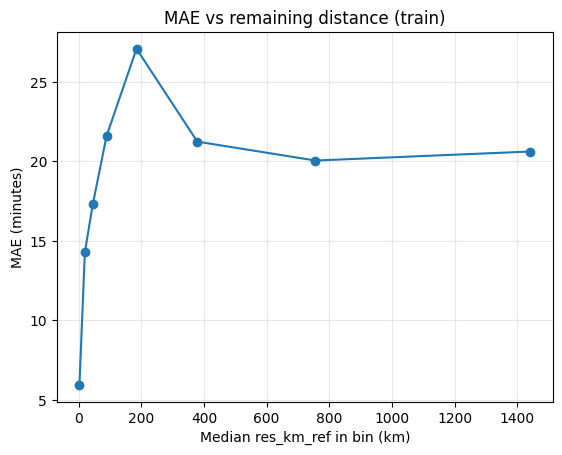

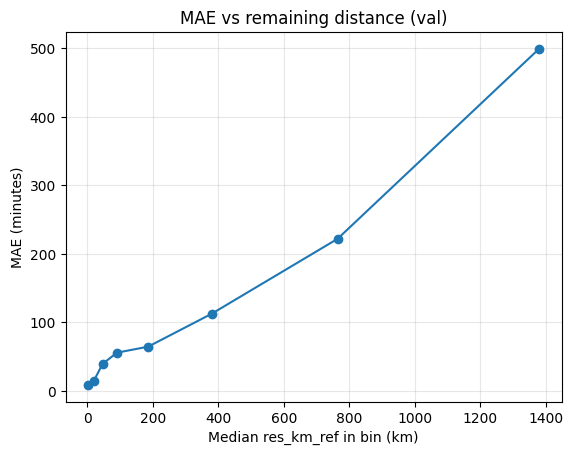

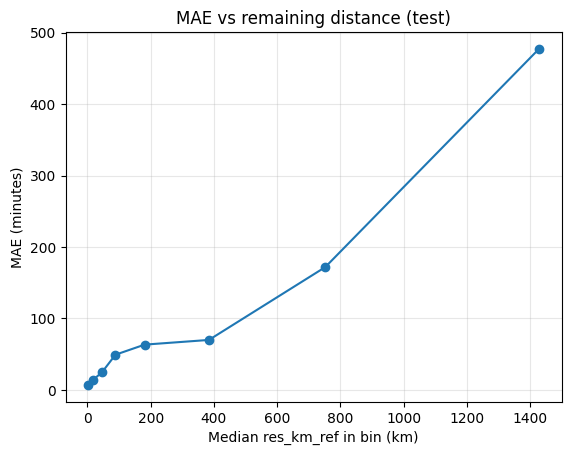


[QA] Worst ODs on test (MAE minutes):


C:\Users\slab\AppData\Local\Temp\ipykernel_27260\2080756434.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for od, g in test_ok.groupby("od_pair"):


,od_pair,n,mae_min
2,JPNGO__TWTPE,2416,400.398899
7,TWTPE__JPWAK,1841,134.313609
1,CNLYA__TWTPE,453,82.274816
6,TWTPE__CNLYA,1200,63.789743
5,TWTPE__CNFOC,5364,61.528385
3,TWHUN__TWTPE,3754,36.816304
8,TWTPE__TWHUN,2947,33.978055
0,CNFOC__TWTPE,3202,29.759175
4,TWKEL__TWTPE,302,28.694017
9,TWTPE__TWKEL,106,12.969401


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

data_path = lake_p("70_train", "train_table_v1_with_split.parquet")
pred_path = lake_p("70_train", "preds_lgbm_eta_v1.parquet")

df = pd.read_parquet(data_path)
preds = pd.read_parquet(pred_path)

# --- normalize Timestamp to "seconds" to make join robust ---
df = df.copy()
preds = preds.copy()

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
preds["Timestamp"] = pd.to_datetime(preds["Timestamp"], errors="coerce")

df["ts_sec"] = df["Timestamp"].dt.floor("S")
preds["ts_sec"] = preds["Timestamp"].dt.floor("S")

# merge on group_id + ts_sec (more robust than raw Timestamp)
d = df.merge(preds[["group_id", "ts_sec", "y_pred"]], on=["group_id", "ts_sec"], how="left")

miss = d["y_pred"].isna().mean()
print(f"[QA] y_pred missing after merge: {miss:.4%} (missing={d['y_pred'].isna().sum()} / {len(d)})")

# if too many missing, show a hint
if miss > 0.01:
    print("[WARN] Too many missing y_pred. Likely Timestamp mismatch or duplicates in preds.")
    # quick check: duplicates in preds join keys
    dup = preds.duplicated(subset=["group_id","ts_sec"]).mean()
    print(f"[QA] preds duplicated keys ratio: {dup:.4%}")

# compute errors (ignore NaNs)
d["abs_err_sec"] = (d["eta_clean_sec"] - d["y_pred"]).abs()

def _summ(x):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return {"n": 0}
    return dict(
        n=int(len(x)),
        p50=float(np.nanpercentile(x, 50)),
        p90=float(np.nanpercentile(x, 90)),
        p95=float(np.nanpercentile(x, 95)),
        p99=float(np.nanpercentile(x, 99)),
        max=float(np.nanmax(x)),
    )

print("\n[QA] eta_clean_sec distribution (sec):")
for sp in ["train","val","test"]:
    s = d.loc[d["split"]==sp, "eta_clean_sec"].to_numpy()
    print(sp, _summ(s))

print("\n[QA] res_km_ref distribution (km):")
for sp in ["train","val","test"]:
    s = d.loc[d["split"]==sp, "res_km_ref"].to_numpy()
    print(sp, _summ(s))

# --- error by res_km_ref bins ---
bins = [0, 10, 30, 60, 120, 250, 500, 1000, 3000, 1e9]
d["res_bin"] = pd.cut(d["res_km_ref"], bins=bins, right=False)

rows = []
for sp in ["train","val","test"]:
    gg_all = d[(d["split"]==sp) & (~d["y_pred"].isna())]
    for b, gg in gg_all.groupby("res_bin"):
        if len(gg) < 200:
            continue
        rows.append({
            "split": sp,
            "res_bin": str(b),
            "n": int(len(gg)),
            "mae_min": float(mean_absolute_error(gg["eta_clean_sec"], gg["y_pred"]) / 60.0),
            "med_res_km": float(np.nanmedian(gg["res_km_ref"])),
            "med_eta_min": float(np.nanmedian(gg["eta_clean_sec"]) / 60.0),
        })

err_by_bin = pd.DataFrame(rows).sort_values(["split","med_res_km"])
print("\n[QA] MAE by res_km_ref bins (minutes):")
display(err_by_bin)

if not err_by_bin.empty:
    for sp in ["train","val","test"]:
        dd = err_by_bin[err_by_bin["split"]==sp]
        plt.figure()
        plt.plot(dd["med_res_km"].to_numpy(), dd["mae_min"].to_numpy(), marker="o")
        plt.xlabel("Median res_km_ref in bin (km)")
        plt.ylabel("MAE (minutes)")
        plt.title(f"MAE vs remaining distance ({sp})")
        plt.grid(True, alpha=0.3)
        plt.show()

# --- per-OD MAE on test (safe) ---
od_rows = []
test_ok = d[(d["split"]=="test") & (~d["y_pred"].isna())].copy()

for od, g in test_ok.groupby("od_pair"):
    if len(g) == 0:
        continue
    mae_min = mean_absolute_error(g["eta_clean_sec"], g["y_pred"]) / 60.0
    od_rows.append({"od_pair": str(od), "n": int(len(g)), "mae_min": float(mae_min)})

od_mae = pd.DataFrame(od_rows).sort_values("mae_min", ascending=False)
print("\n[QA] Worst ODs on test (MAE minutes):")
display(od_mae.head(10))


#### month analysis

In [68]:
df = pd.read_parquet(lake_file(LAKE_DIR / "70_train", "train_table_v1_with_split.parquet"))
pd.crosstab(df["hour"], df["split"], normalize="columns").round(3)



split,test,train,val
hour,,,
0,0.047,0.038,0.041
1,0.050,0.039,0.040
2,0.046,0.041,0.038
3,0.046,0.040,0.034
4,0.038,0.036,0.035
5,0.039,0.036,0.035
6,0.044,0.040,0.039
7,0.043,0.041,0.045
8,0.047,0.041,0.047
